# DIMER Workshop: Comparing Tabular Foundation Models for Seven-Day Retail Demand-Band Classification

**Profile:** `E2E`  
**Mode:** `WORKSHOP`  
**Notebook specification:** DIMER Notebook Specification 2.1 — **standalone**  
**Run all:** the default path acquires the pinned sample, validates it, runs classical and four foundation-model in-context conditions, freezes the successful full-feature runs, reloads saved artifacts for independent test evaluation, and exports a reproducibility bundle. No DIMER service, repository clone, repository install, credential, or upload dialog is required.  
**Bring Your Own Data:** set `USE_BYOD = True` and provide `BYOD_ZIP_PATH` (or use the optional Colab upload fallback) for a ZIP containing `train.csv`, `val.csv`, and `test.csv` with the same feature/target contract. The path field always bypasses the upload dialog.

**Dataset:** `freshretailnet-band-h7` sample derived from FreshRetailNet-50K  
**Dataset source:** `examples/sample-data/freshretailnet-band-h7.zip` in `kurtvalcorza/mitra-classifier-pipeline`  
**Pinned dataset revision:** `469d91252f3583b38d08b5c4d90fef4848b93f24`  
**Pinned archive SHA-256:** `ad2d2a8729749bb055754e4867acfb048fc27816f4eb344961d962b59c0be6dd`  
**Model execution:** Mitra Classifier, TabDPT v1.2 Classifier, TabPFN-3 Classifier and TabICLv2 Classifier run locally in isolated Python 3.12 environments  
**Task:** classify observed retail sales seven days ahead into `low`, `mid`, or `high` demand bands  
**Primary model-selection metric:** balanced accuracy  
**Recommended audience:** college students with introductory Python and machine-learning experience

---

## What you will do

In this notebook, you will:

1. acquire and verify a fixed FreshRetailNet-derived classification artifact;
2. inspect its class balance and feature distributions without using the test labels for model selection;
3. build a baseline ladder from a majority predictor to boosted trees;
4. run four tabular foundation-model classifiers under one evaluation protocol;
5. compare accuracy, balanced accuracy, macro-F1, MCC, log loss, and multiclass ROC-AUC;
6. inspect confusion matrices and class-specific recall;
7. test whether stockout features contribute predictive information;
8. freeze the selected development runs before evaluating the test partition; and
9. export a reproducibility bundle with provenance, settings, results, and figures.

> **Important:** This is a training and demonstration exercise. The sample is a tutorial/sanity fixture, not benchmark evidence. The target is a band of **observed future sales**, which can be affected by stockouts and does not necessarily equal latent customer demand.


## Research-design context

The activity follows a controlled comparative pattern:

- one fixed three-class prediction task;
- one fixed temporal train/validation/test split;
- the same feature columns for every full-feature model;
- a common probability-aware metric suite; and
- an independent test partition used only after the development configuration is frozen.

### Main research question

> How do tabular foundation-model classifiers compare with conventional classification baselines when predicting whether observed sales seven days ahead fall into a low, mid, or high demand band?

### Why balanced accuracy is primary

The demand bands are defined from **training-only quantile edges**, but the later validation and test periods can have different class proportions. Ordinary accuracy can therefore reward a model for following the most common class in a shifted period. Balanced accuracy averages recall across classes and gives each band equal weight.

Supporting metrics still matter:

- **Accuracy:** overall fraction of correct labels.
- **Balanced accuracy:** average recall across classes.
- **Macro-F1:** F1 computed separately for each class, then averaged equally.
- **MCC:** a correlation-style summary of the multiclass confusion matrix.
- **Log loss:** quality of the full probability distribution; lower is better.
- **ROC-AUC (OvR macro):** class-ranking quality, averaged one-vs-rest.


## Learning objectives

By the end of the activity, you should be able to:

- distinguish classification from regression even when both use the same feature table;
- explain why the class bands must be constructed without validation/test leakage;
- interpret class balance, a confusion matrix, per-class recall, balanced accuracy, macro-F1, MCC, log loss, and ROC-AUC;
- distinguish **in-context conditioning** from **gradient fine-tuning**;
- compare foundation models with meaningful classical baselines;
- identify why probability columns must be aligned to the same class order before scoring;
- use validation data for model selection and reserve the test partition for one frozen evaluation; and
- state conclusions with appropriate scope and limitations.

### Short glossary

| Term | Meaning in this notebook |
|---|---|
| **Classification** | Predicting one categorical label from a fixed set of classes. |
| **Demand band** | The categorical target: `low`, `mid`, or `high` observed sales seven days ahead. |
| **In-context learning (ICL)** | A pretrained model conditions on labelled support rows without gradient-updating its weights. |
| **Fine-tuning** | Gradient updates adapt pretrained weights to the current dataset. |
| **Argmax rule** | Choose the class with the highest predicted probability. |
| **Class-order alignment** | Reorder probability columns so every model is scored against the same `low/mid/high` order. |
| **Freeze** | Record the selected successful validation runs before evaluating the test partition. |


## Dataset and experiment summary

The pinned archive contains:

| Partition | Rows | Purpose |
|---|---:|---|
| `train.csv` | 4,180 | Fit classical models or provide support/fine-tuning data |
| `val.csv` | 1,600 | Compare models and choose settings |
| `test.csv` | 1,600 | Final evaluation after the experiment is frozen |

Each row has 17 numeric input features and one categorical target.

The source builder first creates the same seven-day-ahead continuous target used by the regression sample, performs a **purged chronological split with seven-row embargoes**, then computes demand-band cut points from the **training partition only**. The validation and test targets are assigned using those fixed training-derived edges.

### Feature groups

- **Historical sales:** `lag_1`, `lag_7`, `lag_14`, rolling means, rolling standard deviation
- **Stockout:** `stockout_hours`, `roll_7_stockout`
- **Context:** discount, holiday/activity flags, precipitation, temperature, humidity, wind, day-of-week, month

### Foundation models

| Model | Default workshop mode | Optional mode | Weight licence note |
|---|---|---|---|
| Mitra Classifier | In-context | GPU fine-tuning | Apache-2.0 |
| TabDPT v1.2 Classifier | In-context | — | Apache-2.0 |
| TabPFN-3 Classifier | In-context | Private-worker fine-tuning is outside this notebook | TabPFN-3 licence v1.0; non-commercial weights |
| TabICLv2 Classifier | In-context | GPU fine-tuning | BSD-3-Clause |

The notebook records per-model failures explicitly. If all selected foundation models fail, it stops instead of presenting a baseline-only table as a multi-model comparison.


## Before you begin

### Requirements

- A current Google Colab or Jupyter runtime
- Internet access to download the pinned dataset, install `uv` when needed, and retrieve immutable model checkpoints from their declared public upstream hosts
- Several gigabytes of free runtime storage
- A GPU is recommended for the full four-model exercise and required for optional Mitra/TabICLv2 fine-tuning

The notebook kernel may use a newer Python release. Foundation models run in isolated **Python 3.12** environments created with `uv`, which provides a common compatible interpreter for all four pinned pipelines.

### Test-set rule

Do not inspect test labels while developing the models. The notebook keeps test-target summaries out of EDA and validation comparisons. The test cell requires a recorded freeze manifest.

### Licence boundary

TabPFN-3 weights are non-commercial. Their inclusion here is for testing, evaluation, learning, and internal benchmarking under the upstream licence; it does not grant production or commercial deployment rights.

### Optional user data

Set `USE_BYOD = True` in Section 1 to use your own pre-split ZIP. The archive must contain `train.csv`, `val.csv`, and `test.csv` with the same 17 feature columns and `target`. Use `BYOD_ZIP_PATH` for non-interactive execution; when it is non-empty the notebook never opens an upload dialog. User-supplied files stay in this runtime. Do not upload confidential, restricted, or personally identifiable data unless you are authorised to process it in the selected runtime.


# 0. Set up the workshop runtime

In [1]:
# @title 0.1 Imports, host dependencies, and workspace
from __future__ import annotations

import hashlib
import importlib
import importlib.metadata
import json
import math
import os
import pickle
import platform
import shutil
import subprocess
import sys
import time
import urllib.request
import uuid
import zipfile
from pathlib import Path, PurePosixPath

# Install only a missing host-side dependency. Foundation-model stacks are isolated later.
if importlib.util.find_spec("lightgbm") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "lightgbm==4.6.0"],
        check=True,
    )

import lightgbm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize

WORKSHOP_REVISION = "2.0.1"
RANDOM_SEED = 42
PRIMARY_METRIC = "balanced_accuracy"
TARGET_COLUMN = "target"
SEMANTIC_CLASS_ORDER = ["low", "mid", "high"]

ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
WORKSPACE_ROOT = ROOT / "dimer_classifier_workshop_v1"
CACHE_ROOT = WORKSPACE_ROOT / "cache"
ENVIRONMENT_ROOT = WORKSPACE_ROOT / "environments"
SESSION_ROOT = WORKSPACE_ROOT / "sessions" / uuid.uuid4().hex[:12]
DATA_ROOT = SESSION_ROOT / "data"
RUN_ROOT = SESSION_ROOT / "runs"
FIGURE_ROOT = SESSION_ROOT / "figures"
EXPORT_ROOT = SESSION_ROOT / "exports"
SUPPORT_ROOT = SESSION_ROOT / "support"

for directory in (
    WORKSPACE_ROOT,
    CACHE_ROOT,
    ENVIRONMENT_ROOT,
    SESSION_ROOT,
    DATA_ROOT,
    RUN_ROOT,
    FIGURE_ROOT,
    EXPORT_ROOT,
    SUPPORT_ROOT,
):
    directory.mkdir(parents=True, exist_ok=True)

def sha256_file(path: str | Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def canonical_json(value) -> str:
    return json.dumps(value, sort_keys=True, separators=(",", ":"), ensure_ascii=False)

def fingerprint(value) -> str:
    return hashlib.sha256(canonical_json(value).encode("utf-8")).hexdigest()

def write_json(path: str | Path, value) -> None:
    Path(path).write_text(
        json.dumps(value, indent=2, sort_keys=True, ensure_ascii=False, default=str) + "\n",
        encoding="utf-8",
    )

def file_inventory(root: str | Path) -> dict[str, str]:
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(root)
    inventory = {}
    for path in sorted(root.rglob("*")):
        if path.is_symlink():
            raise ValueError(f"Artifact inventory refuses symbolic links: {path}")
        if path.is_file():
            inventory[path.relative_to(root).as_posix()] = sha256_file(path)
    return inventory

def verify_file_inventory(root: str | Path, expected: dict[str, str]) -> None:
    root = Path(root)
    observed = file_inventory(root)
    if observed != expected:
        missing = sorted(set(expected) - set(observed))
        extra = sorted(set(observed) - set(expected))
        changed = sorted(
            name for name in set(expected) & set(observed)
            if expected[name] != observed[name]
        )
        raise ValueError(
            "Frozen artifact inventory changed. "
            f"Missing={missing}; extra={extra}; changed={changed}"
        )

def class_order(values) -> list[str]:
    observed = {str(value) for value in values}
    ordered = [label for label in SEMANTIC_CLASS_ORDER if label in observed]
    ordered.extend(sorted(observed - set(ordered)))
    return ordered

def align_probabilities(raw, model_classes, classes) -> np.ndarray:
    array = np.asarray(raw, dtype=float)
    source = [str(value) for value in model_classes]
    target = [str(value) for value in classes]
    if array.ndim != 2 or array.shape[1] != len(source):
        raise ValueError("Probability array shape does not match the model class list.")
    mapping = {label: i for i, label in enumerate(source)}
    missing = [label for label in target if label not in mapping]
    if missing:
        raise ValueError(f"Model probabilities omit required classes: {missing}")
    aligned = array[:, [mapping[label] for label in target]]
    if not np.isfinite(aligned).all():
        raise ValueError("Probabilities contain non-finite values.")
    row_sums = aligned.sum(axis=1)
    if not np.allclose(row_sums, 1.0, rtol=1e-5, atol=1e-6):
        raise ValueError("Probability rows do not sum to approximately 1.")
    return aligned

def classification_metrics(y_true, y_pred, proba, classes) -> dict[str, float]:
    y = np.asarray([str(v) for v in y_true])
    pred = np.asarray([str(v) for v in y_pred])
    p = np.asarray(proba, dtype=float)
    labels = [str(v) for v in classes]
    if y.shape != pred.shape or len(y) == 0:
        raise ValueError("Targets and predictions must be non-empty and equally sized.")
    if p.shape != (len(y), len(labels)):
        raise ValueError("Probability matrix does not match rows/classes.")

    label_to_index = {label: index for index, label in enumerate(labels)}
    try:
        y_index = np.asarray([label_to_index[value] for value in y], dtype=int)
        pred_index = np.asarray([label_to_index[value] for value in pred], dtype=int)
    except KeyError as exc:
        raise ValueError(
            f"Unknown class label in targets/predictions: {exc.args[0]!r}"
        ) from exc

    numeric_labels = list(range(len(labels)))
    result = {
        "accuracy": float(accuracy_score(y_index, pred_index)),
        "balanced_accuracy": float(balanced_accuracy_score(y_index, pred_index)),
        "f1_macro": float(
            f1_score(
                y_index,
                pred_index,
                labels=numeric_labels,
                average="macro",
                zero_division=0,
            )
        ),
        "mcc": float(matthews_corrcoef(y_index, pred_index)),
        "log_loss": float(log_loss(y_index, p, labels=numeric_labels)),
    }
    try:
        if len(labels) == 2:
            result["roc_auc_ovr_macro"] = float(
                roc_auc_score(y_index, p[:, 1])
            )
        else:
            y_binary = label_binarize(
                y_index,
                classes=np.arange(len(labels)),
            )
            result["roc_auc_ovr_macro"] = float(
                roc_auc_score(y_binary, p, average="macro")
            )
    except ValueError:
        result["roc_auc_ovr_macro"] = float("nan")
    return result

def prediction_frame(reference: pd.DataFrame, predictions, proba, classes) -> pd.DataFrame:
    out = pd.DataFrame(
        {
            "row_id": np.arange(len(reference)),
            "target": reference[TARGET_COLUMN].astype(str).to_numpy(),
            "prediction": np.asarray(predictions).astype(str),
        }
    )
    for index, label in enumerate(classes):
        out[f"probability_{label}"] = np.asarray(proba, dtype=float)[:, index]
    return out

SOFTWARE_VERSIONS = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "lightgbm": lightgbm.__version__,
}

print("Session:", SESSION_ROOT)
display(pd.Series(SOFTWARE_VERSIONS, name="version").to_frame())


Session: /content/dimer_classifier_workshop_v1/sessions/678aa12788c7


,version
python,3.13.15
numpy,2.1.3
pandas,2.2.3
scikit_learn,1.6.1
lightgbm,4.6.0


# 1. Acquire the pinned FreshRetailNet demand-band sample

This workshop downloads one immutable repository artifact. There is no DIMER dataset fallback and no alternate sample fallback.

- Repository: `kurtvalcorza/mitra-classifier-pipeline`
- Revision: `469d91252f3583b38d08b5c4d90fef4848b93f24`
- Path: `examples/sample-data/freshretailnet-band-h7.zip`
- SHA-256: `ad2d2a8729749bb055754e4867acfb048fc27816f4eb344961d962b59c0be6dd`

A mismatch stops the notebook.


In [2]:
# @title 1.1 Acquire, hash, and safely stage the dataset archive
USE_BYOD = False # @param {type:"boolean"}
BYOD_ZIP_PATH = "" # @param {type:"string"}

DATASET_REPOSITORY = "kurtvalcorza/mitra-classifier-pipeline"
DATASET_REPOSITORY_REVISION = "469d91252f3583b38d08b5c4d90fef4848b93f24"
DATASET_REPOSITORY_PATH = "examples/sample-data/freshretailnet-band-h7.zip"
EXPECTED_DATASET_SHA256 = "ad2d2a8729749bb055754e4867acfb048fc27816f4eb344961d962b59c0be6dd"
DATASET_URL = (
    "https://raw.githubusercontent.com/"
    f"{DATASET_REPOSITORY}/{DATASET_REPOSITORY_REVISION}/{DATASET_REPOSITORY_PATH}"
)

archive_path = DATA_ROOT / ("byod.zip" if USE_BYOD else "freshretailnet-band-h7.zip")
if USE_BYOD:
    explicit = BYOD_ZIP_PATH.strip()
    if explicit:
        source_path = Path(explicit).expanduser().resolve()
        if not source_path.is_file():
            raise FileNotFoundError(f"BYOD_ZIP_PATH does not exist: {source_path}")
        shutil.copy2(source_path, archive_path)
        acquisition = {"method": "explicit-path", "source": str(source_path)}
    else:
        try:
            from google.colab import files
        except ModuleNotFoundError as exc:
            raise RuntimeError(
                "Set BYOD_ZIP_PATH to a local ZIP path outside Colab; no upload dialog is available."
            ) from exc
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError("Upload exactly one ZIP containing train.csv, val.csv, and test.csv.")
        name, payload = next(iter(uploaded.items()))
        archive_path.write_bytes(bytes(payload))
        acquisition = {"method": "colab-upload", "source": str(name)}
else:
    print("Downloading pinned sample:", DATASET_URL)
    urllib.request.urlretrieve(DATASET_URL, archive_path)
    acquisition = {"method": "pinned-public-sample", "source": DATASET_URL}

if not zipfile.is_zipfile(archive_path):
    raise ValueError("Dataset is not a valid ZIP archive.")

DATASET_SHA256 = sha256_file(archive_path)
if not USE_BYOD and DATASET_SHA256 != EXPECTED_DATASET_SHA256:
    raise ValueError(
        "Dataset digest mismatch. "
        f"Expected {EXPECTED_DATASET_SHA256}, observed {DATASET_SHA256}."
    )

required_members = {"train.csv", "val.csv", "test.csv"}
staged_paths = {}
extract_root = DATA_ROOT / "staged"
extract_root.mkdir(exist_ok=False)

with zipfile.ZipFile(archive_path) as zf:
    selected = {}
    expanded_bytes = 0
    for info in zf.infolist():
        name = info.filename
        posix = PurePosixPath(name)
        if "\\" in name or posix.is_absolute() or ".." in posix.parts:
            raise ValueError(f"Unsafe ZIP path: {name}")
        expanded_bytes += info.file_size
        if expanded_bytes > 512 * 1024 * 1024:
            raise ValueError("Dataset archive exceeds the 512 MiB expanded-size ceiling.")
        if not info.is_dir() and posix.name in required_members:
            if posix.name in selected:
                raise ValueError(f"Duplicate split member: {posix.name}")
            selected[posix.name] = info
    missing = required_members - set(selected)
    if missing:
        raise ValueError(f"Dataset is missing required split files: {sorted(missing)}")
    for member_name, info in selected.items():
        target = extract_root / member_name
        target.write_bytes(zf.read(info))
        staged_paths[member_name[:-4]] = target

DATASET_PROVENANCE = {
    "dataset_name": "user-supplied pre-split data" if USE_BYOD else "freshretailnet-band-h7",
    "acquisition": acquisition,
    "repository": None if USE_BYOD else DATASET_REPOSITORY,
    "repository_revision": None if USE_BYOD else DATASET_REPOSITORY_REVISION,
    "repository_path": None if USE_BYOD else DATASET_REPOSITORY_PATH,
    "source_url": None if USE_BYOD else DATASET_URL,
    "archive_bytes": archive_path.stat().st_size,
    "sha256": DATASET_SHA256,
    "sha256_verified_against_published_value": not USE_BYOD,
    "split_sha256": {name: sha256_file(path) for name, path in staged_paths.items()},
}
display(pd.Series(DATASET_PROVENANCE, name="value").to_frame())


,value
dataset_name,freshretailnet-band-h7
acquisition,"{'method': 'pinned-public-sample', 'source': '..."
repository,kurtvalcorza/mitra-classifier-pipeline
repository_revision,469d91252f3583b38d08b5c4d90fef4848b93f24
repository_path,examples/sample-data/freshretailnet-band-h7.zip
source_url,https://raw.githubusercontent.com/kurtvalcorza...
archive_bytes,244474
sha256,ad2d2a8729749bb055754e4867acfb048fc27816f4eb34...
sha256_verified_against_published_value,True
split_sha256,{'train': '0318e298eff73a7410bdd94a88ecba9698a...


# 2. Load and validate the train, validation, and test contracts

In [3]:
# @title 2.1 Validate rows, schema, numeric features, and class coverage
EXPECTED_ROWS = {"train": 4180, "val": 1600, "test": 1600}
EXPECTED_FEATURES = [
    "lag_1",
    "lag_7",
    "lag_14",
    "roll_7_mean",
    "roll_28_mean",
    "roll_7_std",
    "stockout_hours",
    "roll_7_stockout",
    "discount",
    "holiday_flag",
    "activity_flag",
    "precpt",
    "avg_temperature",
    "avg_humidity",
    "avg_wind_level",
    "dow",
    "month",
]

frames = {
    split: pd.read_csv(path, float_precision="round_trip")
    for split, path in staged_paths.items()
}

reference_columns = EXPECTED_FEATURES + [TARGET_COLUMN]
for split, frame in frames.items():
    if not USE_BYOD and len(frame) != EXPECTED_ROWS[split]:
        raise ValueError(
            f"{split}: expected {EXPECTED_ROWS[split]} rows, observed {len(frame)}."
        )
    if USE_BYOD and len(frame) < 2:
        raise ValueError(f"{split}: BYOD splits must contain at least two rows.")
    if list(frame.columns) != reference_columns:
        raise ValueError(
            f"{split}: schema mismatch.\n"
            f"Expected: {reference_columns}\nObserved: {list(frame.columns)}"
        )
    if frame.columns.duplicated().any():
        raise ValueError(f"{split}: duplicate columns are not allowed.")
    for column in EXPECTED_FEATURES:
        numeric = pd.to_numeric(frame[column], errors="raise")
        if not np.isfinite(numeric.to_numpy(dtype=float)).all():
            raise ValueError(f"{split}: feature {column!r} contains non-finite values.")
    if frame[TARGET_COLUMN].isna().any():
        raise ValueError(f"{split}: target contains missing values.")

CLASS_LABELS = class_order(frames["train"][TARGET_COLUMN].astype(str))
if CLASS_LABELS != SEMANTIC_CLASS_ORDER:
    raise ValueError(
        f"Expected semantic classes {SEMANTIC_CLASS_ORDER}, observed {CLASS_LABELS}."
    )

for split in ("val", "test"):
    observed_classes = set(frames[split][TARGET_COLUMN].astype(str))
    unseen = sorted(observed_classes - set(CLASS_LABELS))
    missing = sorted(set(CLASS_LABELS) - observed_classes)
    if unseen or missing:
        raise ValueError(
            f"{split}: class coverage mismatch; unseen={unseen}, missing={missing}"
        )

FEATURE_COLUMNS = list(EXPECTED_FEATURES)
X_train = frames["train"][FEATURE_COLUMNS]
y_train = frames["train"][TARGET_COLUMN].astype(str)
X_val = frames["val"][FEATURE_COLUMNS]
y_val = frames["val"][TARGET_COLUMN].astype(str)

DATASET_IDENTITY = {
    "archive_sha256": DATASET_SHA256,
    "split_sha256": DATASET_PROVENANCE["split_sha256"],
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "class_labels": CLASS_LABELS,
    "rows": {split: len(frame) for split, frame in frames.items()},
}
DATASET_FINGERPRINT = fingerprint(DATASET_IDENTITY)

print("Dataset fingerprint:", DATASET_FINGERPRINT)
display(
    pd.DataFrame(
        {
            "split": ["train", "validation", "test"],
            "rows": [len(frames["train"]), len(frames["val"]), len(frames["test"])],
            "features": [len(FEATURE_COLUMNS)] * 3,
        }
    )
)
print("Classes:", CLASS_LABELS)


Dataset fingerprint: b2dde6d783a0b886eac7ecdc09480787d622ea521b5aaf6aca6344a39cefbf8b


,split,rows,features
0,train,4180,17
1,validation,1600,17
2,test,1600,17


Classes: ['low', 'mid', 'high']


### Class balance

The next cell shows **training and validation** target proportions. The test target distribution stays hidden until after the freeze.

Because the band cut points came from the training partition, training classes are expected to be comparatively balanced. Later chronological periods may shift.


,train_pct,validation_pct
class,,
low,31.53,35.12
mid,35.05,33.38
high,33.42,31.50


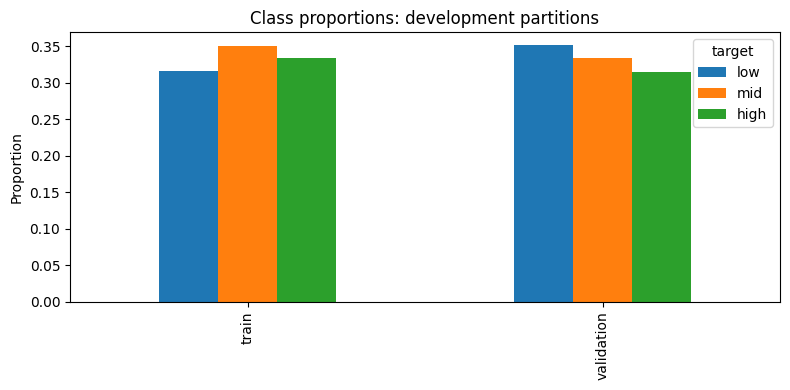

Test rows: 1600
Test target distribution intentionally not displayed before freeze.


In [4]:
# @title 2.2 Inspect development class balance only
development_class_balance = pd.concat(
    {
        "train": y_train.value_counts(normalize=True).reindex(CLASS_LABELS),
        "validation": y_val.value_counts(normalize=True).reindex(CLASS_LABELS),
    },
    axis=1,
).fillna(0.0)

display((development_class_balance * 100).round(2).rename_axis("class").rename(columns=lambda x: f"{x}_pct"))

fig, ax = plt.subplots(figsize=(8, 4))
development_class_balance.T.plot(kind="bar", ax=ax)
ax.set_title("Class proportions: development partitions")
ax.set_ylabel("Proportion")
ax.set_xlabel("")
plt.tight_layout()
class_balance_figure = FIGURE_ROOT / "development_class_balance.png"
plt.savefig(class_balance_figure, dpi=140)
plt.show()

print("Test rows:", len(frames["test"]))
print("Test target distribution intentionally not displayed before freeze.")


# 3. Exploratory data analysis

EDA should explain the table before it evaluates models. These views use the training and validation partitions only.

Focus on three questions:

1. Do the demand bands occupy similar proportions across development periods?
2. Which historical-sales features separate the bands?
3. Do stockout features shift across classes or periods?


train                                validation         \
                   mean    std     min     50%     max       mean    std   
lag_1             0.939  1.219   0.000   0.600  15.000      0.965  1.448   
lag_7             0.927  1.146   0.000   0.600  12.000      0.977  1.406   
lag_14            0.912  1.039   0.000   0.600  12.000      0.950  1.282   
roll_7_mean       0.925  1.037   0.014   0.614  12.857      1.001  1.343   
stockout_hours    3.219  4.640   0.000   0.000  16.000      2.750  4.328   
roll_7_stockout   3.303  2.756   0.000   2.714  16.000      2.632  2.428   
discount          0.926  0.119   0.000   1.000   1.000      0.928  0.125   
avg_temperature  21.610  1.733  18.940  21.210  27.330     23.634  1.150   

                                        
                    min     50%    max  
lag_1             0.000   0.600  19.30  
lag_7             0.000   0.600  16.00  
lag_14            0.000   0.600  15.00  
roll_7_mean       0.029   0.671  17.30  
stockout_hours    0.000   0.000  16.00  
roll_7_stockout   0.000   2.143  14.00  
discount          0.000   1.000   1.00  
avg_temperature  21.160  23.425  27.64

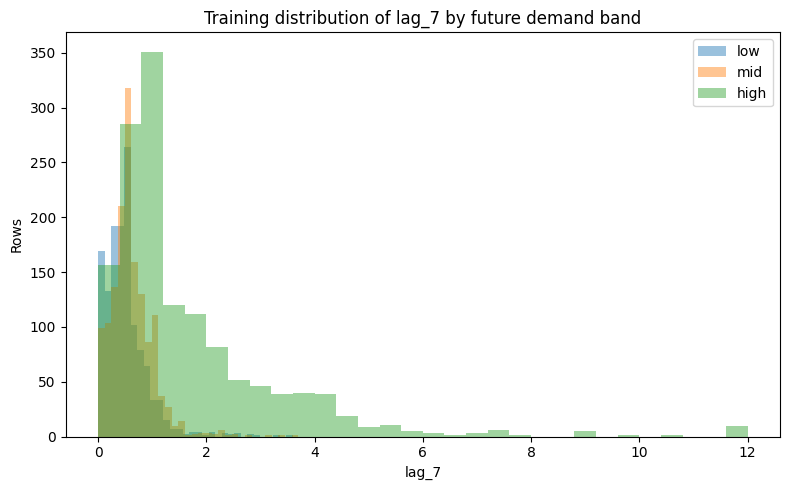

stockout_hours        roll_7_stockout       
                 mean median            mean median
target                                             
low             3.090    0.0           3.253  2.571
mid             3.064    0.0           3.125  2.714
high            3.504    0.0           3.539  2.857

In [5]:
# @title 3.1 Development-only EDA
eda_train = frames["train"].copy()
eda_val = frames["val"].copy()

summary_columns = [
    "lag_1",
    "lag_7",
    "lag_14",
    "roll_7_mean",
    "stockout_hours",
    "roll_7_stockout",
    "discount",
    "avg_temperature",
]

development_summary = pd.concat(
    {
        "train": eda_train[summary_columns].describe().T[["mean", "std", "min", "50%", "max"]],
        "validation": eda_val[summary_columns].describe().T[["mean", "std", "min", "50%", "max"]],
    },
    axis=1,
)
display(development_summary.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
for label in CLASS_LABELS:
    values = eda_train.loc[eda_train[TARGET_COLUMN] == label, "lag_7"]
    ax.hist(values, bins=30, alpha=0.45, label=label)
ax.set_title("Training distribution of lag_7 by future demand band")
ax.set_xlabel("lag_7")
ax.set_ylabel("Rows")
ax.legend()
plt.tight_layout()
lag_figure = FIGURE_ROOT / "lag7_by_class.png"
plt.savefig(lag_figure, dpi=140)
plt.show()

stockout_by_class = (
    eda_train.groupby(TARGET_COLUMN)[["stockout_hours", "roll_7_stockout"]]
    .agg(["mean", "median"])
    .reindex(CLASS_LABELS)
)
display(stockout_by_class.round(3))


# 4. Build a classical baseline ladder

A foundation model should not be compared only with a weak constant predictor.

This notebook uses:

1. **Training-prior majority:** always predict the most common training class; probabilities equal the training class shares.
2. **Lag-7 quantile-band heuristic:** classify `lag_7` using training-only tertile cut points as a simple temporal persistence heuristic.
3. **Multinomial logistic regression:** regularized linear decision surfaces after median imputation and standardization.
4. **Random Forest:** nonlinear tree ensemble.
5. **LightGBM:** gradient-boosted trees.

All models are evaluated on the same validation rows and the same class order.


In [6]:
# @title 4.1 Fit and score the baseline ladder
BASELINE_ROOT = RUN_ROOT / "baselines"
BASELINE_ROOT.mkdir(exist_ok=True)

def register_baseline(
    key: str,
    model_name: str,
    predictions,
    probabilities,
    artifact,
    *,
    notes: str = "",
):
    proba = np.asarray(probabilities, dtype=float)
    pred = np.asarray(predictions).astype(str)
    metrics = classification_metrics(y_val, pred, proba, CLASS_LABELS)
    run_dir = BASELINE_ROOT / key
    run_dir.mkdir(exist_ok=False)
    with (run_dir / "artifact.pkl").open("wb") as handle:
        pickle.dump(artifact, handle)
    pred_frame = prediction_frame(frames["val"], pred, proba, CLASS_LABELS)
    pred_frame.to_csv(run_dir / "validation_predictions.csv", index=False)
    result = {
        "model_key": key,
        "model": model_name,
        "family": "Classical / heuristic",
        "condition": "validation",
        **metrics,
        "runtime_seconds": None,
        "device": "cpu",
        "licence": "n/a",
        "notes": notes,
        "artifact_sha256": sha256_file(run_dir / "artifact.pkl"),
        "dataset_fingerprint": DATASET_FINGERPRINT,
        "feature_columns": FEATURE_COLUMNS,
    }
    write_json(run_dir / "result.json", result)
    return result, pred_frame

baseline_records = []
baseline_prediction_registry = {}

# 1) Training-prior majority baseline.
prior_series = y_train.value_counts(normalize=True).reindex(CLASS_LABELS).fillna(0.0)
majority_label = str(prior_series.idxmax())
majority_pred = np.repeat(majority_label, len(y_val))
majority_proba = np.tile(prior_series.to_numpy(dtype=float), (len(y_val), 1))
result, pred_frame = register_baseline(
    "training_prior_majority",
    "Training-prior majority",
    majority_pred,
    majority_proba,
    {
        "kind": "majority",
        "class_labels": CLASS_LABELS,
        "priors": prior_series.to_dict(),
        "majority_label": majority_label,
    },
)
baseline_records.append(result)
baseline_prediction_registry[result["model_key"]] = pred_frame

# 2) Domain-informed lag-7 heuristic using train-only quantiles.
lag_edges = X_train["lag_7"].quantile([1/3, 2/3]).to_numpy(dtype=float)
lag_ids = np.digitize(X_val["lag_7"].to_numpy(dtype=float), lag_edges)
lag_pred = np.asarray(CLASS_LABELS, dtype=object)[lag_ids]
lag_proba = np.full((len(lag_pred), len(CLASS_LABELS)), 1e-6, dtype=float)
lag_proba[np.arange(len(lag_pred)), lag_ids] = 1.0 - (len(CLASS_LABELS) - 1) * 1e-6
result, pred_frame = register_baseline(
    "lag7_quantile_band",
    "Lag-7 quantile-band heuristic",
    lag_pred,
    lag_proba,
    {
        "kind": "lag7_quantile",
        "feature": "lag_7",
        "edges": lag_edges.tolist(),
        "class_labels": CLASS_LABELS,
    },
    notes="Training-only lag_7 tertiles; a simple temporal persistence heuristic.",
)
baseline_records.append(result)
baseline_prediction_registry[result["model_key"]] = pred_frame

# 3) Logistic regression.
logistic = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)),
    ]
)
t0 = time.perf_counter()
logistic.fit(X_train, y_train)
elapsed = time.perf_counter() - t0
logistic_raw = logistic.predict_proba(X_val)
logistic_classes = logistic.named_steps["model"].classes_
logistic_proba = align_probabilities(logistic_raw, logistic_classes, CLASS_LABELS)
logistic_pred = np.asarray(CLASS_LABELS, dtype=object)[np.argmax(logistic_proba, axis=1)]
result, pred_frame = register_baseline(
    "logistic_regression",
    "Logistic Regression",
    logistic_pred,
    logistic_proba,
    {"kind": "sklearn", "model": logistic, "class_labels": CLASS_LABELS},
)
result["runtime_seconds"] = elapsed
write_json(BASELINE_ROOT / "logistic_regression" / "result.json", result)
baseline_records.append(result)
baseline_prediction_registry[result["model_key"]] = pred_frame

# 4) Random Forest.
random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
t0 = time.perf_counter()
random_forest.fit(X_train, y_train)
elapsed = time.perf_counter() - t0
rf_proba = align_probabilities(
    random_forest.predict_proba(X_val),
    random_forest.classes_,
    CLASS_LABELS,
)
rf_pred = np.asarray(CLASS_LABELS, dtype=object)[np.argmax(rf_proba, axis=1)]
result, pred_frame = register_baseline(
    "random_forest",
    "Random Forest",
    rf_pred,
    rf_proba,
    {"kind": "sklearn", "model": random_forest, "class_labels": CLASS_LABELS},
)
result["runtime_seconds"] = elapsed
write_json(BASELINE_ROOT / "random_forest" / "result.json", result)
baseline_records.append(result)
baseline_prediction_registry[result["model_key"]] = pred_frame

# 5) LightGBM.
lightgbm_model = LGBMClassifier(
    n_estimators=300,
    random_state=RANDOM_SEED,
    verbosity=-1,
)
t0 = time.perf_counter()
lightgbm_model.fit(X_train, y_train)
elapsed = time.perf_counter() - t0
lgbm_proba = align_probabilities(
    lightgbm_model.predict_proba(X_val),
    lightgbm_model.classes_,
    CLASS_LABELS,
)
lgbm_pred = np.asarray(CLASS_LABELS, dtype=object)[np.argmax(lgbm_proba, axis=1)]
result, pred_frame = register_baseline(
    "lightgbm",
    "LightGBM",
    lgbm_pred,
    lgbm_proba,
    {"kind": "sklearn", "model": lightgbm_model, "class_labels": CLASS_LABELS},
)
result["runtime_seconds"] = elapsed
write_json(BASELINE_ROOT / "lightgbm" / "result.json", result)
baseline_records.append(result)
baseline_prediction_registry[result["model_key"]] = pred_frame

baseline_validation_results = pd.DataFrame(baseline_records)
baseline_validation_results = baseline_validation_results.sort_values(
    PRIMARY_METRIC,
    ascending=False,
).reset_index(drop=True)

display(
    baseline_validation_results[
        [
            "model",
            "balanced_accuracy",
            "accuracy",
            "f1_macro",
            "mcc",
            "log_loss",
            "roc_auc_ovr_macro",
        ]
    ].round(4)
)


,model,balanced_accuracy,accuracy,f1_macro,mcc,log_loss,roc_auc_ovr_macro
0,Random Forest,0.5733,0.5688,0.5698,0.3564,0.8741,0.7608
1,Logistic Regression,0.5707,0.5694,0.5776,0.3593,0.9121,0.7631
2,LightGBM,0.5426,0.5381,0.5386,0.3097,1.0722,0.7446
3,Lag-7 quantile-band heuristic,0.5086,0.5019,0.4980,0.2625,6.8819,0.6302
4,Training-prior majority,0.3333,0.3338,0.1668,0.0000,1.1006,0.5000


# 5. Run the tabular foundation-model classifiers

The notebook carries the reviewed public adapters from four pinned pipeline revisions and runs each model stack in a separate `uv`-managed Python 3.12 environment. No DIMER pipeline repository is cloned or installed at runtime.

Default conditions:

- **Mitra Classifier:** in-context
- **TabDPT v1.2 Classifier:** in-context
- **TabPFN-3 Classifier:** in-context
- **TabICLv2 Classifier:** in-context

Optional GPU conditions:

- Mitra fine-tuned
- TabICLv2 fine-tuned

Each model must emit a probability matrix that is explicitly reordered to the workshop class order `low → mid → high` before scoring.


In [7]:
# @title 5.1 Select foundation-model conditions
RUN_MITRA_ICL = True # @param {type:"boolean"}
RUN_TABDPT_ICL = True # @param {type:"boolean"}
RUN_TABPFN3_ICL = True # @param {type:"boolean"}
RUN_TABICLV2_ICL = True # @param {type:"boolean"}

RUN_MITRA_FINETUNED = False # @param {type:"boolean"}
RUN_TABICLV2_FINETUNED = False # @param {type:"boolean"}

DEVICE_PREFERENCE = "auto" # @param ["auto", "cpu", "cuda"]
REBUILD_MODEL_ENVIRONMENTS = False # @param {type:"boolean"}
FORCE_MODEL_RERUN = False # @param {type:"boolean"}
REQUIRE_ALL_SELECTED_MODELS = True # @param {type:"boolean"}

MITRA_TIME_LIMIT_SECONDS = 600
MITRA_FINE_TUNE_STEPS = 50

TABDPT_N_ENSEMBLES = 4
TABDPT_CONTEXT_SIZE = 4180
TABDPT_BATCH_SIZE = 4096

TABPFN_N_ESTIMATORS = 4
TABICL_N_ESTIMATORS = 8
TABICL_FINE_TUNE_EPOCHS = 10
TABICL_FINE_TUNE_TIME_LIMIT = 600
TABICL_FINE_TUNE_PATIENCE = 3

MODEL_REPOSITORIES = {
    "mitra": {
        "repository": "kurtvalcorza/mitra-classifier-pipeline",
        "commit": "469d91252f3583b38d08b5c4d90fef4848b93f24",
        "import_name": "mitra_pipeline",
        "licence": "Apache-2.0",
    },
    "tabdpt": {
        "repository": "kurtvalcorza/tabdpt-classifier-pipeline",
        "commit": "1e35dc4738f015b254b1724fd4bc7ba9f49668af",
        "import_name": "tabdpt_classifier_pipeline",
        "licence": "Apache-2.0",
    },
    "tabpfn": {
        "repository": "kurtvalcorza/tabpfn-classifier-pipeline",
        "commit": "769fb7b47e01b1d10edd954dabc634b8034598c2",
        "import_name": "tabpfn_classifier_pipeline",
        "licence": "TabPFN-3 licence v1.0 — non-commercial weights",
    },
    "tabicl": {
        "repository": "kurtvalcorza/tabicl-classifier-pipeline",
        "commit": "7400516ac86e3b6e55f5134ad5e550f312948981",
        "import_name": "tabicl_classifier_pipeline",
        "licence": "BSD-3-Clause",
    },
}

CONDITION_SPECS = {
    "mitra_icl": {
        "environment": "mitra",
        "display_name": "Mitra Classifier",
        "condition": "in_context",
        "configuration": {
            "fine_tune": False,
            "time_limit_seconds": MITRA_TIME_LIMIT_SECONDS,
            "fine_tune_steps": 0,
        },
    },
    "mitra_finetuned": {
        "environment": "mitra",
        "display_name": "Mitra Classifier",
        "condition": "fine_tuned",
        "configuration": {
            "fine_tune": True,
            "time_limit_seconds": MITRA_TIME_LIMIT_SECONDS,
            "fine_tune_steps": MITRA_FINE_TUNE_STEPS,
        },
    },
    "tabdpt_icl": {
        "environment": "tabdpt",
        "display_name": "TabDPT v1.2 Classifier",
        "condition": "in_context",
        "configuration": {
            "n_ensembles": TABDPT_N_ENSEMBLES,
            "context_size": TABDPT_CONTEXT_SIZE,
            "batch_size": TABDPT_BATCH_SIZE,
        },
    },
    "tabpfn3_icl": {
        "environment": "tabpfn",
        "display_name": "TabPFN-3 Classifier",
        "condition": "in_context",
        "configuration": {
            "n_estimators": TABPFN_N_ESTIMATORS,
        },
    },
    "tabiclv2_icl": {
        "environment": "tabicl",
        "display_name": "TabICLv2 Classifier",
        "condition": "in_context",
        "configuration": {
            "n_estimators": TABICL_N_ESTIMATORS,
        },
    },
    "tabiclv2_finetuned": {
        "environment": "tabicl",
        "display_name": "TabICLv2 Classifier",
        "condition": "fine_tuned",
        "configuration": {
            "n_estimators": TABICL_N_ESTIMATORS,
            "fine_tune_epochs": TABICL_FINE_TUNE_EPOCHS,
            "fine_tune_time_limit": TABICL_FINE_TUNE_TIME_LIMIT,
            "fine_tune_patience": TABICL_FINE_TUNE_PATIENCE,
        },
    },
}

selected_foundation_conditions = []
if RUN_MITRA_ICL:
    selected_foundation_conditions.append("mitra_icl")
if RUN_TABDPT_ICL:
    selected_foundation_conditions.append("tabdpt_icl")
if RUN_TABPFN3_ICL:
    selected_foundation_conditions.append("tabpfn3_icl")
if RUN_TABICLV2_ICL:
    selected_foundation_conditions.append("tabiclv2_icl")
if RUN_MITRA_FINETUNED:
    selected_foundation_conditions.append("mitra_finetuned")
if RUN_TABICLV2_FINETUNED:
    selected_foundation_conditions.append("tabiclv2_finetuned")

run_plan = []
for key in selected_foundation_conditions:
    spec = CONDITION_SPECS[key]
    repo_spec = MODEL_REPOSITORIES[spec["environment"]]
    run_plan.append(
        {
            "model_key": key,
            "model": spec["display_name"],
            "condition": spec["condition"],
            "repository": repo_spec["repository"],
            "repository_commit": repo_spec["commit"],
            "weights_licence": repo_spec["licence"],
            "configuration": json.dumps(spec["configuration"], sort_keys=True),
        }
    )

display(pd.DataFrame(run_plan))


,model_key,model,condition,repository,repository_commit,weights_licence,configuration
0,mitra_icl,Mitra Classifier,in_context,kurtvalcorza/mitra-classifier-pipeline,469d91252f3583b38d08b5c4d90fef4848b93f24,Apache-2.0,"{""fine_tune"": false, ""fine_tune_steps"": 0, ""ti..."
1,tabdpt_icl,TabDPT v1.2 Classifier,in_context,kurtvalcorza/tabdpt-classifier-pipeline,1e35dc4738f015b254b1724fd4bc7ba9f49668af,Apache-2.0,"{""batch_size"": 4096, ""context_size"": 4180, ""n_..."
2,tabpfn3_icl,TabPFN-3 Classifier,in_context,kurtvalcorza/tabpfn-classifier-pipeline,769fb7b47e01b1d10edd954dabc634b8034598c2,TabPFN-3 licence v1.0 — non-commercial weights,"{""n_estimators"": 4}"
3,tabiclv2_icl,TabICLv2 Classifier,in_context,kurtvalcorza/tabicl-classifier-pipeline,7400516ac86e3b6e55f5134ad5e550f312948981,BSD-3-Clause,"{""n_estimators"": 8}"


## 5.2 Prepare isolated model environments from notebook-carried adapters

The notebook carries the reviewed public adapter modules from the pinned model-pipeline revisions as source text. At runtime it writes those carried modules into the session workspace, uses `uv` to create isolated Python 3.12 environments, installs only the exact upstream dependency pins, and stages the small checkpoint manifests that anchor immutable model downloads.

The runtime does **not** clone, fetch, check out, or install any DIMER pipeline repository. Model checkpoints are downloaded only from their declared public upstream hosts at immutable revisions and are verified by the carried adapter code before use.


In [8]:
# @title 5.2 Stage carried adapters and prepare isolated model environments
CARRIED_ADAPTER_SOURCES = {"mitra_pipeline/tutorial_api.py":"\"\"\"Release-grade public API for the Mitra Classifier notebook surface.\n\nThis module owns the repository-facing behavior the notebooks must exercise directly:\nclassification data validation, Mitra fit/predict calls, model snapshot locking, and predictor\nartifact validation. Imports that pull in heavy ML dependencies are intentionally delayed so\narchive and manifest checks remain unit-testable in a lightweight CI environment.\n\"\"\"\n\n# ruff: noqa: E501  -- long messages and docstrings are kept on one line\nfrom __future__ import annotations\n\nimport csv\nimport hashlib\nimport io\nimport json\nimport os\nimport random\nimport shutil\nimport stat\nimport tempfile\nimport urllib.request\nimport zipfile\nfrom collections.abc import Callable, Iterable, Mapping, Sequence\nfrom pathlib import Path, PurePosixPath\nfrom typing import Any\n\nimport numpy as np\nimport pandas as pd\n\n# Fleet snapshot identity (DIMER Notebook Specification 1.1, ST3/MOD13). The pinned upstream model is unchanged;\n# these are the fleet-standard names for the same repository, revision, license and snapshot key. The published\n# PINNED_REVISION spelling stays as an alias of MODEL_REVISION.\nMODEL_ID = \"autogluon/mitra-classifier\"\nMODEL_REVISION = \"c425e9fa0910a6be1c494321792e7ba2a1367b1a\"\nMODEL_LICENSE = \"apache-2.0\"\nMODEL_KEY = \"mitra-classifier\"\nMANIFEST_NAME = \"dimer-base-manifest.json\"\n# Root-level package: the repository root is one level up from this file.\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[1] / \"weights\" / MODEL_KEY\nWEIGHTS_FILE = \"model.safetensors\"\nCONFIG_FILE = \"config.json\"\n\nPINNED_REVISION = MODEL_REVISION\nWEIGHTS_SHA256 = \"e06a055e91a3baeffc37f9cf634d9e69a27d904b6686131dc3b702f9c0126b19\"\nCONFIG_SHA256 = \"2c96c24dd25f64e92753f6f2ba00cc7833b9923459403dcd8504e8700c0995df\"\n# The ids `classification_metrics` reports (sklearn, computed from labels + class probabilities) and the ids\n# `normalize_autogluon_classification_metrics` may carry through from AutoGluon's own evaluate().\nMETRIC_IDS = (\"accuracy\", \"balanced_accuracy\", \"log_loss\", \"roc_auc\", \"f1_macro\", \"mcc\", \"f1\", \"precision\", \"recall\")\nDECISION_RULE = \"argmax\"  # `predict` is the argmax over `predict_proba`; no threshold is shipped\nMIN_CLASSES = 2\nMAX_CLASSES = 10  # Mitra's class ceiling (dim_output)\nMIN_CLASS_COUNT = 2  # rows per class in the support split (stratified holdout needs 2)\n\nMAX_TRAIN_ROWS = 10_000\nMAX_FEATURES = 500\nMIN_TRAIN_ROWS = 50\n\nARTIFACT_FORMAT = \"dimer-autogluon-predictor\"\nARTIFACT_FORMAT_VERSION = 1\nARTIFACT_MANIFEST = \"artifact_manifest.json\"\nRUN_METADATA = \"tutorial_run_metadata.json\"\nDIMER_MODEL_MANIFEST = \"dimer-model-manifest.json\"\n\nMAX_ARCHIVE_MEMBER_BYTES = 1 * 1024**3\nMAX_ARCHIVE_EXPANDED_BYTES = 4 * 1024**3\nMAX_COMPRESSION_RATIO = 200.0\n\nCLASSIFICATION_LOWER_IS_BETTER = {\"log_loss\"}\n# AutoGluon eval_metric names the tutorial accepts; the Mitra model hyper-parameter `metric` knows two of them.\nEVAL_METRICS = (\"accuracy\", \"balanced_accuracy\", \"log_loss\", \"f1_macro\", \"mcc\")\nMITRA_METRIC_MAP = {\"accuracy\": \"accuracy\", \"log_loss\": \"log_loss\"}\n\nREQUIRED_RUN_METADATA_FIELDS = {\n    \"artifact_format\",\n    \"artifact_format_version\",\n    \"base_model\",\n    \"base_model_revision\",\n    \"weights_sha256\",\n    \"config_sha256\",\n    \"autogluon_version\",\n    \"python_version\",\n    \"problem_type\",\n    \"target_column\",\n    \"features\",\n    \"mode\",\n    \"selection_basis\",\n}\n\n\ndef sha256_file(path: str | Path) -> str:\n    h = hashlib.sha256()\n    with open(path, \"rb\") as handle:\n        for chunk in iter(lambda: handle.read(1 << 20), b\"\"):\n            h.update(chunk)\n    return h.hexdigest()\n\n\ndef _assert_hex_digest(value: str, label: str) -> str:\n    digest = str(value).strip().lower()\n    if len(digest) != 64 or any(ch not in \"0123456789abcdef\" for ch in digest):\n        raise ValueError(f\"{label} must be a 64-character hexadecimal SHA-256 digest.\")\n    return digest\n\n\ndef read_csv_bytes(payload: bytes, label: str) -> pd.DataFrame:\n    \"\"\"Parse UTF-8/BOM CSV bytes while rejecting duplicate raw headers before pandas renames them.\"\"\"\n    try:\n        text = payload.decode(\"utf-8-sig\")\n    except UnicodeDecodeError as exc:\n        raise ValueError(f\"{label}: expected UTF-8 CSV input.\") from exc\n\n    rows = csv.reader(io.StringIO(text, newline=\"\"))\n    header = next((row for row in rows if row and not (len(row) == 1 and not row[0].strip())), [])\n    if not header:\n        raise ValueError(f\"{label}: CSV has no header row.\")\n\n    seen: set[str] = set()\n    duplicates: list[str] = []\n    for name in header:\n        if name in seen and name not in duplicates:\n            duplicates.append(name)\n        seen.add(name)\n    if duplicates:\n        raise ValueError(f\"{label}: duplicate column names are not supported: {duplicates}\")\n\n    return pd.read_csv(io.BytesIO(payload))\n\n\ndef validate_labeled_frame(\n    frame: pd.DataFrame,\n    target_column: str,\n    *,\n    name: str,\n    drop_columns: Iterable[str] = (),\n    min_rows: int = 2,\n    min_classes: int = 1,\n    max_classes: int = MAX_CLASSES,\n    min_class_count: int = 1,\n) -> tuple[pd.DataFrame, list[str], dict[str, Any]]:\n    \"\"\"Validate one labelled classification table using the repository's user-facing contract.\n\n    The target keeps its own dtype (any label type); rows with a missing target are dropped and counted; the\n    class count must lie in ``min_classes..max_classes`` (Mitra's ceiling is ``MAX_CLASSES``) and every class\n    needs at least ``min_class_count`` rows (2 for a support split that will be stratified).\"\"\"\n    if frame.columns.duplicated().any():\n        duplicates = list(frame.columns[frame.columns.duplicated()])\n        raise ValueError(f\"{name}: duplicate column names are not supported: {duplicates}\")\n    if target_column not in frame.columns:\n        raise ValueError(f\"{name}: target {target_column!r} not found.\")\n\n    drops = [c for c in drop_columns if c != target_column and c in frame.columns]\n    out = frame.drop(columns=drops, errors=\"ignore\").copy()\n    rows_before = len(out)\n    out = out.dropna(subset=[target_column]).copy()\n    dropped_target_rows = rows_before - len(out)\n\n    features = [c for c in out.columns if c != target_column]\n    counts = out[target_column].value_counts()\n    errors: list[str] = []\n    if len(out) < min_rows:\n        errors.append(f\"use at least {min_rows} labelled rows after missing-target drops\")\n    if not features:\n        errors.append(\"no feature columns remain\")\n    if len(features) > MAX_FEATURES:\n        errors.append(f\"{len(features)} features exceed the {MAX_FEATURES}-feature Mitra ceiling\")\n    if not min_classes <= len(counts) <= max_classes:\n        errors.append(f\"target has {len(counts)} classes; Mitra requires {min_classes}-{max_classes}\")\n    if counts.empty or int(counts.min()) < min_class_count:\n        errors.append(f\"every class needs at least {min_class_count} row(s)\")\n    if errors:\n        raise ValueError(f\"{name} is not ready: \" + \"; \".join(errors))\n\n    report = {\n        \"rows_before_target_drop\": int(rows_before),\n        \"rows_after_target_drop\": int(len(out)),\n        \"dropped_missing_target_rows\": int(dropped_target_rows),\n        \"exact_duplicate_rows\": int(out.duplicated().sum()),\n        \"feature_count\": int(len(features)),\n        \"class_count\": int(len(counts)),\n        \"class_counts\": {str(label): int(n) for label, n in counts.sort_index().items()},\n    }\n    return out, features, report\n\n\ndef require_class_coverage(\n    train_frame: pd.DataFrame, eval_frame: pd.DataFrame, target_column: str, eval_name: str\n) -> None:\n    \"\"\"An in-context classifier can only predict classes present in its support rows, and a holdout that\n    misses a trained class cannot score it: both directions are refused.\"\"\"\n    train_classes = set(train_frame[target_column].dropna().unique())\n    eval_classes = set(eval_frame[target_column].dropna().unique())\n    missing = sorted(train_classes - eval_classes, key=str)\n    unseen = sorted(eval_classes - train_classes, key=str)\n    problems: list[str] = []\n    if missing:\n        problems.append(f\"missing trained target classes: {missing}\")\n    if unseen:\n        problems.append(f\"contains unseen target classes not present in training: {unseen}\")\n    if problems:\n        raise ValueError(\n            f\"{eval_name} \" + \"; \".join(problems) + \". Adjust the split or provide a compatible evaluation partition.\"\n        )\n\n\ndef stratified_holdout(\n    frame: pd.DataFrame, target_column: str, validation_split: float, seed: int\n) -> tuple[pd.DataFrame, pd.DataFrame]:\n    \"\"\"Seeded stratified holdout that keeps every class in both partitions.\"\"\"\n    from sklearn.model_selection import train_test_split\n\n    if not 0 < validation_split < 1:\n        raise ValueError(\"validation_split must be between 0 and 1\")\n    counts = frame[target_column].value_counts()\n    n_classes = int(counts.size)\n    if (counts < 2).any():\n        raise ValueError(f\"class(es) with fewer than 2 rows cannot be split: {counts[counts < 2].to_dict()}\")\n    n = len(frame)\n    n_val = int(round(n * validation_split))\n    n_val = min(max(n_val, n_classes), n - n_classes)\n    if n_val < n_classes or n - n_val < n_classes:\n        raise ValueError(\n            f\"cannot build a stratified holdout: {n} usable rows, {n_classes} classes, \"\n            f\"validation_split={validation_split}. Provide more rows, fewer classes, or a larger split.\"\n        )\n    train, holdout = train_test_split(frame, test_size=n_val, random_state=seed, stratify=frame[target_column])\n    if set(train[target_column].unique()) != set(frame[target_column].unique()):\n        raise RuntimeError(\"stratified split left a class out of train; refusing to train.\")\n    return train, holdout\n\n\ndef cap_training_rows(\n    frame: pd.DataFrame,\n    target_column: str,\n    *,\n    seed: int,\n    max_rows: int = MAX_TRAIN_ROWS,\n) -> tuple[pd.DataFrame, dict[str, Any]]:\n    \"\"\"Seeded, class-preserving cap: one row of every class is kept first, the rest is sampled.\"\"\"\n    if max_rows > MAX_TRAIN_ROWS:\n        raise ValueError(f\"max_rows cannot exceed Mitra's {MAX_TRAIN_ROWS:,}-row ceiling.\")\n    before = len(frame)\n    if before <= max_rows:\n        return frame.copy(), {\"applied\": False, \"before\": before, \"after\": before}\n    classes_before = set(frame[target_column].unique())\n    if max_rows < len(classes_before):\n        raise ValueError(f\"row ceiling ({max_rows}) is below the class count ({len(classes_before)}); cannot keep every class.\")\n    rng = np.random.RandomState(seed)\n    keep: list[Any] = []\n    for cls in sorted(classes_before, key=str):\n        idx = frame.index[frame[target_column] == cls].to_numpy()\n        keep.append(rng.choice(idx, size=1)[0])\n    keep_set = set(keep)\n    remaining = np.array([i for i in frame.index.to_numpy() if i not in keep_set])\n    need = max_rows - len(keep)\n    if need > 0 and len(remaining) > 0:\n        keep.extend(rng.choice(remaining, size=min(need, len(remaining)), replace=False).tolist())\n    capped = frame.loc[keep].copy()\n    if set(capped[target_column].unique()) != classes_before:\n        raise RuntimeError(\"class-preserving cap dropped a class; refusing to train.\")\n    if capped[target_column].value_counts().min() < MIN_CLASS_COUNT:\n        raise ValueError(\"Capped training split leaves fewer than 2 rows for a class; provide a representative pre-split set.\")\n    return capped, {\"applied\": True, \"before\": before, \"after\": len(capped)}\n\n\ndef split_overlap_report(named_frames: dict[str, pd.DataFrame]) -> dict[str, int]:\n    \"\"\"Detect exact record overlap across labelled partitions without mutating them.\"\"\"\n    names = list(named_frames)\n    hashes = {\n        name: set(pd.util.hash_pandas_object(frame, index=False).astype(\"uint64\").tolist())\n        for name, frame in named_frames.items()\n    }\n    report: dict[str, int] = {}\n    for i, left in enumerate(names):\n        for right in names[i + 1 :]:\n            report[f\"{left}_vs_{right}\"] = len(hashes[left].intersection(hashes[right]))\n    return report\n\n\ndef seed_everything(seed: int) -> None:\n    random.seed(seed)\n    np.random.seed(seed)\n    try:\n        import torch\n\n        torch.manual_seed(seed)\n        if torch.cuda.is_available():\n            torch.cuda.manual_seed_all(seed)\n    except Exception:\n        pass\n\n\ndef fit_mitra_predictor(\n    train_data: pd.DataFrame,\n    *,\n    target_column: str,\n    eval_metric: str,\n    path: str | Path,\n    fine_tune: bool,\n    time_limit: int,\n    seed: int,\n    problem_type: str | None = None,\n    fine_tune_steps: int | None = None,\n    max_memory_usage_ratio: float = 1.10,\n):\n    \"\"\"Fit/register Mitra through the repository's supported notebook API.\n\n    With ``fine_tune=False`` AutoGluon's ``fit`` registers support/context rows and model\n    configuration; Mitra weights are not gradient-updated. With ``fine_tune=True`` the Mitra\n    weights are adapted for the requested number of steps, subject to the time limit.\n    ``problem_type`` defaults to ``binary`` for two classes and ``multiclass`` otherwise.\n    \"\"\"\n    if eval_metric not in EVAL_METRICS:\n        raise ValueError(f\"Unsupported eval_metric {eval_metric!r}; choose {list(EVAL_METRICS)}\")\n    if fine_tune and (fine_tune_steps is None or fine_tune_steps <= 0):\n        raise ValueError(\"fine_tune_steps must be a positive integer when fine_tune=True.\")\n    n_classes = int(train_data[target_column].nunique())\n    if problem_type is None:\n        problem_type = \"binary\" if n_classes == 2 else \"multiclass\"\n    if problem_type not in (\"binary\", \"multiclass\"):\n        raise ValueError(\"problem_type must be 'binary' or 'multiclass'\")\n\n    seed_everything(seed)\n    hp: dict[str, Any] = {\"fine_tune\": bool(fine_tune), \"seed\": int(seed)}\n    if eval_metric in MITRA_METRIC_MAP:\n        hp[\"metric\"] = MITRA_METRIC_MAP[eval_metric]\n    if fine_tune:\n        hp[\"fine_tune_steps\"] = int(fine_tune_steps)\n\n    from autogluon.tabular import TabularPredictor\n\n    predictor = TabularPredictor(\n        label=target_column,\n        problem_type=problem_type,\n        eval_metric=eval_metric,\n        path=str(path),\n        verbosity=2,\n    )\n    predictor.fit(\n        train_data,\n        hyperparameters={\"MITRA\": hp},\n        fit_weighted_ensemble=False,\n        time_limit=int(time_limit),\n        ag_args_fit={\"max_memory_usage_ratio\": float(max_memory_usage_ratio)},\n    )\n    trained = list(predictor.model_names())\n    if not trained or not any(\"mitra\" in model.lower() for model in trained):\n        raise RuntimeError(f\"Expected Mitra to fit/register; AutoGluon returned models={trained}.\")\n    return predictor\n\n\ndef normalize_autogluon_classification_metrics(raw: dict[str, Any]) -> dict[str, float]:\n    \"\"\"AutoGluon reports lower-is-better metrics negated (log_loss); restore positive values.\"\"\"\n    return {\n        str(key): float(-value if key in CLASSIFICATION_LOWER_IS_BETTER else value)\n        for key, value in raw.items()\n    }\n\n\ndef classification_metrics(\n    y_true: Iterable[Any], y_pred: Iterable[Any], y_proba: Any, classes: Sequence[Any]\n) -> dict[str, float]:\n    \"\"\"The repository's metric set: accuracy, balanced_accuracy, f1_macro, mcc (discrete correctness under\n    the argmax rule), log_loss (probability quality; lower is better) and roc_auc (ranking; binary or one-vs-rest;\n    NaN when undefined). ``y_proba`` has one column per entry of ``classes`` in that order.\"\"\"\n    from sklearn.metrics import (\n        accuracy_score,\n        balanced_accuracy_score,\n        f1_score,\n        log_loss,\n        matthews_corrcoef,\n        roc_auc_score,\n    )\n\n    truth = np.asarray(list(y_true))\n    pred = np.asarray(list(y_pred))\n    proba = np.asarray(y_proba, dtype=float)\n    labels = list(classes)\n    if truth.shape != pred.shape or truth.size == 0:\n        raise ValueError(f\"y_true shape {truth.shape} != y_pred shape {pred.shape} (or empty)\")\n    if proba.ndim != 2 or proba.shape != (truth.size, len(labels)):\n        raise ValueError(\"y_proba must have one row per example and one column per class\")\n    out = {\n        \"accuracy\": float(accuracy_score(truth, pred)),\n        \"balanced_accuracy\": float(balanced_accuracy_score(truth, pred)),\n        \"log_loss\": float(log_loss(truth, proba, labels=labels)),\n        \"f1_macro\": float(f1_score(truth, pred, average=\"macro\")),\n        \"mcc\": float(matthews_corrcoef(truth, pred)),\n    }\n    try:\n        if len(labels) == 2:\n            out[\"roc_auc\"] = float(roc_auc_score(truth, proba[:, 1]))\n        else:\n            out[\"roc_auc\"] = float(roc_auc_score(truth, proba, multi_class=\"ovr\", labels=labels))\n    except ValueError:\n        out[\"roc_auc\"] = float(\"nan\")\n    return out\n\n\ndef validate_inference_frame(\n    frame: pd.DataFrame,\n    required_features: Iterable[str],\n    *,\n    output_column: str = \"prediction\",\n) -> tuple[pd.DataFrame, list[str]]:\n    if frame.columns.duplicated().any():\n        duplicates = list(frame.columns[frame.columns.duplicated()])\n        raise ValueError(f\"Inference CSV contains duplicate column names: {duplicates}\")\n    required = list(required_features)\n    missing = [column for column in required if column not in frame.columns]\n    if missing:\n        raise ValueError(f\"Inference CSV is missing required feature columns: {missing}\")\n    reserved = [c for c in frame.columns if c == output_column or str(c).startswith(\"probability_\")]\n    if reserved:\n        raise ValueError(f\"Inference CSV already contains output column(s) reserved by this notebook: {reserved}; rename or remove them first.\")\n    extra = [column for column in frame.columns if column not in required]\n    return frame.reindex(columns=required).copy(), extra\n\n\ndef predict_classification(predictor, frame: pd.DataFrame, required_features: Iterable[str]) -> np.ndarray:\n    \"\"\"Class labels (the argmax of the class probabilities), one per row.\"\"\"\n    features = list(required_features)\n    missing = [column for column in features if column not in frame.columns]\n    if missing:\n        raise ValueError(f\"Prediction frame is missing required features: {missing}\")\n    return np.asarray(predictor.predict(frame.reindex(columns=features)))\n\n\ndef predict_proba_classification(\n    predictor, frame: pd.DataFrame, required_features: Iterable[str], classes: Sequence[Any] | None = None\n) -> pd.DataFrame:\n    \"\"\"Class probabilities as a DataFrame with one column per class, in ``classes`` order (default: the\n    predictor's ``class_labels``); values are finite and rows sum to ~1.\"\"\"\n    features = list(required_features)\n    missing = [column for column in features if column not in frame.columns]\n    if missing:\n        raise ValueError(f\"Prediction frame is missing required features: {missing}\")\n    proba = predictor.predict_proba(frame.reindex(columns=features), as_multiclass=True)\n    order = list(classes) if classes is not None else list(predictor.class_labels)\n    absent = [label for label in order if label not in proba.columns]\n    if absent:\n        raise RuntimeError(f\"predictor never saw classes: {absent}\")\n    proba = proba[order]\n    values = proba.to_numpy(dtype=float)\n    if not np.isfinite(values).all():\n        raise RuntimeError(\"Mitra produced non-finite class probabilities\")\n    return proba\n\n\ndef align_probabilities(proba: Any, model_classes: Sequence[Any], classes: Sequence[Any]) -> np.ndarray:\n    \"\"\"Reorder probability columns from ``model_classes`` order into ``classes`` order (strict: every class\n    must be a column, so blending two models can never permute labels silently).\"\"\"\n    proba = np.asarray(proba, dtype=float)\n    lookup = {label: index for index, label in enumerate(model_classes)}\n    missing = [label for label in classes if label not in lookup]\n    if missing:\n        raise RuntimeError(f\"model never saw classes: {missing}\")\n    return proba[:, [lookup[label] for label in classes]]\n\n\ndef _download(url: str, destination: Path, *, timeout: int = 30) -> None:\n    with urllib.request.urlopen(url, timeout=timeout) as response, open(destination, \"wb\") as handle:\n        shutil.copyfileobj(response, handle)\n\n\ndef stage_verified_hf_snapshot(\n    weights_path: str | Path,\n    config_path: str | Path,\n    *,\n    hf_home: str | Path,\n) -> Path:\n    \"\"\"Verify exact Mitra bytes and stage them as the immutable pinned Hugging Face snapshot.\"\"\"\n    weights = Path(weights_path)\n    config = Path(config_path)\n    if sha256_file(weights) != WEIGHTS_SHA256:\n        raise RuntimeError(\"model.safetensors checksum mismatch for the pinned Mitra Classifier release.\")\n    if sha256_file(config) != CONFIG_SHA256:\n        raise RuntimeError(\"config.json checksum mismatch for the pinned Mitra Classifier release.\")\n\n    home = Path(hf_home)\n    repo = home / \"hub\" / (\"models--\" + MODEL_ID.replace(\"/\", \"--\"))\n    snapshot = repo / \"snapshots\" / PINNED_REVISION\n    refs = repo / \"refs\"\n    snapshot.mkdir(parents=True, exist_ok=True)\n    refs.mkdir(parents=True, exist_ok=True)\n    shutil.copy2(weights, snapshot / \"model.safetensors\")\n    shutil.copy2(config, snapshot / \"config.json\")\n    (refs / \"main\").write_text(PINNED_REVISION, encoding=\"utf-8\")\n\n    import huggingface_hub.constants\n\n    real_cache = Path(huggingface_hub.constants.HF_HUB_CACHE)\n    try:\n        if real_cache.resolve() != (home / \"hub\").resolve():\n            real_repo = real_cache / (\"models--\" + MODEL_ID.replace(\"/\", \"--\"))\n            real_snap = real_repo / \"snapshots\" / PINNED_REVISION\n            real_refs = real_repo / \"refs\"\n            real_snap.mkdir(parents=True, exist_ok=True)\n            real_refs.mkdir(parents=True, exist_ok=True)\n            shutil.copy2(weights, real_snap / \"model.safetensors\")\n            shutil.copy2(config, real_snap / \"config.json\")\n            (real_refs / \"main\").write_text(PINNED_REVISION, encoding=\"utf-8\")\n    except Exception:\n        pass\n\n    os.environ[\"HF_HOME\"] = str(home)\n    os.environ[\"HF_HUB_OFFLINE\"] = \"1\"\n    os.environ[\"TRANSFORMERS_OFFLINE\"] = \"1\"\n\n    from huggingface_hub import hf_hub_download\n\n    for filename, expected_digest in (\n        (\"model.safetensors\", WEIGHTS_SHA256),\n        (\"config.json\", CONFIG_SHA256),\n    ):\n        try:\n            resolved = Path(\n                hf_hub_download(\n                    repo_id=MODEL_ID,\n                    filename=filename,\n                    revision=PINNED_REVISION,\n                    cache_dir=str(home / \"hub\"),\n                    local_files_only=True,\n                )\n            ).resolve()\n        except Exception:\n            resolved = Path(\n                hf_hub_download(\n                    repo_id=MODEL_ID,\n                    filename=filename,\n                    revision=PINNED_REVISION,\n                    local_files_only=True,\n                )\n            ).resolve()\n        expected = (snapshot / filename).resolve()\n        if resolved != expected and not resolved.is_file():\n            raise RuntimeError(f\"Offline resolver mismatch for {filename}: {resolved} != {expected}\")\n        if sha256_file(resolved) != expected_digest:\n            raise RuntimeError(f\"Resolved {filename} digest changed after staging.\")\n    return snapshot\n\n\ndef _validate_zip_members(zf: zipfile.ZipFile, destination: Path) -> list[zipfile.ZipInfo]:\n    destination = destination.resolve()\n    total = 0\n    files: list[zipfile.ZipInfo] = []\n    seen_paths: set[str] = set()\n    seen_parent_paths: set[str] = set()\n    for info in zf.infolist():\n        name = info.filename\n        if not name or info.is_dir():\n            continue\n        if \"\\\\\" in name:\n            raise RuntimeError(f\"Backslash archive paths are not allowed: {name!r}\")\n        member = PurePosixPath(name)\n        if member.is_absolute() or \"..\" in member.parts:\n            raise RuntimeError(f\"Unsafe archive member path: {name!r}\")\n        normalized_name = member.as_posix()\n        if normalized_name in seen_paths:\n            raise RuntimeError(f\"Duplicate archive member path is not allowed: {name!r}\")\n        parent_paths = {PurePosixPath(*member.parts[:i]).as_posix() for i in range(1, len(member.parts))}\n        if normalized_name in seen_parent_paths or parent_paths.intersection(seen_paths):\n            raise RuntimeError(f\"Archive member path conflicts with a file/directory boundary: {name!r}\")\n        seen_paths.add(normalized_name)\n        seen_parent_paths.update(parent_paths)\n        mode = (info.external_attr >> 16) & 0o170000\n        if mode == stat.S_IFLNK:\n            raise RuntimeError(f\"Symlink entries are not allowed: {name!r}\")\n        if info.file_size > MAX_ARCHIVE_MEMBER_BYTES:\n            raise RuntimeError(f\"Archive member is too large: {name!r} ({info.file_size:,} bytes).\")\n        if info.compress_size > 0 and info.file_size / info.compress_size > MAX_COMPRESSION_RATIO:\n            raise RuntimeError(f\"Archive member has suspicious compression ratio: {name!r}.\")\n        total += info.file_size\n        if total > MAX_ARCHIVE_EXPANDED_BYTES:\n            raise RuntimeError(\"Archive expanded size exceeds the configured safety ceiling.\")\n        target = (destination / Path(*member.parts)).resolve()\n        if target != destination and destination not in target.parents:\n            raise RuntimeError(f\"Archive member escapes extraction root: {name!r}\")\n        files.append(info)\n    return files\n\n\ndef safe_extract_archive(zip_path: str | Path, destination: str | Path) -> Path:\n    destination_path = Path(destination)\n    with zipfile.ZipFile(zip_path) as zf:\n        # Validate the complete archive before touching any prior extraction destination.\n        infos = _validate_zip_members(zf, destination_path)\n        if destination_path.is_symlink():\n            raise RuntimeError(\"Archive extraction destination must not be a symlink.\")\n        destination_path.parent.mkdir(parents=True, exist_ok=True)\n        staging = Path(tempfile.mkdtemp(prefix=f\".{destination_path.name}.extract-\", dir=destination_path.parent))\n        try:\n            for info in infos:\n                member = PurePosixPath(info.filename)\n                target = staging.joinpath(*member.parts)\n                target.parent.mkdir(parents=True, exist_ok=True)\n                with zf.open(info) as source, open(target, \"wb\") as sink:\n                    shutil.copyfileobj(source, sink)\n            if destination_path.exists():\n                shutil.rmtree(destination_path)\n            staging.replace(destination_path)\n        except Exception:\n            shutil.rmtree(staging, ignore_errors=True)\n            raise\n    return destination_path\n\n\ndef validate_dimer_model_package(\n    zip_path: str | Path,\n    destination: str | Path,\n    *,\n    expected_archive_sha256: str | None = None,\n) -> tuple[Path, Path, dict[str, Any]]:\n    \"\"\"Validate the normative DIMER offline Mitra package before any model load.\"\"\"\n    zip_path = Path(zip_path)\n    if expected_archive_sha256:\n        expected = _assert_hex_digest(expected_archive_sha256, \"expected_archive_sha256\")\n        actual = sha256_file(zip_path)\n        if actual != expected:\n            raise RuntimeError(f\"DIMER model ZIP checksum mismatch: expected {expected}; got {actual}.\")\n\n    root = safe_extract_archive(zip_path, destination)\n    manifest_path = root / DIMER_MODEL_MANIFEST\n    if not manifest_path.is_file():\n        raise RuntimeError(\n            f\"DIMER model ZIP must contain root-level {DIMER_MODEL_MANIFEST}; legacy weight-only ZIPs do not satisfy Notebook Spec 1.0.\"\n        )\n    manifest = json.loads(manifest_path.read_text(encoding=\"utf-8\"))\n    if manifest.get(\"schema_version\") != 1:\n        raise RuntimeError(\"Unsupported DIMER model manifest schema_version.\")\n    if manifest.get(\"model_id\") != MODEL_ID:\n        raise RuntimeError(f\"DIMER package model_id must be {MODEL_ID!r}.\")\n    if manifest.get(\"revision\") != PINNED_REVISION:\n        raise RuntimeError(f\"DIMER package revision must be {PINNED_REVISION!r}.\")\n\n    declared = manifest.get(\"files\")\n    if not isinstance(declared, list) or not declared:\n        raise RuntimeError(\"DIMER model manifest must contain a non-empty files list.\")\n    entries: dict[str, dict[str, Any]] = {}\n    for entry in declared:\n        if not isinstance(entry, dict):\n            raise RuntimeError(\"DIMER model manifest file entries must be objects.\")\n        path = str(entry.get(\"path\", \"\"))\n        if not path or \"\\\\\" in path:\n            raise RuntimeError(f\"Invalid DIMER manifest path: {path!r}\")\n        member = PurePosixPath(path)\n        if member.is_absolute() or \"..\" in member.parts or path in entries:\n            raise RuntimeError(f\"Unsafe or duplicate DIMER manifest path: {path!r}\")\n        entries[path] = entry\n\n    for required in (\"model.safetensors\", \"config.json\"):\n        if required not in entries:\n            raise RuntimeError(f\"DIMER model manifest is missing required file {required!r}.\")\n\n    actual_files = {\n        path.relative_to(root).as_posix()\n        for path in root.rglob(\"*\")\n        if path.is_file() and path != root / DIMER_MODEL_MANIFEST\n    }\n    if actual_files != set(entries):\n        missing = sorted(set(entries) - actual_files)\n        unexpected = sorted(actual_files - set(entries))\n        raise RuntimeError(f\"DIMER model package file inventory mismatch; missing={missing}, unexpected={unexpected}\")\n\n    for rel, entry in entries.items():\n        path = root / rel\n        expected_size = int(entry.get(\"size\", -1))\n        expected_digest = _assert_hex_digest(str(entry.get(\"sha256\", \"\")), f\"sha256 for {rel}\")\n        if path.stat().st_size != expected_size:\n            raise RuntimeError(f\"DIMER model package size mismatch for {rel}.\")\n        if sha256_file(path) != expected_digest:\n            raise RuntimeError(f\"DIMER model package digest mismatch for {rel}.\")\n\n    weights = root / \"model.safetensors\"\n    config = root / \"config.json\"\n    if sha256_file(weights) != WEIGHTS_SHA256 or sha256_file(config) != CONFIG_SHA256:\n        raise RuntimeError(\"DIMER package bytes do not match the pinned Mitra Classifier release.\")\n    return weights, config, manifest\n\n\ndef _artifact_inventory(root: Path) -> list[dict[str, Any]]:\n    inventory = []\n    for path in sorted(p for p in root.rglob(\"*\") if p.is_file() and p != root / ARTIFACT_MANIFEST):\n        rel = path.relative_to(root).as_posix()\n        if \"\\\\\" in rel or PurePosixPath(rel).is_absolute() or \"..\" in PurePosixPath(rel).parts:\n            raise RuntimeError(f\"Unsafe artifact path: {rel!r}\")\n        inventory.append({\"path\": rel, \"size\": path.stat().st_size, \"sha256\": sha256_file(path)})\n    return inventory\n\n\ndef write_artifact_manifest(root: str | Path) -> Path:\n    root = Path(root)\n    metadata_path = root / RUN_METADATA\n    if not metadata_path.is_file():\n        raise RuntimeError(f\"Cannot manifest artifact without {RUN_METADATA}.\")\n    metadata = json.loads(metadata_path.read_text(encoding=\"utf-8\"))\n    missing = sorted(REQUIRED_RUN_METADATA_FIELDS - set(metadata))\n    if missing:\n        raise RuntimeError(f\"Run metadata missing required fields: {missing}\")\n    if metadata.get(\"artifact_format\") != ARTIFACT_FORMAT:\n        raise RuntimeError(\"Run metadata artifact_format mismatch.\")\n    if metadata.get(\"artifact_format_version\") != ARTIFACT_FORMAT_VERSION:\n        raise RuntimeError(\"Run metadata artifact_format_version mismatch.\")\n\n    manifest = {\n        \"schema_version\": 1,\n        \"artifact_format\": ARTIFACT_FORMAT,\n        \"artifact_format_version\": ARTIFACT_FORMAT_VERSION,\n        \"base_model\": metadata[\"base_model\"],\n        \"base_model_revision\": metadata[\"base_model_revision\"],\n        \"problem_type\": metadata[\"problem_type\"],\n        \"metadata_file\": RUN_METADATA,\n        \"files\": _artifact_inventory(root),\n    }\n    path = root / ARTIFACT_MANIFEST\n    path.write_text(json.dumps(manifest, indent=2, sort_keys=True), encoding=\"utf-8\")\n    return path\n\n\ndef validate_artifact_directory(\n    root: str | Path,\n    *,\n    expected_model_id: str = MODEL_ID,\n    expected_revision: str = PINNED_REVISION,\n) -> tuple[dict[str, Any], dict[str, Any]]:\n    \"\"\"Verify format, provenance, inventory, sizes and digests before deserializing predictor state.\"\"\"\n    root = Path(root)\n    manifest_path = root / ARTIFACT_MANIFEST\n    metadata_path = root / RUN_METADATA\n    if not manifest_path.is_file():\n        raise RuntimeError(f\"Predictor artifact is missing required {ARTIFACT_MANIFEST}.\")\n    if not metadata_path.is_file():\n        raise RuntimeError(f\"Predictor artifact is missing required {RUN_METADATA}.\")\n\n    manifest = json.loads(manifest_path.read_text(encoding=\"utf-8\"))\n    metadata = json.loads(metadata_path.read_text(encoding=\"utf-8\"))\n    if manifest.get(\"schema_version\") != 1:\n        raise RuntimeError(\"Unsupported artifact manifest schema_version.\")\n    if manifest.get(\"metadata_file\") != RUN_METADATA:\n        raise RuntimeError(f\"Artifact manifest metadata_file must be {RUN_METADATA!r}.\")\n    if manifest.get(\"artifact_format\") != ARTIFACT_FORMAT or metadata.get(\"artifact_format\") != ARTIFACT_FORMAT:\n        raise RuntimeError(\"Predictor artifact_format is not the DIMER AutoGluon predictor format.\")\n    if (\n        manifest.get(\"artifact_format_version\") != ARTIFACT_FORMAT_VERSION\n        or metadata.get(\"artifact_format_version\") != ARTIFACT_FORMAT_VERSION\n    ):\n        raise RuntimeError(\"Predictor artifact format version is incompatible with this notebook.\")\n\n    missing = sorted(REQUIRED_RUN_METADATA_FIELDS - set(metadata))\n    if missing:\n        raise RuntimeError(f\"Predictor provenance is missing required fields: {missing}\")\n    if metadata.get(\"base_model\") != expected_model_id or manifest.get(\"base_model\") != expected_model_id:\n        raise RuntimeError(f\"Predictor base model must be {expected_model_id!r}.\")\n    if metadata.get(\"base_model_revision\") != expected_revision or manifest.get(\"base_model_revision\") != expected_revision:\n        raise RuntimeError(f\"Predictor base model revision must be {expected_revision!r}.\")\n    if metadata.get(\"problem_type\") not in (\"binary\", \"multiclass\") or manifest.get(\"problem_type\") not in (\"binary\", \"multiclass\"):\n        raise RuntimeError(\"Predictor artifact is not a classification (binary/multiclass) artifact.\")\n    if metadata.get(\"weights_sha256\") != WEIGHTS_SHA256 or metadata.get(\"config_sha256\") != CONFIG_SHA256:\n        raise RuntimeError(\"Predictor provenance does not identify the pinned Mitra Classifier bytes.\")\n\n    declared = manifest.get(\"files\")\n    if not isinstance(declared, list) or not declared:\n        raise RuntimeError(\"Artifact manifest contains no file inventory.\")\n    entries: dict[str, dict[str, Any]] = {}\n    for entry in declared:\n        if not isinstance(entry, dict):\n            raise RuntimeError(\"Artifact manifest file entries must be objects.\")\n        rel = str(entry.get(\"path\", \"\"))\n        member = PurePosixPath(rel)\n        if not rel or \"\\\\\" in rel or member.is_absolute() or \"..\" in member.parts or rel in entries:\n            raise RuntimeError(f\"Unsafe or duplicate artifact manifest path: {rel!r}\")\n        entries[rel] = entry\n\n    actual = {\n        path.relative_to(root).as_posix()\n        for path in root.rglob(\"*\")\n        if path.is_file() and path != root / ARTIFACT_MANIFEST\n    }\n    if actual != set(entries):\n        missing_files = sorted(set(entries) - actual)\n        unexpected_files = sorted(actual - set(entries))\n        raise RuntimeError(\n            f\"Artifact inventory mismatch; missing={missing_files}, unexpected={unexpected_files}\"\n        )\n\n    for rel, entry in entries.items():\n        path = root / rel\n        expected_size = int(entry.get(\"size\", -1))\n        expected_digest = _assert_hex_digest(str(entry.get(\"sha256\", \"\")), f\"sha256 for {rel}\")\n        if path.stat().st_size != expected_size:\n            raise RuntimeError(f\"Artifact file size mismatch: {rel}\")\n        if sha256_file(path) != expected_digest:\n            raise RuntimeError(f\"Artifact file digest mismatch: {rel}\")\n\n    if not (root / \"predictor.pkl\").is_file():\n        raise RuntimeError(\"Artifact does not contain the required root-level AutoGluon predictor.pkl.\")\n    return manifest, metadata\n\n\n# ---------------------------------------------------------------------------\n# Fleet snapshot scheme (NOTEBOOK_SPEC 1.1 ST3/ST4, MOD13): manifest-driven verification and staging. The existing\n# `stage_verified_hf_snapshot` (digest check + offline HF cache staging) stays the loader path and is called by\n# `MitraClassificationPipeline.from_pretrained` after the manifest has been verified.\n# ---------------------------------------------------------------------------\n\n\ndef verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    \"\"\"Check a local pinned snapshot against its manifest; raise naming the first mismatch.\n\n    The manifest entries for ``model.safetensors`` and ``config.json`` must equal the package's own\n    ``WEIGHTS_SHA256`` / ``CONFIG_SHA256`` constants, so the two can never diverge silently.\n    \"\"\"\n    root = Path(path or DEFAULT_WEIGHTS_DIR)\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"snapshot manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID:\n        raise ValueError(f\"manifest modelId {manifest.get('modelId')!r} != {MODEL_ID!r}\")\n    if manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(f\"manifest revision {manifest.get('revision')!r} != {MODEL_REVISION!r}\")\n    entries = manifest.get(\"files\", [])\n    declared = {entry[\"path\"]: entry[\"sha256\"] for entry in entries}\n    for filename, expected in ((WEIGHTS_FILE, WEIGHTS_SHA256), (CONFIG_FILE, CONFIG_SHA256)):\n        if declared.get(filename) != expected:\n            raise ValueError(\n                f\"manifest {filename} sha256 {declared.get(filename)!r} != package constant {expected!r}\"\n            )\n    for entry in entries:\n        file_path = root / entry[\"path\"]\n        if not file_path.is_file():\n            raise FileNotFoundError(f\"snapshot file missing: {file_path}\")\n        size = file_path.stat().st_size\n        if size != entry[\"bytes\"]:\n            raise ValueError(f\"{entry['path']}: size {size} != manifest {entry['bytes']}\")\n        digest = sha256_file(file_path)\n        if digest != entry[\"sha256\"]:\n            raise ValueError(f\"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}\")\n    return {\"path\": str(root), **manifest}\n\n\ndef _hub_download(relative_path: str, root: Path) -> None:\n    \"\"\"Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory.\"\"\"\n    from huggingface_hub import hf_hub_download\n\n    hf_hub_download(repo_id=MODEL_ID, filename=relative_path, revision=MODEL_REVISION, local_dir=str(root))\n\n\ndef stage_missing_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    \"\"\"Fetch manifest-listed files that are absent locally (a clone commits the manifest but git-ignores the\n    weights). Returns the relative paths fetched; ``verify_snapshot`` still runs after.\"\"\"\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID or manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(\n            f\"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, \"\n            f\"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage\"\n        )\n    missing = [entry[\"path\"] for entry in manifest[\"files\"] if not (root / entry[\"path\"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(\n            f\"snapshot at {root} is missing {missing}; \"\n            f\"pass allow_download=True to fetch them at {MODEL_REVISION}\"\n        )\n    fetch = downloader or _hub_download\n    for relative_path in missing:\n        fetch(relative_path, root)\n    return missing\n\n\nclass MitraClassificationPipeline:\n    \"\"\"Serving wrapper: the digest-verified pinned snapshot behind AutoGluon's Mitra classifier.\n\n    ``from_pretrained`` stages and verifies the snapshot, then stages the verified bytes as the immutable offline\n    Hugging Face snapshot AutoGluon resolves (``stage_verified_hf_snapshot``: HF_HUB_OFFLINE, no network path).\n    ``fit`` registers the support rows through ``fit_mitra_predictor`` (in-context; gradient fine-tuning only with\n    ``fine_tune=True``); ``evaluate``, ``predict`` (``argmax`` label) and ``predict_proba`` (one column per class\n    in ``class_labels`` order) go through the repository's AutoGluon helpers.\n    \"\"\"\n\n    def __init__(\n        self,\n        *,\n        weights_path: Path,\n        config_path: Path,\n        snapshot_path: Path,\n        device: str,\n        source: str = \"local-snapshot\",\n        predictor: Any = None,\n        features: Sequence[str] | None = None,\n    ) -> None:\n        self.model_weight_path = Path(weights_path)\n        self.config_path = Path(config_path)\n        self.snapshot_path = Path(snapshot_path)\n        self.device = device\n        self.source = source\n        self.predictor = predictor\n        self.features: list[str] = list(features or [])\n        self.target_column: str | None = None\n        self.problem_type: str | None = None\n\n    @classmethod\n    def from_pretrained(\n        cls,\n        weights_dir: str | Path | None = None,\n        *,\n        allow_download: bool = False,\n        hf_home: str | Path | None = None,\n        device: str | None = None,\n    ) -> MitraClassificationPipeline:\n        root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n        stage_missing_files(root, allow_download=allow_download)\n        verify_snapshot(root)\n        home = Path(hf_home) if hf_home is not None else root / \".cache\" / \"hf\"\n        snapshot = stage_verified_hf_snapshot(root / WEIGHTS_FILE, root / CONFIG_FILE, hf_home=home)\n        if device is None:\n            try:\n                import torch\n\n                device = \"cuda\" if torch.cuda.is_available() else \"cpu\"\n            except ImportError:\n                device = \"cpu\"\n        return cls(\n            weights_path=root / WEIGHTS_FILE, config_path=root / CONFIG_FILE, snapshot_path=snapshot, device=device\n        )\n\n    def fit(\n        self,\n        train_data: pd.DataFrame,\n        *,\n        target_column: str,\n        eval_metric: str,\n        path: str | Path,\n        fine_tune: bool = False,\n        time_limit: int = 300,\n        seed: int = 42,\n        problem_type: str | None = None,\n        fine_tune_steps: int | None = None,\n        max_memory_usage_ratio: float = 1.10,\n    ) -> MitraClassificationPipeline:\n        self.predictor = fit_mitra_predictor(\n            train_data,\n            target_column=target_column,\n            eval_metric=eval_metric,\n            path=path,\n            fine_tune=fine_tune,\n            time_limit=time_limit,\n            seed=seed,\n            problem_type=problem_type,\n            fine_tune_steps=fine_tune_steps,\n            max_memory_usage_ratio=max_memory_usage_ratio,\n        )\n        self.target_column = target_column\n        self.problem_type = str(self.predictor.problem_type)\n        self.features = [column for column in train_data.columns if column != target_column]\n        self.source = \"fine-tuned\" if fine_tune else self.source\n        return self\n\n    @property\n    def class_labels(self) -> list[Any]:\n        if self.predictor is None:\n            raise RuntimeError(\"Pipeline is not fitted; call fit(...) first\")\n        return list(self.predictor.class_labels)\n\n    def evaluate(self, frame: pd.DataFrame) -> dict[str, float]:\n        \"\"\"AutoGluon's own evaluation of a labelled frame, normalised so log_loss is positive.\"\"\"\n        if self.predictor is None:\n            raise RuntimeError(\"Pipeline is not fitted; call fit(...) first\")\n        raw = self.predictor.evaluate(frame, auxiliary_metrics=True, silent=True)\n        return normalize_autogluon_classification_metrics(raw)\n\n    def predict(self, frame: pd.DataFrame) -> np.ndarray:\n        if self.predictor is None:\n            raise RuntimeError(\"Pipeline is not fitted; call fit(...) first\")\n        return predict_classification(self.predictor, frame, self.features)\n\n    def predict_proba(self, frame: pd.DataFrame) -> pd.DataFrame:\n        if self.predictor is None:\n            raise RuntimeError(\"Pipeline is not fitted; call fit(...) first\")\n        return predict_proba_classification(self.predictor, frame, self.features, self.class_labels)\n\n\n# ---------------------------------------------------------------------------\n# Role stages (DAT24 / EVAL21) on top of the existing validation and metric helpers.\n# ---------------------------------------------------------------------------\n\nINPUT_SCHEMA: dict[str, Any] = {\n    \"input\": \"pandas.DataFrame, one row per example; feature columns of any dtype plus a categorical target\",\n    \"columns\": \"unique names; `drop_columns` are removed before validation\",\n    \"target\": (\n        \"any label type; rows with a missing target are dropped and counted; MIN_CLASSES..MAX_CLASSES classes; \"\n        \"every class needs MIN_CLASS_COUNT rows in the support split; holdout/test classes must match the support classes\"\n    ),\n    \"train_rows\": [MIN_TRAIN_ROWS, MAX_TRAIN_ROWS],\n    \"eval_rows\": [2, None],\n    \"features\": [1, MAX_FEATURES],\n    \"classes\": [MIN_CLASSES, MAX_CLASSES],\n    \"inference_input\": \"every fitted feature column present; no `prediction`/`probability_*` column; extras pass through\",\n    \"decision_rule\": DECISION_RULE,\n    \"preprocessing\": (\n        \"none by the package (AutoGluon's Mitra handles raw columns); training rows above MAX_TRAIN_ROWS are \"\n        \"capped by seeded class-preserving sampling and the cap is reported\"\n    ),\n}\n\n\ndef majority_class_baseline(train_targets: Iterable[Any], holdout_targets: Iterable[Any]) -> dict[str, float]:\n    \"\"\"The trivial baseline: always predict the most frequent support class with the support class shares as\n    probabilities (log_loss defined; roc_auc NaN because constant scores rank nothing).\"\"\"\n    train = pd.Series(list(train_targets))\n    holdout = np.asarray(list(holdout_targets))\n    if train.size == 0 or holdout.size == 0:\n        raise ValueError(\"targets must be non-empty\")\n    shares = train.value_counts(normalize=True).sort_index()\n    classes = list(shares.index)\n    unseen = sorted(set(holdout) - set(classes), key=str)\n    if unseen:\n        raise ValueError(f\"holdout has target classes unseen in training: {unseen}\")\n    majority = shares.idxmax()\n    proba = np.tile(shares.to_numpy(dtype=float), (holdout.size, 1))\n    metrics = classification_metrics(holdout, np.full(holdout.shape, majority, dtype=object), proba, classes)\n    metrics[\"roc_auc\"] = float(\"nan\")\n    return metrics\n\n\ndef validate_inputs(\n    frame: pd.DataFrame,\n    target_column: str | None = \"target\",\n    *,\n    drop_columns: Iterable[str] = (),\n    min_rows: int = MIN_TRAIN_ROWS,\n    min_classes: int = MIN_CLASSES,\n    min_class_count: int = MIN_CLASS_COUNT,\n    feature_columns: Iterable[str] | None = None,\n    names: Sequence[str] | None = None,\n) -> dict[str, Any]:\n    \"\"\"Validation stage: return the input manifest (schema, observed table properties, verdict).\n\n    With a ``target_column`` the table is checked exactly as ``validate_labeled_frame`` checks it (its report:\n    dropped missing-target rows, exact duplicates, feature count, class counts — is carried, not hidden); with\n    ``target_column=None`` it is an inference table checked exactly as ``validate_inference_frame`` checks it.\n    Rejection is reported by raising the same error the core helper raises.\n    \"\"\"\n    if names is not None and len(names) != 1:\n        raise ValueError(\"names must have exactly one entry (the table's id)\")\n    table_id = names[0] if names else \"table-0\"\n    if target_column is None:\n        if feature_columns is None:\n            raise ValueError(\"feature_columns is required to validate an inference table\")\n        checked, extra = validate_inference_frame(frame, feature_columns)\n        entry: dict[str, Any] = {\n            \"id\": table_id,\n            \"mode\": \"inference\",\n            \"rows\": len(checked),\n            \"feature_columns\": list(checked.columns),\n            \"extra_columns\": extra,\n            \"missing_value_columns\": {str(c): int(n) for c, n in checked.isna().sum().items() if n > 0},\n        }\n    else:\n        clean, features, report = validate_labeled_frame(\n            frame,\n            target_column,\n            name=table_id,\n            drop_columns=drop_columns,\n            min_rows=min_rows,\n            min_classes=min_classes,\n            min_class_count=min_class_count,\n        )\n        counts = clean[target_column].value_counts()\n        entry = {\n            \"id\": table_id,\n            \"mode\": \"fit\",\n            \"rows\": len(clean),\n            \"feature_columns\": features,\n            \"categorical_columns\": [c for c in features if not pd.api.types.is_numeric_dtype(clean[c])],\n            \"missing_value_columns\": {\n                str(c): int(n) for c, n in clean[features].isna().sum().items() if n > 0\n            },\n            \"report\": report,\n            \"classes\": [str(label) for label in counts.sort_index().index],\n            \"class_counts\": report[\"class_counts\"],\n            \"majority_class_share\": float(counts.max() / counts.sum()),\n        }\n    return {\n        \"schema\": dict(INPUT_SCHEMA),\n        \"inputs\": [entry],\n        \"target_column\": target_column,\n        \"drop_columns\": list(drop_columns),\n        \"min_rows\": min_rows if target_column is not None else None,\n        \"verdict\": \"accepted\",\n        \"findings\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n\n\ndef evaluation_report(\n    metrics: Mapping[str, float] | None,\n    *,\n    baseline: Mapping[str, float] | None = None,\n    independent_test: Mapping[str, float] | None = None,\n    n_holdout: int | None = None,\n    n_test: int | None = None,\n    class_labels: Sequence[Any] | None = None,\n    target_column: str | None = None,\n    selection: str | None = None,\n    sample_kind: str = \"sample\",\n    estimation: str = \"single seeded stratified split; no dispersion estimate\",\n) -> dict[str, Any]:\n    \"\"\"Evaluation stage: a machine-readable report even when nothing is measurable.\n\n    ``metrics`` / ``independent_test`` are dicts from ``classification_metrics`` (or AutoGluon's evaluate through\n    ``normalize_autogluon_classification_metrics``) and ``baseline`` from ``majority_class_baseline``; the verdict\n    is ``sample-sanity``. Without metrics (no labelled rows) the verdict is ``not-measurable`` and the report says\n    what labelled data would make the task measurable.\n    \"\"\"\n\n    def _entries(source: Mapping[str, float]) -> list[dict[str, Any]]:\n        unknown = sorted(set(source) - set(METRIC_IDS))\n        if unknown:\n            raise ValueError(f\"unknown metric ids {unknown}; the repository reports {list(METRIC_IDS)}\")\n        return [\n            {\n                \"id\": metric_id,\n                \"value\": None if not np.isfinite(float(source[metric_id])) else float(source[metric_id]),\n                \"units\": \"nats\" if metric_id == \"log_loss\" else \"unitless\",\n                \"higher_is_better\": metric_id not in CLASSIFICATION_LOWER_IS_BETTER,\n            }\n            for metric_id in METRIC_IDS\n            if metric_id in source\n        ]\n\n    base: dict[str, Any] = {\n        \"task\": \"tabular classification by in-context conditioning on labelled support rows (AutoGluon Mitra)\",\n        \"decision_rule\": DECISION_RULE,\n        \"score_semantics\": \"class probabilities in class_labels order, uncalibrated; no threshold shipped\",\n        \"sample_kind\": sample_kind,\n        \"n_holdout\": n_holdout,\n        \"n_test\": n_test,\n        \"class_labels\": None if class_labels is None else [str(label) for label in class_labels],\n        \"target_column\": target_column,\n        \"selection\": selection,\n        \"baselines\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n    if metrics is None:\n        return {\n            **base,\n            \"metrics\": [],\n            \"independent_test\": [],\n            \"verdict\": \"not-measurable\",\n            \"reason\": \"no labelled holdout rows were supplied for the scored table\",\n            \"needs\": (\n                \"a labelled holdout table whose classes all appear in the support rows, scored with \"\n                \"`classification_metrics` (accuracy, balanced_accuracy, log_loss, roc_auc, f1_macro, mcc) against \"\n                \"`majority_class_baseline`; an independent test partition from the deployment domain for any \"\n                \"generalisable claim\"\n            ),\n        }\n    reported = [{**entry, \"estimation\": estimation} for entry in _entries(metrics)]\n    test_entries: list[dict[str, Any]] = []\n    if independent_test is not None:\n        test_estimation = \"independent test partition, single run\"\n        test_entries = [{**e, \"estimation\": test_estimation} for e in _entries(independent_test)]\n    baselines = [] if baseline is None else [{\"id\": \"majority_class\", \"metrics\": _entries(baseline)}]\n    rows = \"an unstated number of\" if n_holdout is None else str(n_holdout)\n    return {\n        **base,\n        \"metrics\": reported,\n        \"independent_test\": test_entries,\n        \"baselines\": baselines,\n        \"verdict\": \"sample-sanity\",\n        \"reason\": f\"{rows} labelled holdout row(s) from one seeded stratified split; tutorial evidence, not a benchmark\",\n        \"needs\": (\n            \"an independent, domain-representative labelled test set for any generalisable quality claim; the \"\n            \"class probabilities are uncalibrated and any decision threshold must be chosen on the caller's data\"\n        ),\n    }\n","tabdpt_classifier_pipeline/pipeline.py":"from __future__ import annotations\n\nimport hashlib\nimport json\nfrom collections.abc import Callable, Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\nimport pandas as pd\nfrom huggingface_hub import hf_hub_download\nfrom sklearn.metrics import accuracy_score, log_loss, roc_auc_score\n\nTABDPT_PACKAGE_VERSION = \"1.2.0\"\nTABDPT_UPSTREAM_CODE_COMMIT = \"9cfb05e0a6bc380ae6c99c08adc8d50dacd4f246\"\n\n# Fleet snapshot identity (DIMER Notebook Specification 1.1, ST3/MOD13). The pinned upstream model is\n# unchanged; these are the fleet-standard names for the same repository, revision, license and snapshot\n# key. The TABDPT_* spellings below stay as the package's published names and alias these constants.\nMODEL_ID = \"Layer6/TabDPT\"\nMODEL_REVISION = \"4462ffbd1d8dea25d4862d30beed4b70cd596ae5\"\nMODEL_LICENSE = \"apache-2.0\"\nMODEL_KEY = \"tabdpt-1.2\"\nMANIFEST_NAME = \"dimer-base-manifest.json\"\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[2] / \"weights\" / MODEL_KEY\n\nTABDPT_HF_REPO = MODEL_ID\nTABDPT_HF_REVISION = MODEL_REVISION\nTABDPT_WEIGHT_FILENAME = \"tabdpt1_2.safetensors\"\nTABDPT_WEIGHT_SHA256 = \"06680220fd66c4524051706b98c1c659a674d19d3a766cd0bb276505e99faccd\"\n\nMIN_CLASSES = 2  # `fit` refuses a target with fewer distinct classes\nDECISION_RULE = \"argmax\"  # `predict` reports the class with the highest probability; no threshold is shipped\nMETRIC_IDS = (\"accuracy\", \"log_loss\", \"roc_auc\")  # the ids `evaluate` reports (roc_auc: binary targets only)\n\n\ndef sha256_file(path: str | Path) -> str:\n    digest = hashlib.sha256()\n    with open(path, \"rb\") as handle:\n        for chunk in iter(lambda: handle.read(1 << 20), b\"\"):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef resolve_tabdpt_weights(model_weight_path: str | Path | None = None, cache_dir: str | Path | None = None) -> Path:\n    if model_weight_path is None:\n        model_weight_path = hf_hub_download(\n            repo_id=TABDPT_HF_REPO,\n            filename=TABDPT_WEIGHT_FILENAME,\n            revision=TABDPT_HF_REVISION,\n            cache_dir=str(cache_dir) if cache_dir is not None else None,\n        )\n    path = Path(model_weight_path)\n    if not path.is_file():\n        raise FileNotFoundError(f\"TabDPT model weight not found: {path}\")\n    actual = sha256_file(path)\n    if actual != TABDPT_WEIGHT_SHA256:\n        raise RuntimeError(\n            f\"TabDPT weight SHA-256 mismatch: expected {TABDPT_WEIGHT_SHA256}, got {actual}\"\n        )\n    return path\n\n\ndef verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    \"\"\"Check a local pinned snapshot against its manifest; raise naming the first mismatch.\n\n    The manifest is the parity anchor the standalone tutorial carries inline (NOTEBOOK_SPEC 1.1 ST3).\n    The package's own ``TABDPT_WEIGHT_SHA256`` is not replaced by it: the manifest entry for\n    ``TABDPT_WEIGHT_FILENAME`` must equal that constant, so the two can never diverge silently.\n    \"\"\"\n    root = Path(path or DEFAULT_WEIGHTS_DIR)\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"snapshot manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID:\n        raise ValueError(f\"manifest modelId {manifest.get('modelId')!r} != {MODEL_ID!r}\")\n    if manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(f\"manifest revision {manifest.get('revision')!r} != {MODEL_REVISION!r}\")\n    entries = manifest.get(\"files\", [])\n    declared = {entry[\"path\"]: entry[\"sha256\"] for entry in entries}\n    if declared.get(TABDPT_WEIGHT_FILENAME) != TABDPT_WEIGHT_SHA256:\n        raise ValueError(\n            f\"manifest {TABDPT_WEIGHT_FILENAME} sha256 {declared.get(TABDPT_WEIGHT_FILENAME)!r} \"\n            f\"!= TABDPT_WEIGHT_SHA256 {TABDPT_WEIGHT_SHA256!r}\"\n        )\n    for entry in entries:\n        file_path = root / entry[\"path\"]\n        if not file_path.is_file():\n            raise FileNotFoundError(f\"snapshot file missing: {file_path}\")\n        size = file_path.stat().st_size\n        if size != entry[\"bytes\"]:\n            raise ValueError(f\"{entry['path']}: size {size} != manifest {entry['bytes']}\")\n        digest = sha256_file(file_path)\n        if digest != entry[\"sha256\"]:\n            raise ValueError(f\"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}\")\n    return {\"path\": str(root), **manifest}\n\n\ndef _hub_download(relative_path: str, root: Path) -> None:\n    \"\"\"Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory.\"\"\"\n    hf_hub_download(\n        repo_id=MODEL_ID,\n        filename=relative_path,\n        revision=MODEL_REVISION,\n        local_dir=str(root),\n    )\n\n\ndef stage_missing_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    \"\"\"Fetch manifest-listed files that are absent locally (a clone commits the manifest but\n    git-ignores the checkpoint). Returns the relative paths fetched; ``verify_snapshot`` still runs after.\"\"\"\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID or manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(\n            f\"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, \"\n            f\"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage\"\n        )\n    missing = [entry[\"path\"] for entry in manifest[\"files\"] if not (root / entry[\"path\"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(\n            f\"snapshot at {root} is missing {missing}; \"\n            f\"pass allow_download=True to fetch them at {MODEL_REVISION}\"\n        )\n    fetch = downloader or _hub_download\n    for relative_path in missing:\n        fetch(relative_path, root)\n    return missing\n\n\ndef _resolve_use_flash(requested: bool | None, device: str | None) -> bool:\n    \"\"\"Enable FlashAttention by default only on CUDA devices with compute capability >= 8.0.\"\"\"\n    if requested is not None:\n        return requested\n    if device is not None and not str(device).startswith(\"cuda\"):\n        return False\n    try:\n        import torch\n\n        if not torch.cuda.is_available():\n            return False\n        target = None if device in (None, \"cuda\") else device\n        major, _ = torch.cuda.get_device_capability(target)\n        return major >= 8\n    except Exception:\n        return False\n\n\nclass TabularFeatureEncoder:\n    \"\"\"Train-fitted mixed-table encoder with explicit missing/unknown categorical codes.\"\"\"\n\n    STATE_SCHEMA_VERSION = 1\n\n    def __init__(self) -> None:\n        self.feature_columns: list[str] = []\n        self.numeric_columns: set[str] = set()\n        self.category_maps: dict[str, dict[str, int]] = {}\n        self.is_fitted = False\n\n    def fit(self, frame: pd.DataFrame) -> TabularFeatureEncoder:\n        if frame.columns.duplicated().any():\n            raise ValueError(\"Duplicate feature column names are not supported\")\n        if frame.shape[1] == 0:\n            raise ValueError(\"At least one feature column is required\")\n        self.feature_columns = list(frame.columns)\n        self.numeric_columns = {\n            col for col in self.feature_columns if pd.api.types.is_numeric_dtype(frame[col])\n        }\n        self.category_maps = {}\n        for col in self.feature_columns:\n            if col in self.numeric_columns:\n                continue\n            values = sorted({str(v) for v in frame[col].dropna().tolist()})\n            self.category_maps[col] = {value: idx for idx, value in enumerate(values)}\n        self.is_fitted = True\n        return self\n\n    def to_state(self) -> dict[str, Any]:\n        if not self.is_fitted:\n            raise RuntimeError(\"Feature encoder is not fitted\")\n        return {\n            \"schemaVersion\": self.STATE_SCHEMA_VERSION,\n            \"featureColumns\": list(self.feature_columns),\n            \"numericColumns\": [col for col in self.feature_columns if col in self.numeric_columns],\n            \"categoryMaps\": {\n                col: dict(self.category_maps[col])\n                for col in self.feature_columns\n                if col in self.category_maps\n            },\n            \"categoricalEncoding\": {\n                \"valueNormalization\": \"str\",\n                \"unknownCode\": \"len(categoryMap)\",\n                \"missingCode\": \"len(categoryMap)+1\",\n            },\n        }\n\n    @classmethod\n    def from_state(cls, state: dict[str, Any]) -> TabularFeatureEncoder:\n        if not isinstance(state, dict) or state.get(\"schemaVersion\") != cls.STATE_SCHEMA_VERSION:\n            raise ValueError(\"Unsupported feature-encoder state schema\")\n        feature_columns = state.get(\"featureColumns\")\n        numeric_columns = state.get(\"numericColumns\")\n        category_maps = state.get(\"categoryMaps\")\n        if not isinstance(feature_columns, list) or not feature_columns or not all(isinstance(v, str) for v in feature_columns):\n            raise ValueError(\"featureColumns must be a non-empty list of strings\")\n        if len(feature_columns) != len(set(feature_columns)):\n            raise ValueError(\"featureColumns contains duplicates\")\n        if not isinstance(numeric_columns, list) or not all(isinstance(v, str) for v in numeric_columns):\n            raise ValueError(\"numericColumns must be a list of strings\")\n        if not set(numeric_columns).issubset(feature_columns):\n            raise ValueError(\"numericColumns must be a subset of featureColumns\")\n        if not isinstance(category_maps, dict):\n            raise ValueError(\"categoryMaps must be an object\")\n        expected_categorical = set(feature_columns) - set(numeric_columns)\n        if set(category_maps) != expected_categorical:\n            raise ValueError(\"categoryMaps must exactly cover non-numeric feature columns\")\n        normalized_maps: dict[str, dict[str, int]] = {}\n        for col in feature_columns:\n            if col in numeric_columns:\n                continue\n            mapping = category_maps[col]\n            if not isinstance(mapping, dict) or not all(isinstance(k, str) and isinstance(v, int) for k, v in mapping.items()):\n                raise ValueError(f\"Invalid category map for {col!r}\")\n            codes = sorted(mapping.values())\n            if codes != list(range(len(codes))):\n                raise ValueError(f\"Category codes for {col!r} must be contiguous from zero\")\n            normalized_maps[col] = dict(mapping)\n        encoder = cls()\n        encoder.feature_columns = list(feature_columns)\n        encoder.numeric_columns = set(numeric_columns)\n        encoder.category_maps = normalized_maps\n        encoder.is_fitted = True\n        return encoder\n\n    def transform(self, frame: pd.DataFrame) -> np.ndarray:\n        if not self.is_fitted:\n            raise RuntimeError(\"Feature encoder is not fitted\")\n        missing = [col for col in self.feature_columns if col not in frame.columns]\n        extra = [col for col in frame.columns if col not in self.feature_columns]\n        if missing or extra:\n            raise ValueError(f\"Feature schema mismatch; missing={missing}, extra={extra}\")\n        out = np.empty((len(frame), len(self.feature_columns)), dtype=np.float64)\n        for idx, col in enumerate(self.feature_columns):\n            series = frame[col]\n            if col in self.numeric_columns:\n                out[:, idx] = pd.to_numeric(series, errors=\"coerce\").to_numpy(dtype=np.float64)\n                continue\n            mapping = self.category_maps[col]\n            unknown_code = float(len(mapping))\n            missing_code = float(len(mapping) + 1)\n            encoded = []\n            for value in series.tolist():\n                if pd.isna(value):\n                    encoded.append(missing_code)\n                else:\n                    encoded.append(float(mapping.get(str(value), unknown_code)))\n            out[:, idx] = encoded\n        return out\n\n    def fit_transform(self, frame: pd.DataFrame) -> np.ndarray:\n        return self.fit(frame).transform(frame)\n\n\ndef _set_deterministic_seed(seed: int | None) -> None:\n    if seed is None:\n        return\n    import random\n\n    random.seed(seed)\n    np.random.seed(seed)\n    try:\n        import torch\n\n        torch.manual_seed(seed)\n        if torch.cuda.is_available():\n            torch.cuda.manual_seed_all(seed)\n    except (ImportError, AttributeError):\n        pass\n\n\nINPUT_SCHEMA: dict[str, Any] = {\n    \"input\": (\n        \"pandas.DataFrame, one row per example; feature columns of any dtype plus, for fit/evaluate, \"\n        \"a target column\"\n    ),\n    \"columns\": \"unique column names; `drop_columns` are removed before encoding\",\n    \"target\": \"no missing values; labels are compared as strings and sorted to define the class order\",\n    \"classes\": [MIN_CLASSES, None],\n    \"features\": [1, None],\n    \"inference_input\": (\n        \"exactly the fitted feature columns (after `drop_columns`), no target or output columns\"\n    ),\n    \"preprocessing\": (\n        \"numeric columns are kept (NaN passes to TabDPT's support-fitted mean imputer); other columns \"\n        \"are mapped to fitted integer codes with dedicated missing and unknown codes; upstream \"\n        \"standardisation and any PCA basis are fitted on the support rows and reused at inference\"\n    ),\n}\n\n\ndef _check_fit_inputs(\n    frame: pd.DataFrame, target_column: str, drop_columns: Sequence[str] | None\n) -> tuple[list[str], pd.DataFrame, pd.Series, list[str]]:\n    \"\"\"The checks `fit` applies, in `fit`'s order, raising `fit`'s errors; returns what `fit` derives.\"\"\"\n    if frame.columns.duplicated().any():\n        raise ValueError(\"Duplicate column names are not supported\")\n    if target_column not in frame.columns:\n        raise ValueError(f\"Target column {target_column!r} not found\")\n    if frame[target_column].isna().any():\n        raise ValueError(\"Classification target contains missing values\")\n    drops = list(dict.fromkeys(c for c in (drop_columns or []) if c != target_column))\n    features = frame.drop(columns=[target_column, *drops], errors=\"ignore\")\n    labels = frame[target_column].map(str)\n    class_labels = sorted(labels.unique().tolist())\n    if len(class_labels) < MIN_CLASSES:\n        raise ValueError(\"Classification requires at least two classes\")\n    if features.shape[1] == 0:\n        raise ValueError(\"At least one feature column is required\")\n    return drops, features, labels, class_labels\n\n\ndef _check_inference_inputs(\n    frame: pd.DataFrame, required: Sequence[str], drop_columns: Sequence[str]\n) -> pd.DataFrame:\n    \"\"\"The schema check `predict_proba` applies to an inference table; returns the ordered feature frame.\"\"\"\n    effective = frame.drop(columns=list(drop_columns), errors=\"ignore\")\n    missing = [col for col in required if col not in effective.columns]\n    extra = [col for col in effective.columns if col not in required]\n    if missing or extra:\n        raise ValueError(f\"Feature schema mismatch; missing={missing}, extra={extra}\")\n    return effective.loc[:, list(required)]\n\n\ndef validate_inputs(\n    frame: pd.DataFrame,\n    target_column: str | None = \"target\",\n    drop_columns: Sequence[str] | None = None,\n    *,\n    feature_columns: Sequence[str] | None = None,\n    names: Sequence[str] | None = None,\n) -> dict[str, Any]:\n    \"\"\"Validation stage: return the input manifest (schema, observed table properties, verdict).\n\n    With a ``target_column`` the table is checked exactly as ``fit`` checks it; with\n    ``target_column=None`` it is an inference table checked against ``feature_columns`` (the fitted\n    schema) exactly as ``predict_proba`` checks it. Rejection is reported by raising the same error the\n    core method raises; a caller that wants the finding recorded catches it and stores ``str(exc)``.\n    \"\"\"\n    if names is not None and len(names) != 1:\n        raise ValueError(\"names must have exactly one entry (the table's id)\")\n    table_id = names[0] if names else \"table-0\"\n    if target_column is None:\n        if feature_columns is None:\n            raise ValueError(\"feature_columns is required to validate an inference table\")\n        drops = list(drop_columns or [])\n        checked = _check_inference_inputs(frame, list(feature_columns), drops)\n        missing_counts = checked.isna().sum()\n        entry: dict[str, Any] = {\n            \"id\": table_id,\n            \"mode\": \"inference\",\n            \"rows\": len(checked),\n            \"feature_columns\": list(checked.columns),\n            \"missing_value_columns\": {str(col): int(n) for col, n in missing_counts.items() if n > 0},\n        }\n    else:\n        drops, features, labels, class_labels = _check_fit_inputs(frame, target_column, drop_columns)\n        numeric = [col for col in features.columns if pd.api.types.is_numeric_dtype(features[col])]\n        missing_counts = features.isna().sum()\n        counts = labels.value_counts().sort_index()\n        entry = {\n            \"id\": table_id,\n            \"mode\": \"fit\",\n            \"rows\": len(frame),\n            \"feature_columns\": list(features.columns),\n            \"numeric_columns\": numeric,\n            \"categorical_columns\": [col for col in features.columns if col not in numeric],\n            \"missing_value_columns\": {str(col): int(n) for col, n in missing_counts.items() if n > 0},\n            \"classes\": class_labels,\n            \"class_counts\": {str(label): int(n) for label, n in counts.items()},\n        }\n    return {\n        \"schema\": dict(INPUT_SCHEMA),\n        \"inputs\": [entry],\n        \"target_column\": target_column,\n        \"drop_columns\": drops,\n        \"verdict\": \"accepted\",\n        \"findings\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n\n\ndef majority_class_baseline(support_labels: Sequence[Any], holdout_labels: Sequence[Any]) -> dict[str, float]:\n    \"\"\"The trivial baseline `evaluate` is compared against: always predict the most frequent support class.\n\n    Its probability for that class is the class's support frequency, the remainder spread evenly over\n    the other classes; the metric ids and their definitions are the ones ``evaluate`` reports.\n    \"\"\"\n    support = pd.Series(list(support_labels)).map(str)\n    holdout = pd.Series(list(holdout_labels)).map(str)\n    class_labels = sorted(support.unique().tolist())\n    if len(class_labels) < MIN_CLASSES:\n        raise ValueError(\"Classification requires at least two classes\")\n    if holdout.empty:\n        raise ValueError(\"holdout_labels must not be empty\")\n    unknown = sorted(set(holdout.unique()) - set(class_labels))\n    if unknown:\n        raise ValueError(f\"Evaluation contains unseen target classes: {unknown}\")\n    majority = str(support.value_counts().sort_index().idxmax())\n    frequency = float((support == majority).mean())\n    proba = np.full((len(holdout), len(class_labels)), (1.0 - frequency) / max(len(class_labels) - 1, 1))\n    proba[:, class_labels.index(majority)] = frequency\n    metrics = {\n        \"accuracy\": float(accuracy_score(holdout, np.full(len(holdout), majority))),\n        \"log_loss\": float(log_loss(holdout, proba, labels=class_labels)),\n    }\n    if len(class_labels) == 2 and holdout.nunique() == 2:\n        metrics[\"roc_auc\"] = 0.5\n    return metrics\n\n\ndef evaluation_report(\n    metrics: Mapping[str, float] | None,\n    *,\n    baseline: Mapping[str, float] | None = None,\n    n_holdout: int | None = None,\n    class_labels: Sequence[str] | None = None,\n    sample_kind: str = \"sample\",\n    estimation: str = \"single seeded stratified holdout; no dispersion estimate\",\n) -> dict[str, Any]:\n    \"\"\"Evaluation stage: a machine-readable report even when nothing is measurable.\n\n    ``metrics`` is the dict ``evaluate`` returns (ids ``accuracy``, ``log_loss``, ``roc_auc``) and\n    ``baseline`` the dict ``majority_class_baseline`` returns; the report is ``sample-sanity`` evidence.\n    Without metrics (no labelled holdout) the verdict is ``not-measurable`` and the report says what\n    labelled data would make the task measurable.\n    \"\"\"\n    base: dict[str, Any] = {\n        \"task\": \"tabular classification by in-context conditioning on labelled support rows\",\n        \"decision_rule\": DECISION_RULE,\n        \"score_semantics\": (\n            \"uncalibrated class probabilities, one column per fitted class in sorted class order\"\n        ),\n        \"sample_kind\": sample_kind,\n        \"n_holdout\": n_holdout,\n        \"class_labels\": None if class_labels is None else [str(label) for label in class_labels],\n        \"baselines\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n    if metrics is None:\n        return {\n            **base,\n            \"metrics\": [],\n            \"verdict\": \"not-measurable\",\n            \"reason\": \"no labelled holdout rows were supplied for the scored table\",\n            \"needs\": (\n                \"a labelled holdout table whose target column contains only classes present in the support \"\n                \"rows, scored with `evaluate` (accuracy, log_loss, roc_auc) against \"\n                \"`majority_class_baseline`; \"\n                \"an independent test set from the deployment domain plus calibration data before any \"\n                \"probability threshold is chosen\"\n            ),\n        }\n    unknown = sorted(set(metrics) - set(METRIC_IDS))\n    if unknown:\n        raise ValueError(f\"unknown metric ids {unknown}; `evaluate` reports {list(METRIC_IDS)}\")\n    reported = [\n        {\n            \"id\": metric_id,\n            \"value\": float(metrics[metric_id]),\n            \"higher_is_better\": metric_id != \"log_loss\",\n            \"estimation\": estimation,\n        }\n        for metric_id in METRIC_IDS\n        if metric_id in metrics\n    ]\n    baselines = []\n    if baseline is not None:\n        baselines.append(\n            {\n                \"id\": \"majority_class\",\n                \"metrics\": [\n                    {\"id\": metric_id, \"value\": float(baseline[metric_id])}\n                    for metric_id in METRIC_IDS\n                    if metric_id in baseline\n                ],\n            }\n        )\n    rows = \"an unstated number of\" if n_holdout is None else str(n_holdout)\n    return {\n        **base,\n        \"metrics\": reported,\n        \"baselines\": baselines,\n        \"verdict\": \"sample-sanity\",\n        \"reason\": f\"{rows} labelled holdout row(s) from one seeded split; tutorial evidence, not a benchmark\",\n        \"needs\": (\n            \"an independent, domain-representative labelled test set for any generalisable quality \"\n            \"claim, and calibration data before the uncalibrated probabilities are thresholded\"\n        ),\n    }\n\n\nclass TabDPTClassificationPipeline:\n    def __init__(\n        self,\n        model_weight_path: str | Path | None = None,\n        cache_dir: str | Path | None = None,\n        device: str | None = None,\n        use_flash: bool | None = None,\n        compile_model: bool = False,\n        verbose: bool = False,\n        seed: int | None = 42,\n    ) -> None:\n        self.model_weight_path = model_weight_path\n        self.cache_dir = cache_dir\n        self.device = device\n        self.use_flash = _resolve_use_flash(use_flash, device)\n        self.compile_model = compile_model\n        self.verbose = verbose\n        self.seed = seed\n        self.feature_encoder = TabularFeatureEncoder()\n        self.target_column: str | None = None\n        self.drop_columns_: list[str] = []\n        self.class_labels_: list[str] = []\n        self.estimator: Any | None = None\n        self.source: str = \"local-snapshot\" if model_weight_path is not None else \"hf-cache\"\n\n    @classmethod\n    def from_pretrained(\n        cls,\n        weights_dir: str | Path | None = None,\n        allow_download: bool = False,\n        **kwargs: Any,\n    ) -> TabDPTClassificationPipeline:\n        \"\"\"Build a pipeline whose base checkpoint is the digest-verified snapshot in ``weights_dir``.\n\n        Stages only the manifest entries that are absent (at ``MODEL_REVISION``), re-hashes every entry\n        against the manifest, and then pins ``model_weight_path`` to the verified file, so the in-context\n        ``fit`` that follows can load nothing else. No model is loaded here.\n        \"\"\"\n        root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n        stage_missing_files(root, allow_download=allow_download)\n        verify_snapshot(root)\n        weight_path = root / TABDPT_WEIGHT_FILENAME\n        pipeline = cls(model_weight_path=weight_path, **kwargs)\n        pipeline.source = \"local-snapshot\"\n        return pipeline\n\n    def fit(\n        self,\n        frame: pd.DataFrame,\n        target_column: str = \"target\",\n        drop_columns: list[str] | None = None,\n        seed: int | None = None,\n    ):\n        # The same checks `validate_inputs` applies (one shared function, so they cannot diverge).\n        drops, features, labels, class_labels = _check_fit_inputs(frame, target_column, drop_columns)\n        if seed is not None:\n            self.seed = seed\n        _set_deterministic_seed(self.seed)\n        self.drop_columns_ = drops\n        self.class_labels_ = class_labels\n        label_to_id = {label: idx for idx, label in enumerate(self.class_labels_)}\n        y = labels.map(label_to_id).to_numpy(dtype=np.int64)\n        X = self.feature_encoder.fit_transform(features)\n        weights = resolve_tabdpt_weights(self.model_weight_path, self.cache_dir)\n        from tabdpt import TabDPTClassifier\n\n        self.estimator = TabDPTClassifier(\n            model_weight_path=str(weights),\n            device=self.device,\n            use_flash=self.use_flash,\n            compile=self.compile_model,\n            context_reduction=\"subsample-balanced\",\n            verbose=self.verbose,\n        )\n        self.estimator.fit(X, y)\n        self.target_column = target_column\n        return self\n\n    def export_preprocessing_state(self) -> dict[str, Any]:\n        if not self.feature_encoder.is_fitted or self.target_column is None:\n            raise RuntimeError(\"Pipeline preprocessing state is not fitted\")\n        state: dict[str, Any] = {\n            \"schemaVersion\": 1,\n            \"targetColumn\": self.target_column,\n            \"dropColumns\": list(self.drop_columns_),\n            \"classLabels\": list(self.class_labels_),\n            \"seed\": self.seed,\n            \"encoder\": self.feature_encoder.to_state(),\n        }\n        if self.estimator is not None:\n            upstream: dict[str, Any] = {\"seed\": self.seed}\n            V = getattr(self.estimator, \"V\", None)\n            if V is not None:\n                if hasattr(V, \"detach\"):\n                    upstream[\"pca_basis\"] = V.detach().cpu().numpy().tolist()\n                elif isinstance(V, np.ndarray):\n                    upstream[\"pca_basis\"] = V.tolist()\n                elif isinstance(V, list):\n                    upstream[\"pca_basis\"] = V\n                elif hasattr(V, \"data\"):\n                    v_data = V.data\n                    if hasattr(v_data, \"detach\"):\n                        upstream[\"pca_basis\"] = v_data.detach().cpu().numpy().tolist()\n                    elif isinstance(v_data, np.ndarray):\n                        upstream[\"pca_basis\"] = v_data.tolist()\n                    elif isinstance(v_data, list):\n                        upstream[\"pca_basis\"] = v_data\n                    else:\n                        upstream[\"pca_basis\"] = np.asarray(v_data).tolist()\n            imputer = getattr(self.estimator, \"imputer\", None)\n            if imputer is not None and hasattr(imputer, \"statistics_\") and imputer.statistics_ is not None:\n                upstream[\"imputer_statistics\"] = np.asarray(imputer.statistics_).tolist()\n            scaler = getattr(self.estimator, \"scaler\", None)\n            if scaler is not None and hasattr(scaler, \"mean_\") and scaler.mean_ is not None:\n                upstream[\"scaler_mean\"] = np.asarray(scaler.mean_).tolist()\n                upstream[\"scaler_scale\"] = np.asarray(scaler.scale_).tolist()\n            state[\"upstream\"] = upstream\n        return state\n\n    def condition_on_context(\n        self,\n        context_frame: pd.DataFrame,\n        preprocessing_state: dict[str, Any],\n        seed: int | None = None,\n    ) -> TabDPTClassificationPipeline:\n        \"\"\"Condition the pipeline on an in-context support table using restored preprocessing state without refitting.\"\"\"\n        if not isinstance(preprocessing_state, dict) or preprocessing_state.get(\"schemaVersion\") != 1:\n            raise ValueError(\"Unsupported preprocessing state schemaVersion\")\n        encoder_state = preprocessing_state.get(\"encoder\")\n        if not isinstance(encoder_state, dict):\n            raise ValueError(\"Invalid preprocessing state: missing 'encoder'\")\n        target_column = preprocessing_state.get(\"targetColumn\")\n        if not target_column or target_column not in context_frame.columns:\n            raise ValueError(f\"Target column {target_column!r} not found in context frame\")\n        class_labels = preprocessing_state.get(\"classLabels\")\n        if not isinstance(class_labels, list) or len(class_labels) < 2:\n            raise ValueError(\"Invalid preprocessing state: classLabels must contain at least 2 classes\")\n\n        effective_seed = seed if seed is not None else preprocessing_state.get(\"seed\", self.seed)\n        _set_deterministic_seed(effective_seed)\n        self.seed = effective_seed\n\n        self.feature_encoder = TabularFeatureEncoder.from_state(encoder_state)\n        self.target_column = target_column\n        self.drop_columns_ = list(preprocessing_state.get(\"dropColumns\", []))\n        self.class_labels_ = list(class_labels)\n\n        features = context_frame.drop(columns=[target_column, *self.drop_columns_], errors=\"ignore\")\n        X = self.feature_encoder.transform(features)\n\n        labels = context_frame[target_column].map(str)\n        label_to_id = {label: idx for idx, label in enumerate(self.class_labels_)}\n        unmapped = [label for label in labels.unique() if label not in label_to_id]\n        if unmapped:\n            raise ValueError(f\"Context frame contains labels not in classLabels: {unmapped}\")\n        y = labels.map(label_to_id).to_numpy(dtype=np.int64)\n\n        weights = resolve_tabdpt_weights(self.model_weight_path, self.cache_dir)\n        from tabdpt import TabDPTClassifier\n\n        self.estimator = TabDPTClassifier(\n            model_weight_path=str(weights),\n            device=self.device,\n            use_flash=self.use_flash,\n            compile=self.compile_model,\n            context_reduction=\"subsample-balanced\",\n            verbose=self.verbose,\n        )\n        self.estimator.fit(X, y)\n\n        upstream = preprocessing_state.get(\"upstream\")\n        if isinstance(upstream, dict):\n            pca_basis = upstream.get(\"pca_basis\")\n            if pca_basis is not None and hasattr(self.estimator, \"V\"):\n                existing_v = getattr(self.estimator, \"V\", None)\n                target_device = (\n                    getattr(existing_v, \"device\", None)\n                    or getattr(self.estimator, \"device\", None)\n                    or self.device\n                    or \"cpu\"\n                )\n                try:\n                    import torch\n\n                    target_dtype = getattr(existing_v, \"dtype\", torch.float32)\n                    self.estimator.V = torch.as_tensor(\n                        pca_basis,\n                        dtype=target_dtype,\n                        device=target_device,\n                    )\n                except Exception:\n                    if hasattr(existing_v, \"device\") or (target_device and str(target_device) != \"cpu\"):\n                        from types import SimpleNamespace\n\n                        self.estimator.V = SimpleNamespace(\n                            data=np.array(pca_basis, dtype=np.float32),\n                            device=target_device,\n                            dtype=getattr(existing_v, \"dtype\", \"float32\"),\n                        )\n                    else:\n                        self.estimator.V = np.array(pca_basis, dtype=np.float32)\n        return self\n\n    @classmethod\n    def load_artifact(\n        cls,\n        artifact_path: str | Path,\n        context_path: str | Path | None = None,\n        model_weight_path: str | Path | None = None,\n        cache_dir: str | Path | None = None,\n        device: str | None = None,\n        use_flash: bool | None = None,\n        compile_model: bool = False,\n        verbose: bool = False,\n        seed: int | None = None,\n    ) -> TabDPTClassificationPipeline:\n        \"\"\"Load a DIMER serving artifact bundle, restoring preprocessing from manifest without refitting.\"\"\"\n        artifact_file = Path(artifact_path)\n        if not artifact_file.is_file():\n            raise FileNotFoundError(f\"Artifact manifest not found: {artifact_file}\")\n        manifest = json.loads(artifact_file.read_text(encoding=\"utf-8\"))\n        fmt = manifest.get(\"format\")\n        if fmt not in (\"tabdpt-dimer-context-v3\", \"tabdpt-dimer-context-v2\"):\n            raise ValueError(f\"Unsupported artifact format: {fmt!r}\")\n        if manifest.get(\"taskType\") != \"tabular_classification\":\n            raise ValueError(\n                f\"Artifact taskType mismatch: expected 'tabular_classification', got {manifest.get('taskType')!r}\"\n            )\n        preprocessing = manifest.get(\"preprocessing\")\n        if not isinstance(preprocessing, dict):\n            raise ValueError(\"Artifact manifest missing 'preprocessing' state\")\n\n        if context_path is None:\n            default_name = \"training_context.parquet\" if fmt == \"tabdpt-dimer-context-v3\" else \"training_context.csv\"\n            context_rel = manifest.get(\"trainingContext\", {}).get(\"path\", default_name)\n            context_file = artifact_file.parent / context_rel\n        else:\n            context_file = Path(context_path)\n\n        if not context_file.is_file():\n            raise FileNotFoundError(f\"Training context table not found: {context_file}\")\n\n        expected_sha = manifest.get(\"trainingContext\", {}).get(\"sha256\")\n        if expected_sha:\n            actual_sha = sha256_file(context_file)\n            if actual_sha != expected_sha:\n                raise RuntimeError(\n                    f\"Training context digest mismatch: expected {expected_sha}, got {actual_sha}\"\n                )\n\n        encoder_state = preprocessing.get(\"encoder\", {})\n        category_cols = list(encoder_state.get(\"categoryMaps\", {}).keys())\n        target_col = preprocessing.get(\"targetColumn\", \"target\")\n\n        suffix = context_file.suffix.lower()\n        if suffix in (\".parquet\", \".pq\"):\n            try:\n                context_df = pd.read_parquet(context_file, engine=\"pyarrow\")\n            except ImportError as err:\n                raise ImportError(\n                    \"pyarrow is required to load parquet serving context in 'tabdpt-dimer-context-v3'. \"\n                    \"Install it with 'pip install pyarrow'.\"\n                ) from err\n            for col in category_cols:\n                if col in context_df.columns:\n                    context_df[col] = context_df[col].astype(\"string\")\n            if target_col in context_df.columns:\n                context_df[target_col] = context_df[target_col].astype(\"string\")\n        else:\n            dtype_spec = {col: \"string\" for col in category_cols}\n            dtype_spec[target_col] = \"string\"\n            context_df = pd.read_csv(context_file, dtype=dtype_spec)\n        effective_seed = seed if seed is not None else preprocessing.get(\"seed\", 42)\n        pipeline = cls(\n            model_weight_path=model_weight_path,\n            cache_dir=cache_dir,\n            device=device,\n            use_flash=use_flash,\n            compile_model=compile_model,\n            verbose=verbose,\n            seed=effective_seed,\n        )\n        pipeline.condition_on_context(context_df, preprocessing, seed=effective_seed)\n        return pipeline\n\n    def _require_fitted(self):\n        if self.estimator is None or self.target_column is None:\n            raise RuntimeError(\"Pipeline is not fitted\")\n\n    def _feature_frame(self, frame: pd.DataFrame) -> pd.DataFrame:\n        return _check_inference_inputs(frame, self.feature_encoder.feature_columns, self.drop_columns_)\n\n    def predict_proba(\n        self,\n        frame: pd.DataFrame,\n        n_ensembles: int = 4,\n        context_size: int | None = 2048,\n        batch_size: int | None = 4096,\n        temperature: float = 1.0,\n        seed: int = 42,\n    ) -> pd.DataFrame:\n        self._require_fitted()\n        X = self.feature_encoder.transform(self._feature_frame(frame))\n        proba = self.estimator.ensemble_predict_proba(\n            X,\n            n_ensembles=n_ensembles,\n            temperature=temperature,\n            context_size=context_size,\n            batch_size=batch_size,\n            permute_classes=True,\n            seed=seed,\n        ) if n_ensembles > 1 else self.estimator.predict_proba(\n            X,\n            temperature=temperature,\n            context_size=context_size,\n            batch_size=batch_size,\n            seed=seed,\n        )\n        return pd.DataFrame(proba, columns=self.class_labels_, index=frame.index)\n\n    def predict(self, frame: pd.DataFrame, **kwargs) -> pd.Series:\n        proba = self.predict_proba(frame, **kwargs)\n        labels = proba.columns.to_numpy()[np.argmax(proba.to_numpy(), axis=1)]\n        return pd.Series(labels, index=frame.index, name=\"prediction\")\n\n    def evaluate(self, frame: pd.DataFrame, **kwargs) -> dict[str, float]:\n        self._require_fitted()\n        if self.target_column not in frame.columns:\n            raise ValueError(f\"Evaluation target {self.target_column!r} not found\")\n        y_true = frame[self.target_column].map(str)\n        unknown = sorted(set(y_true.unique()) - set(self.class_labels_))\n        if unknown:\n            raise ValueError(f\"Evaluation contains unseen target classes: {unknown}\")\n        features = frame.drop(columns=[self.target_column])\n        proba = self.predict_proba(features, **kwargs)\n        pred = proba.idxmax(axis=1)\n        metrics = {\n            \"accuracy\": float(accuracy_score(y_true, pred)),\n            \"log_loss\": float(log_loss(y_true, proba.to_numpy(), labels=self.class_labels_)),\n        }\n        if len(self.class_labels_) == 2 and y_true.nunique() == 2:\n            positive = self.class_labels_[1]\n            binary = (y_true == positive).astype(int)\n            metrics[\"roc_auc\"] = float(roc_auc_score(binary, proba[positive]))\n        return metrics\n","tabdpt_classifier_pipeline/artifact.py":"from __future__ import annotations\n\nimport hashlib\nimport json\nfrom pathlib import Path, PurePosixPath\nfrom types import SimpleNamespace\nfrom typing import Any\n\nimport numpy as np\nimport pandas as pd\n\nfrom .pipeline import (\n    TABDPT_HF_REPO,\n    TABDPT_HF_REVISION,\n    TABDPT_UPSTREAM_CODE_COMMIT,\n    TABDPT_WEIGHT_FILENAME,\n    TABDPT_WEIGHT_SHA256,\n    TabDPTClassificationPipeline,\n    TabularFeatureEncoder,\n    _set_deterministic_seed,\n    resolve_tabdpt_weights,\n)\n\nARTIFACT_FORMAT = \"tabdpt-dimer-context-v3\"\nARTIFACT_FORMAT_VERSION = 3\nARTIFACT_SEMANTICS = \"support-context-plus-pinned-base-model\"\nTASK_TYPE = \"tabular_classification\"\n\nEXPECTED_BASE_MODEL = {\n    \"repo\": TABDPT_HF_REPO,\n    \"revision\": TABDPT_HF_REVISION,\n    \"filename\": TABDPT_WEIGHT_FILENAME,\n    \"sha256\": TABDPT_WEIGHT_SHA256,\n    \"upstreamCodeCommit\": TABDPT_UPSTREAM_CODE_COMMIT,\n}\n\n\nclass _RestoredMeanImputer:\n    \"\"\"Minimal inference-only mean imputer reconstructed from fitted statistics.\"\"\"\n\n    def __init__(self, statistics: np.ndarray) -> None:\n        self.statistics_ = np.asarray(statistics, dtype=np.float64)\n\n    def transform(self, values: np.ndarray) -> np.ndarray:\n        array = np.asarray(values, dtype=np.float64)\n        if array.ndim != 2 or array.shape[1] != len(self.statistics_):\n            raise ValueError(\"Restored imputer input width does not match fitted statistics\")\n        if np.isinf(array).any():\n            raise ValueError(\"Inference features must not contain infinite values\")\n        return np.where(np.isnan(array), self.statistics_[None, :], array)\n\n\nclass _RestoredStandardScaler:\n    \"\"\"Minimal inference-only StandardScaler equivalent reconstructed from fitted state.\"\"\"\n\n    def __init__(self, mean: np.ndarray, scale: np.ndarray) -> None:\n        self.mean_ = np.asarray(mean, dtype=np.float64)\n        self.scale_ = np.asarray(scale, dtype=np.float64)\n\n    def transform(self, values: np.ndarray) -> np.ndarray:\n        array = np.asarray(values, dtype=np.float64)\n        if array.ndim != 2 or array.shape[1] != len(self.mean_):\n            raise ValueError(\"Restored scaler input width does not match fitted statistics\")\n        return (array - self.mean_[None, :]) / self.scale_[None, :]\n\n\ndef _sha256(path: Path) -> str:\n    digest = hashlib.sha256()\n    with path.open(\"rb\") as handle:\n        for chunk in iter(lambda: handle.read(1 << 20), b\"\"):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef _safe_bundle_member(manifest_path: Path, relative_path: str) -> Path:\n    if not relative_path or \"\\\\\" in relative_path:\n        raise ValueError(\"Artifact member path must be a non-empty POSIX relative path\")\n    posix_path = PurePosixPath(relative_path)\n    if posix_path.is_absolute() or \"..\" in posix_path.parts:\n        raise ValueError(f\"Unsafe artifact member path: {relative_path!r}\")\n    root = manifest_path.parent.resolve()\n    resolved = (root / Path(*posix_path.parts)).resolve()\n    if resolved != root and root not in resolved.parents:\n        raise ValueError(f\"Artifact member escapes bundle root: {relative_path!r}\")\n    return resolved\n\n\ndef _finite_vector(value: Any, name: str, width: int, *, positive: bool = False) -> np.ndarray:\n    try:\n        array = np.asarray(value, dtype=np.float64)\n    except (TypeError, ValueError) as exc:\n        raise ValueError(f\"Artifact {name} must be a numeric vector\") from exc\n    if array.shape != (width,):\n        raise ValueError(f\"Artifact {name} must contain exactly {width} values\")\n    if not np.isfinite(array).all():\n        raise ValueError(f\"Artifact {name} must contain only finite values\")\n    if positive and not np.all(array > 0):\n        raise ValueError(f\"Artifact {name} must contain only positive values\")\n    return array\n\n\ndef _class_labels(preprocessing: dict[str, Any]) -> list[str]:\n    labels = preprocessing.get(\"classLabels\")\n    if not isinstance(labels, list) or len(labels) < 2:\n        raise ValueError(\"Artifact preprocessing.classLabels must list at least two classes\")\n    if any(not isinstance(label, str) for label in labels):\n        raise ValueError(\"Artifact preprocessing.classLabels must contain string labels\")\n    if len(set(labels)) != len(labels):\n        raise ValueError(\"Artifact preprocessing.classLabels must not contain duplicates\")\n    if labels != sorted(labels):\n        raise ValueError(\"Artifact preprocessing.classLabels must be in sorted (fitted) order\")\n    return list(labels)\n\n\ndef _restore_state(\n    preprocessing: dict[str, Any],\n    width: int,\n    *,\n    require_complete: bool,\n) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray | None] | None:\n    upstream = preprocessing.get(\"upstream\")\n    required = (\"imputer_statistics\", \"scaler_mean\", \"scaler_scale\")\n    if not isinstance(upstream, dict) or any(key not in upstream for key in required):\n        if require_complete:\n            raise ValueError(\n                \"Artifact is missing fitted upstream preprocessing state required for no-refit reconstruction\"\n            )\n        return None\n\n    imputer_statistics = _finite_vector(\n        upstream[\"imputer_statistics\"], \"preprocessing.upstream.imputer_statistics\", width\n    )\n    scaler_mean = _finite_vector(\n        upstream[\"scaler_mean\"], \"preprocessing.upstream.scaler_mean\", width\n    )\n    scaler_scale = _finite_vector(\n        upstream[\"scaler_scale\"], \"preprocessing.upstream.scaler_scale\", width, positive=True\n    )\n\n    pca_basis = upstream.get(\"pca_basis\")\n    if pca_basis is not None:\n        try:\n            pca_basis = np.asarray(pca_basis, dtype=np.float32)\n        except (TypeError, ValueError) as exc:\n            raise ValueError(\"Artifact preprocessing.upstream.pca_basis must be numeric\") from exc\n        if pca_basis.ndim != 2 or pca_basis.shape[0] != width or not np.isfinite(pca_basis).all():\n            raise ValueError(\n                \"Artifact preprocessing.upstream.pca_basis must be a finite 2D matrix with one row per encoded feature\"\n            )\n    return imputer_statistics, scaler_mean, scaler_scale, pca_basis\n\n\ndef export_artifact_bundle(\n    pipeline: TabDPTClassificationPipeline,\n    training_context: pd.DataFrame,\n    output_dir: str | Path,\n) -> Path:\n    \"\"\"Export the reusable DIMER serving state for an in-context TabDPT classifier.\"\"\"\n    if pipeline.target_column is None or not pipeline.feature_encoder.is_fitted:\n        raise RuntimeError(\"Pipeline must be conditioned before artifact export\")\n    if training_context.columns.duplicated().any():\n        raise ValueError(\"Training context contains duplicate column names\")\n    if pipeline.target_column not in training_context.columns:\n        raise ValueError(f\"Training context is missing target column {pipeline.target_column!r}\")\n\n    expected_features = list(pipeline.feature_encoder.feature_columns)\n    feature_frame = training_context.drop(\n        columns=[pipeline.target_column, *pipeline.drop_columns_], errors=\"ignore\"\n    )\n    if list(feature_frame.columns) != expected_features:\n        raise ValueError(\n            \"Training context schema does not match the fitted serving schema; \"\n            f\"expected={expected_features}, got={list(feature_frame.columns)}\"\n        )\n    pipeline.feature_encoder.transform(feature_frame)\n\n    preprocessing = pipeline.export_preprocessing_state()\n    class_labels = _class_labels(preprocessing)\n    context_labels = training_context[pipeline.target_column]\n    if context_labels.isna().any():\n        raise ValueError(\"Training context target must not contain missing values\")\n    context_label_set = set(context_labels.map(str).unique().tolist())\n    if context_label_set != set(class_labels):\n        raise ValueError(\n            \"Training context classes must match the fitted class labels exactly; \"\n            f\"fitted={class_labels}, context={sorted(context_label_set)}\"\n        )\n    _restore_state(preprocessing, len(expected_features), require_complete=True)\n\n    output = Path(output_dir)\n    output.mkdir(parents=True, exist_ok=True)\n    context = training_context.copy()\n    context[pipeline.target_column] = context_labels.map(str)\n    context_path = output / \"training_context.parquet\"\n    context.to_parquet(context_path, index=False)\n\n    manifest = {\n        \"format\": ARTIFACT_FORMAT,\n        \"formatVersion\": ARTIFACT_FORMAT_VERSION,\n        \"taskType\": TASK_TYPE,\n        \"artifactSemantics\": ARTIFACT_SEMANTICS,\n        \"targetColumn\": pipeline.target_column,\n        \"dropColumns\": list(pipeline.drop_columns_),\n        \"classLabels\": class_labels,\n        \"preprocessing\": preprocessing,\n        \"baseModel\": dict(EXPECTED_BASE_MODEL),\n        \"trainingContext\": {\n            \"path\": context_path.name,\n            \"size\": context_path.stat().st_size,\n            \"sha256\": _sha256(context_path),\n        },\n    }\n    manifest_path = output / \"artifact.json\"\n    manifest_path.write_text(json.dumps(manifest, indent=2, sort_keys=True) + \"\\n\", encoding=\"utf-8\")\n    return manifest_path\n\n\ndef validate_artifact_bundle(artifact_path: str | Path) -> tuple[dict[str, Any], Path]:\n    \"\"\"Validate artifact identity, class-label mapping, and context integrity before reconstruction.\n\n    Existing DIMER v3 manifests encode their version in ``format`` and may omit the newer\n    explicit ``formatVersion``, ``artifactSemantics``, top-level ``classLabels``, and context\n    ``size`` fields. When those additive fields are present they are validated. New\n    explicit-version artifacts must also carry complete fitted upstream preprocessing state so\n    verified serving can reconstruct it without fitting preprocessing again.\n    \"\"\"\n    manifest_path = Path(artifact_path)\n    if not manifest_path.is_file() or manifest_path.is_symlink():\n        raise ValueError(f\"Artifact manifest must be a regular file: {manifest_path}\")\n    try:\n        manifest = json.loads(manifest_path.read_text(encoding=\"utf-8\"))\n    except json.JSONDecodeError as exc:\n        raise ValueError(\"Artifact manifest is not valid JSON\") from exc\n    if not isinstance(manifest, dict):\n        raise ValueError(\"Artifact manifest must contain a JSON object\")\n    if manifest.get(\"format\") != ARTIFACT_FORMAT:\n        raise ValueError(f\"Unsupported artifact format: {manifest.get('format')!r}\")\n\n    explicit_version = manifest.get(\"formatVersion\")\n    if explicit_version is not None and explicit_version != ARTIFACT_FORMAT_VERSION:\n        raise ValueError(\n            f\"Unsupported artifact formatVersion: {explicit_version!r}; expected {ARTIFACT_FORMAT_VERSION}\"\n        )\n    explicit_semantics = manifest.get(\"artifactSemantics\")\n    if explicit_semantics is not None and explicit_semantics != ARTIFACT_SEMANTICS:\n        raise ValueError(f\"Unsupported artifact semantics: {explicit_semantics!r}\")\n    if manifest.get(\"taskType\") != TASK_TYPE:\n        raise ValueError(f\"Artifact taskType mismatch: {manifest.get('taskType')!r}\")\n\n    base_model = manifest.get(\"baseModel\")\n    if not isinstance(base_model, dict):\n        raise ValueError(\"Artifact manifest is missing baseModel provenance\")\n    for key, expected in EXPECTED_BASE_MODEL.items():\n        actual = base_model.get(key)\n        if actual != expected:\n            raise ValueError(\n                f\"Artifact baseModel.{key} mismatch: expected {expected!r}, got {actual!r}\"\n            )\n\n    preprocessing = manifest.get(\"preprocessing\")\n    if not isinstance(preprocessing, dict):\n        raise ValueError(\"Artifact manifest is missing preprocessing state\")\n    if preprocessing.get(\"targetColumn\") != manifest.get(\"targetColumn\"):\n        raise ValueError(\"Artifact targetColumn disagrees with preprocessing state\")\n    if list(preprocessing.get(\"dropColumns\", [])) != list(manifest.get(\"dropColumns\", [])):\n        raise ValueError(\"Artifact dropColumns disagree with preprocessing state\")\n    class_labels = _class_labels(preprocessing)\n    top_level_labels = manifest.get(\"classLabels\")\n    if top_level_labels is not None and list(top_level_labels) != class_labels:\n        raise ValueError(\"Artifact classLabels disagree with preprocessing state\")\n    encoder_state = preprocessing.get(\"encoder\")\n    if not isinstance(encoder_state, dict):\n        raise ValueError(\"Artifact preprocessing state is missing encoder state\")\n    feature_columns = encoder_state.get(\"featureColumns\")\n    if not isinstance(feature_columns, list) or not feature_columns:\n        raise ValueError(\"Artifact encoder featureColumns must be a non-empty list\")\n    _restore_state(\n        preprocessing,\n        len(feature_columns),\n        require_complete=explicit_version is not None or explicit_semantics is not None,\n    )\n\n    context = manifest.get(\"trainingContext\")\n    if not isinstance(context, dict):\n        raise ValueError(\"Artifact manifest is missing trainingContext\")\n    context_path = _safe_bundle_member(manifest_path, context.get(\"path\", \"\"))\n    if not context_path.is_file() or context_path.is_symlink():\n        raise ValueError(f\"Training context must be a regular file: {context_path}\")\n\n    expected_size = context.get(\"size\")\n    if expected_size is not None:\n        if not isinstance(expected_size, int) or expected_size < 0:\n            raise ValueError(\"Training context size is invalid\")\n        if expected_size != context_path.stat().st_size:\n            raise ValueError(\n                f\"Training context size mismatch: expected {expected_size}, got {context_path.stat().st_size}\"\n            )\n    expected_sha = context.get(\"sha256\")\n    if not isinstance(expected_sha, str) or len(expected_sha) != 64:\n        raise ValueError(\"Training context SHA-256 is missing or malformed\")\n    actual_sha = _sha256(context_path)\n    if actual_sha != expected_sha:\n        raise ValueError(\n            f\"Training context SHA-256 mismatch: expected {expected_sha}, got {actual_sha}\"\n        )\n    return manifest, context_path\n\n\ndef _read_context(context_path: Path, preprocessing: dict[str, Any]) -> pd.DataFrame:\n    encoder_state = preprocessing[\"encoder\"]\n    category_columns = list(encoder_state.get(\"categoryMaps\", {}).keys())\n    target_column = preprocessing.get(\"targetColumn\")\n    suffix = context_path.suffix.lower()\n    if suffix not in (\".parquet\", \".pq\"):\n        raise ValueError(\"Verified v3 artifacts require a Parquet training context\")\n    try:\n        context = pd.read_parquet(context_path, engine=\"pyarrow\")\n    except ImportError as exc:\n        raise ImportError(\"pyarrow is required to load verified v3 artifact context\") from exc\n    for column in category_columns:\n        if column in context.columns:\n            context[column] = context[column].astype(\"string\")\n    if target_column in context.columns:\n        context[target_column] = context[target_column].astype(\"string\")\n    return context\n\n\ndef _pca_on_estimator_device(estimator: Any, pca_basis: np.ndarray) -> Any:\n    target_device = getattr(estimator, \"device\", None) or \"cpu\"\n    try:\n        import torch\n\n        return torch.as_tensor(pca_basis, dtype=torch.float32, device=target_device)\n    except Exception:\n        return SimpleNamespace(data=np.asarray(pca_basis, dtype=np.float32), device=target_device, dtype=\"float32\")\n\n\ndef _reconstruct_without_preprocessing_refit(\n    manifest: dict[str, Any],\n    context: pd.DataFrame,\n    *,\n    model_weight_path: str | Path | None,\n    cache_dir: str | Path | None,\n    device: str | None,\n    use_flash: bool,\n    compile_model: bool,\n    verbose: bool,\n    seed: int | None,\n) -> TabDPTClassificationPipeline | None:\n    preprocessing = manifest[\"preprocessing\"]\n    encoder_state = preprocessing[\"encoder\"]\n    effective_seed = seed if seed is not None else preprocessing.get(\"seed\", 42)\n    _set_deterministic_seed(effective_seed)\n\n    pipeline = TabDPTClassificationPipeline(\n        model_weight_path=model_weight_path,\n        cache_dir=cache_dir,\n        device=device,\n        use_flash=use_flash,\n        compile_model=compile_model,\n        verbose=verbose,\n        seed=effective_seed,\n    )\n    pipeline.feature_encoder = TabularFeatureEncoder.from_state(encoder_state)\n    pipeline.target_column = preprocessing.get(\"targetColumn\")\n    pipeline.drop_columns_ = list(preprocessing.get(\"dropColumns\", []))\n    pipeline.class_labels_ = _class_labels(preprocessing)\n\n    if not pipeline.target_column or pipeline.target_column not in context.columns:\n        raise ValueError(f\"Target column {pipeline.target_column!r} not found in artifact context\")\n    features = context.drop(columns=[pipeline.target_column, *pipeline.drop_columns_], errors=\"ignore\")\n    X = pipeline.feature_encoder.transform(features)\n    labels = context[pipeline.target_column]\n    if labels.isna().any():\n        raise ValueError(\"Classification target in artifact context must not contain missing values\")\n    labels = labels.map(str)\n    label_to_id = {label: idx for idx, label in enumerate(pipeline.class_labels_)}\n    unmapped = sorted(label for label in labels.unique() if label not in label_to_id)\n    if unmapped:\n        raise ValueError(f\"Artifact context contains labels not in classLabels: {unmapped}\")\n    absent = sorted(set(pipeline.class_labels_) - set(labels.unique().tolist()))\n    if absent:\n        raise ValueError(f\"Artifact context is missing fitted classes: {absent}\")\n    y = labels.map(label_to_id).to_numpy(dtype=np.int64)\n\n    restore = _restore_state(\n        preprocessing,\n        X.shape[1],\n        require_complete=manifest.get(\"formatVersion\") is not None or manifest.get(\"artifactSemantics\") is not None,\n    )\n    if restore is None:\n        return None\n    imputer_statistics, scaler_mean, scaler_scale, pca_basis = restore\n\n    weights = resolve_tabdpt_weights(model_weight_path, cache_dir)\n    from tabdpt import TabDPTClassifier\n\n    estimator = TabDPTClassifier(\n        model_weight_path=str(weights),\n        device=device,\n        use_flash=use_flash,\n        compile=compile_model,\n        context_reduction=\"subsample-balanced\",\n        verbose=verbose,\n    )\n    if getattr(estimator, \"missing_indicators\", False):\n        raise ValueError(\"Artifact reconstruction supports TabDPT missing_indicators=False only\")\n    normalizer = getattr(estimator, \"normalizer\", \"standard\")\n    if normalizer != \"standard\":\n        raise ValueError(f\"Artifact reconstruction expected TabDPT standard normalizer, got {normalizer!r}\")\n\n    imputer = _RestoredMeanImputer(imputer_statistics)\n    scaler = _RestoredStandardScaler(scaler_mean, scaler_scale)\n    X_train = scaler.transform(imputer.transform(X))\n\n    # Mirror the state upstream TabDPTEstimator.fit()/TabDPTClassifier.fit() set at the pinned\n    # commit, without calling fit(), so preprocessing is restored rather than refit.\n    estimator.imputer = imputer\n    estimator.scaler = scaler\n    estimator.X_train = X_train\n    estimator.y_train = y\n    estimator.n_instances, estimator.n_features = X_train.shape\n    estimator.num_classes = len(pipeline.class_labels_)\n    estimator.faiss_knn = None\n    estimator.is_fitted_ = True\n\n    # Test doubles and diagnostics may expose raw conditioning arrays under X/y.\n    if hasattr(estimator, \"X\"):\n        estimator.X = X\n    if hasattr(estimator, \"y\"):\n        estimator.y = y\n\n    feature_reduction = getattr(estimator, \"feature_reduction\", \"pca\")\n    max_features = int(getattr(estimator, \"max_features\", X_train.shape[1]))\n    reduction_required = X_train.shape[1] > max_features\n    if feature_reduction == \"pca\" and reduction_required:\n        if pca_basis is None:\n            raise ValueError(\"Wide artifact requires the fitted PCA basis for no-refit reconstruction\")\n        estimator.V = _pca_on_estimator_device(estimator, pca_basis)\n    elif pca_basis is not None:\n        estimator.V = _pca_on_estimator_device(estimator, pca_basis)\n    else:\n        estimator.V = None\n\n    if compile_model and hasattr(estimator, \"model\") and hasattr(estimator.model, \"compile\"):\n        estimator.model.compile()\n\n    pipeline.estimator = estimator\n    pipeline.preprocessing_restored_ = True\n    return pipeline\n\n\ndef load_verified_artifact(\n    artifact_path: str | Path,\n    *,\n    model_weight_path: str | Path | None = None,\n    cache_dir: str | Path | None = None,\n    device: str | None = None,\n    use_flash: bool = False,\n    compile_model: bool = False,\n    verbose: bool = False,\n    seed: int | None = None,\n) -> TabDPTClassificationPipeline:\n    \"\"\"Validate an artifact and reconstruct serving state without re-fitting saved preprocessing.\n\n    New explicit-version artifacts must contain fitted upstream imputer/scaler state and use the\n    no-refit reconstruction path. Older v3 artifacts without that complete additive state remain\n    loadable through the legacy compatibility path, which reconditions from the saved support\n    table and is therefore not used as release-grade artifact-inference evidence.\n    \"\"\"\n    manifest_path = Path(artifact_path)\n    manifest, context_path = validate_artifact_bundle(manifest_path)\n    context = _read_context(context_path, manifest[\"preprocessing\"])\n    restored = _reconstruct_without_preprocessing_refit(\n        manifest,\n        context,\n        model_weight_path=model_weight_path,\n        cache_dir=cache_dir,\n        device=device,\n        use_flash=use_flash,\n        compile_model=compile_model,\n        verbose=verbose,\n        seed=seed,\n    )\n    if restored is not None:\n        return restored\n\n    pipeline = TabDPTClassificationPipeline.load_artifact(\n        manifest_path,\n        context_path=context_path,\n        model_weight_path=model_weight_path,\n        cache_dir=cache_dir,\n        device=device,\n        use_flash=use_flash,\n        compile_model=compile_model,\n        verbose=verbose,\n        seed=seed,\n    )\n    pipeline.preprocessing_restored_ = False\n    return pipeline\n","tabpfn_classifier_pipeline/pipeline.py":"\"\"\"TabPFN-3 tabular classification — public tutorial API (DIMER pipeline, standalone-notebook carrier).\n\nInference-only: the pinned TabPFN-3 classifier checkpoint conditions on the labelled training rows **in context**\n(``fit`` registers the support set; no gradient update) and scores query rows in a forward pass. The DIMER\nfine-tuning path of this pipeline lives in the private ``tabpfn-classifier-finetuner`` worker and is NOT carried\nhere (private code; TabPFN-3 weights are non-commercial). This module owns the pinned snapshot scheme, the input\ncontract (DAT24), the ICL fit / predict / evaluate calls, the ``model.tabpfn_fit`` + ``model.ckpt`` +\n``artifact_manifest.json`` bundle the serving path consumes, its pre-load validation, and the evaluation report\n(EVAL21). ``tabpfn`` / ``torch`` are imported lazily inside the functions that need them.\n\"\"\"\n# ruff: noqa: E501  -- contract dictionaries and messages are kept on single lines\nfrom __future__ import annotations\n\nimport hashlib\nimport io\nimport json\nimport shutil\nimport tempfile\nimport zipfile\nfrom collections.abc import Callable, Sequence\nfrom dataclasses import dataclass\nfrom pathlib import Path, PurePosixPath\nfrom typing import Any\n\nimport numpy as np\nimport pandas as pd\n\nMODEL_ID = \"Prior-Labs/tabpfn_3\"\nMODEL_REVISION = \"24a16a89d245878b846555110985634aa2e656d7\"\n# Non-commercial licence: testing, evaluation and internal benchmarking only (no production deployment).\nMODEL_LICENSE = \"tabpfn-3-license-v1.0\"\nMODEL_KEY = \"tabpfn-3-classifier\"\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[2] / \"weights\" / MODEL_KEY\nMANIFEST_NAME = \"dimer-base-manifest.json\"\nWEIGHTS_FILE = \"tabpfn-v3-classifier-v3_default.ckpt\"\nWEIGHTS_SHA256 = \"d0d865d54dfbc524f5703104be90620182dca7e5fb2c16de72e9959ea18f3988\"\nWEIGHTS_BYTES = 212804803\nMODEL_VERSION = \"v3\"\nTABPFN_VERSION = \"8.1.0\"\n\nTASK_TYPE = \"tabular_classification\"\n# Ceilings of the selected generation (contract/model-versions.json, `v3`): rows, features, classes.\nMAX_TRAIN_ROWS = 1_000_000\nMAX_FEATURES = 2000\nMAX_CLASSES = 160\nMIN_CLASSES = 2\nMIN_ROWS_PER_CLASS = 2\nDEFAULT_N_ESTIMATORS = 4\nDEFAULT_SEED = 42\nDEFAULT_VALIDATION_SPLIT = 0.2\nMAX_ZIP_EXPANDED_BYTES = 512 * 1024 * 1024  # BYOD ZIP expansion ceiling (512 MiB)\nMAX_ZIP_RATIO = 200  # compression-bomb guard: expanded / compressed\nDECISION_RULE = \"argmax\"  # predict() is argmax over predict_proba(); the probabilities are raw ensemble outputs, uncalibrated\nMETRIC_IDS = (\"accuracy\", \"balancedAccuracy\", \"logLoss\", \"rocAuc\")\nARTIFACT_SCHEMA_VERSION = 1\nFITTED_NAME = \"model.tabpfn_fit\"\nCHECKPOINT_NAME = \"model.ckpt\"\nARTIFACT_MANIFEST_NAME = \"artifact_manifest.json\"\n\n\n# --------------------------------------------------------------------------- snapshot scheme\n\n\ndef sha256_hex(data: bytes) -> str:\n    return hashlib.sha256(data).hexdigest()\n\n\ndef sha256_file(path: str | Path) -> str:\n    digest = hashlib.sha256()\n    with open(path, \"rb\") as handle:\n        for chunk in iter(lambda: handle.read(1 << 20), b\"\"):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef _read_manifest(root: Path) -> dict[str, Any]:\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"snapshot manifest missing: {manifest_path}\")\n    manifest = json.loads(manifest_path.read_text(encoding=\"utf-8\"))\n    if (manifest.get(\"modelId\"), manifest.get(\"revision\")) != (MODEL_ID, MODEL_REVISION):\n        raise ValueError(f\"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, expected {MODEL_ID}@{MODEL_REVISION}\")\n    if not isinstance(manifest.get(\"files\"), list) or not manifest[\"files\"]:\n        raise ValueError(\"manifest has no file entries\")\n    return manifest\n\n\ndef verify_snapshot(weights_dir: str | Path | None = None) -> dict[str, Any]:\n    \"\"\"Re-hash every manifest entry under ``weights_dir``; raise on any missing file, size or digest mismatch.\"\"\"\n    root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n    manifest = _read_manifest(root)\n    checkpoint_ok = False\n    for entry in manifest[\"files\"]:\n        path = root / entry[\"path\"]\n        if not path.is_file():\n            raise FileNotFoundError(f\"snapshot file missing: {path}\")\n        size = path.stat().st_size\n        if size != entry[\"bytes\"]:\n            raise ValueError(f\"{entry['path']}: size {size} != manifest {entry['bytes']}\")\n        digest = sha256_file(path)\n        if digest != entry[\"sha256\"]:\n            raise ValueError(f\"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}\")\n        if entry[\"path\"] == WEIGHTS_FILE:\n            checkpoint_ok = digest == WEIGHTS_SHA256 and size == WEIGHTS_BYTES\n    if not checkpoint_ok:\n        raise ValueError(f\"manifest does not pin {WEIGHTS_FILE} at sha256 {WEIGHTS_SHA256} / {WEIGHTS_BYTES} bytes\")\n    return manifest\n\n\ndef stage_missing_files(weights_dir: str | Path | None = None, *, allow_download: bool = False, downloader: Callable[..., Any] | None = None) -> list[str]:\n    \"\"\"Fetch the manifest entries absent from ``weights_dir`` (revision-pinned, never ``main``); refuse without ``allow_download``.\"\"\"\n    root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n    manifest = _read_manifest(root)\n    missing = [entry[\"path\"] for entry in manifest[\"files\"] if not (root / entry[\"path\"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(f\"snapshot at {root} is missing {missing}; pass allow_download=True to stage them from {MODEL_ID}@{MODEL_REVISION[:12]}\")\n    if downloader is None:\n        from huggingface_hub import hf_hub_download\n\n        downloader = hf_hub_download\n    for rel in missing:\n        downloader(repo_id=MODEL_ID, filename=rel, revision=MODEL_REVISION, local_dir=str(root))\n        if not (root / rel).is_file():\n            raise FileNotFoundError(f\"download did not produce {root / rel}\")\n    return missing\n\n\n# --------------------------------------------------------------------------- datasets\n\n\ndef build_synthetic_dataset(out: str | Path, rows: int = 600, features: int = 12, classes: int = 3, seed: int = DEFAULT_SEED) -> Path:\n    \"\"\"Deterministic train/val/test classification ZIP (mirrors examples/build_synthetic_dataset.py); tutorial data only.\"\"\"\n    from sklearn.datasets import make_classification\n    from sklearn.model_selection import train_test_split\n\n    if rows < max(50, classes * 6):\n        raise ValueError(\"rows is too small for a useful stratified train/val/test dataset\")\n    if features < 2 or classes < 2:\n        raise ValueError(\"features must be at least 2 and classes at least 2\")\n    informative = min(features, max(2, classes * 2))\n    redundant = min(max(0, features - informative), max(0, features // 4))\n    X, y = make_classification(n_samples=rows, n_features=features, n_informative=informative, n_redundant=redundant, n_repeated=0, n_classes=classes, n_clusters_per_class=1, class_sep=1.2, flip_y=0.02, random_state=seed)\n    frame = pd.DataFrame(X, columns=[f\"feature_{i:02d}\" for i in range(features)])\n    frame[\"category\"] = [f\"segment_{int(index) % 4}\" for index in range(rows)]\n    frame[\"record_id\"] = [f\"row-{index:05d}\" for index in range(rows)]\n    frame[\"target\"] = [f\"class_{value}\" for value in y]\n    train_plus_val, test = train_test_split(frame, test_size=0.15, random_state=seed, stratify=frame[\"target\"])\n    train, val = train_test_split(train_plus_val, test_size=0.17647058823529413, random_state=seed, stratify=train_plus_val[\"target\"])\n    out = Path(out).resolve()\n    out.parent.mkdir(parents=True, exist_ok=True)\n    with zipfile.ZipFile(out, \"w\", compression=zipfile.ZIP_DEFLATED) as archive:\n        for name, part in ((\"train.csv\", train), (\"val.csv\", val), (\"test.csv\", test)):\n            archive.writestr(name, part.to_csv(index=False))\n    return out\n\n\ndef _safe_member(name: str) -> str:\n    path = PurePosixPath(name.replace(\"\\\\\", \"/\"))\n    if path.is_absolute() or \"..\" in path.parts or not path.name:\n        raise ValueError(f\"unsafe archive member: {name!r}\")\n    return path.name\n\n\ndef safe_extract_zip(zip_path: str | Path, destination: str | Path, max_expanded_bytes: int = MAX_ZIP_EXPANDED_BYTES, max_ratio: int = MAX_ZIP_RATIO) -> list[str]:\n    \"\"\"Extract a ZIP member by member (bare file names only, no directories/absolute/traversing paths); never ``extractall``.\"\"\"\n    zip_path, destination = Path(zip_path), Path(destination)\n    destination.mkdir(parents=True, exist_ok=True)\n    written: list[str] = []\n    with zipfile.ZipFile(zip_path) as archive:\n        infos = [info for info in archive.infolist() if not info.is_dir()]\n        expanded = sum(info.file_size for info in infos)\n        compressed = max(1, sum(info.compress_size for info in infos))\n        if expanded > max_expanded_bytes:\n            raise ValueError(f\"archive expands to {expanded} bytes > ceiling {max_expanded_bytes}\")\n        if expanded / compressed > max_ratio:\n            raise ValueError(f\"archive compression ratio {expanded / compressed:.0f} > ceiling {max_ratio}\")\n        for info in infos:\n            name = _safe_member(info.filename)\n            with archive.open(info) as source, open(destination / name, \"wb\") as target:\n                shutil.copyfileobj(source, target)\n            written.append(name)\n    return written\n\n\ndef read_dataset_zip(zip_path: str | Path, *, max_expanded_bytes: int = MAX_ZIP_EXPANDED_BYTES, max_ratio: int = MAX_ZIP_RATIO) -> dict[str, pd.DataFrame]:\n    \"\"\"Read ``train.csv`` (+ optional ``val.csv`` / ``test.csv``) from a ZIP with archive-safety checks; never ``extractall``.\"\"\"\n    zip_path = Path(zip_path)\n    frames: dict[str, pd.DataFrame] = {}\n    with zipfile.ZipFile(zip_path) as archive:\n        infos = [info for info in archive.infolist() if not info.is_dir()]\n        expanded = sum(info.file_size for info in infos)\n        compressed = max(1, sum(info.compress_size for info in infos))\n        if expanded > max_expanded_bytes:\n            raise ValueError(f\"archive expands to {expanded} bytes > ceiling {max_expanded_bytes}\")\n        if expanded / compressed > max_ratio:\n            raise ValueError(f\"archive compression ratio {expanded / compressed:.0f} > ceiling {max_ratio}\")\n        for info in infos:\n            name = _safe_member(info.filename)\n            if name in (\"train.csv\", \"val.csv\", \"test.csv\"):\n                if name in frames:\n                    raise ValueError(f\"archive carries {name} more than once\")\n                frames[name] = pd.read_csv(io.BytesIO(archive.read(info.filename)))\n    if \"train.csv\" not in frames:\n        raise ValueError(\"archive has no train.csv\")\n    return frames\n\n\ndef read_dataset_dir(dataset_dir: str | Path) -> dict[str, pd.DataFrame]:\n    \"\"\"Read a ZIP (``*.zip``) or loose ``train.csv`` / ``val.csv`` / ``test.csv`` from a directory.\"\"\"\n    root = Path(dataset_dir)\n    zips = sorted(root.glob(\"*.zip\"))\n    if zips:\n        if len(zips) > 1:\n            raise ValueError(f\"expected one ZIP in {root}, found {len(zips)}\")\n        return read_dataset_zip(zips[0])\n    frames = {name: pd.read_csv(root / name) for name in (\"train.csv\", \"val.csv\", \"test.csv\") if (root / name).is_file()}\n    if \"train.csv\" not in frames:\n        raise ValueError(f\"{root} has neither a ZIP nor train.csv\")\n    return frames\n\n\ndef stratified_holdout(train: pd.DataFrame, target_column: str, validation_split: float = DEFAULT_VALIDATION_SPLIT, seed: int = DEFAULT_SEED) -> tuple[pd.DataFrame, pd.DataFrame]:\n    \"\"\"Seeded stratified split for a single ``train.csv``; wrong for temporal/grouped data (supply explicit splits instead).\"\"\"\n    from sklearn.model_selection import train_test_split\n\n    if not 0.0 < validation_split < 1.0:\n        raise ValueError(\"validation_split must be in (0, 1)\")\n    fit_part, val_part = train_test_split(train, test_size=validation_split, random_state=seed, stratify=train[target_column].astype(str))\n    return fit_part.reset_index(drop=True), val_part.reset_index(drop=True)\n\n\n# --------------------------------------------------------------------------- input contract (DAT24)\n\nINPUT_SCHEMA = {\n    \"format\": \"CSV table(s): train.csv with an optional val.csv / test.csv (ZIP or loose files); one row per observation\",\n    \"target\": \"one categorical target column (declared name), no missing values, >= MIN_CLASSES classes with >= MIN_ROWS_PER_CLASS rows each\",\n    \"features\": \"every other column; numeric or categorical (strings); unique column names; identical schema across splits\",\n    \"ceilings\": {\"MAX_TRAIN_ROWS\": MAX_TRAIN_ROWS, \"MAX_FEATURES\": MAX_FEATURES, \"MAX_CLASSES\": MAX_CLASSES},\n    \"splits\": \"explicit val.csv/test.csv are preserved; without val.csv a seeded stratified holdout is drawn (independent rows assumed)\",\n    \"reserved_columns\": \"no `prediction` or `proba_<class>` columns in inputs\",\n}\n\n\nclass InputRejected(ValueError):\n    \"\"\"Raised by ``validate_inputs`` with a structured finding.\"\"\"\n\n    def __init__(self, finding: dict[str, Any]) -> None:\n        super().__init__(finding[\"message\"])\n        self.finding = finding\n\n\ndef _reject(code: str, message: str, observed: Any = None) -> InputRejected:\n    return InputRejected({\"code\": code, \"verdict\": \"rejected\", \"message\": message, \"observed\": observed})\n\n\ndef _check_frame(name: str, frame: pd.DataFrame, target_column: str, feature_columns: list[str] | None) -> list[str]:\n    columns = list(frame.columns)\n    duplicates = sorted({c for c in columns if columns.count(c) > 1})\n    if duplicates:\n        raise _reject(\"DUPLICATE_COLUMNS\", f\"{name}: duplicate column names\", duplicates)\n    if target_column not in columns:\n        raise _reject(\"TARGET_MISSING\", f\"{name}: target column {target_column!r} not present\", columns)\n    features = [c for c in columns if c != target_column]\n    reserved = [c for c in features if c == \"prediction\" or c.startswith(\"proba_\")]\n    if reserved:\n        raise _reject(\"RESERVED_COLUMNS\", f\"{name}: reserved output columns present\", reserved)\n    if feature_columns is not None and features != feature_columns:\n        raise _reject(\"SCHEMA_MISMATCH\", f\"{name}: feature columns differ from train.csv\", {\"expected\": feature_columns, \"observed\": features})\n    if frame[target_column].isna().any():\n        raise _reject(\"TARGET_MISSING_VALUES\", f\"{name}: target has missing values\", int(frame[target_column].isna().sum()))\n    if len(frame) == 0:\n        raise _reject(\"EMPTY_SPLIT\", f\"{name}: no rows\", 0)\n    return features\n\n\ndef validate_inputs(train: pd.DataFrame, target_column: str, *, val: pd.DataFrame | None = None, test: pd.DataFrame | None = None, names: Sequence[str] | None = None) -> dict[str, Any]:\n    \"\"\"Apply the input contract to the supplied splits and return the DAT24 input manifest (raises ``InputRejected``).\"\"\"\n    features = _check_frame(\"train.csv\", train, target_column, None)\n    if not features:\n        raise _reject(\"NO_FEATURES\", \"train.csv has no feature columns\", list(train.columns))\n    if len(features) > MAX_FEATURES:\n        raise _reject(\"TOO_MANY_FEATURES\", f\"train.csv has {len(features)} features > MAX_FEATURES {MAX_FEATURES}\", len(features))\n    if len(train) > MAX_TRAIN_ROWS:\n        raise _reject(\"TOO_MANY_ROWS\", f\"train.csv has {len(train)} rows > MAX_TRAIN_ROWS {MAX_TRAIN_ROWS}\", len(train))\n    counts = train[target_column].astype(str).value_counts().sort_index()\n    classes = counts.index.tolist()\n    if len(classes) < MIN_CLASSES:\n        raise _reject(\"TOO_FEW_CLASSES\", f\"train.csv target has {len(classes)} class(es) < MIN_CLASSES {MIN_CLASSES}\", classes)\n    if len(classes) > MAX_CLASSES:\n        raise _reject(\"TOO_MANY_CLASSES\", f\"train.csv target has {len(classes)} classes > MAX_CLASSES {MAX_CLASSES}\", len(classes))\n    rare = {c: int(n) for c, n in counts.items() if n < MIN_ROWS_PER_CLASS}\n    if rare:\n        raise _reject(\"RARE_CLASSES\", f\"classes with fewer than {MIN_ROWS_PER_CLASS} training rows\", rare)\n    findings: list[dict[str, Any]] = []\n    splits: dict[str, Any] = {\"train\": {\"rows\": int(len(train)), \"class_counts\": {c: int(n) for c, n in counts.items()}}}\n    for name, frame in ((\"val.csv\", val), (\"test.csv\", test)):\n        if frame is None:\n            continue\n        _check_frame(name, frame, target_column, features)\n        unseen = sorted(set(frame[target_column].astype(str)) - set(classes))\n        if unseen:\n            findings.append({\"input\": name, \"verdict\": \"warning\", \"code\": \"UNSEEN_CLASSES\", \"message\": f\"{name} carries classes absent from train.csv; they can never be predicted\", \"observed\": unseen})\n        splits[name.split(\".\")[0]] = {\"rows\": int(len(frame)), \"class_counts\": {str(c): int(n) for c, n in frame[target_column].astype(str).value_counts().sort_index().items()}}\n    numeric = [c for c in features if pd.api.types.is_numeric_dtype(train[c])]\n    for c in numeric:\n        values = train[c].dropna().to_numpy(dtype=float)\n        if values.size and not np.isfinite(values).all():\n            raise _reject(\"NON_FINITE_FEATURE\", f\"train.csv numeric feature {c!r} contains infinite values\", c)\n    imbalance = float(counts.max() / counts.min())\n    if imbalance >= 10:\n        findings.append({\"input\": \"train.csv\", \"verdict\": \"warning\", \"code\": \"CLASS_IMBALANCE\", \"message\": \"majority/minority class ratio >= 10; read balancedAccuracy, not accuracy\", \"observed\": imbalance})\n    return {\n        \"schema\": dict(INPUT_SCHEMA),\n        \"inputs\": [{\"id\": names[0] if names else \"dataset-0\", \"mode\": \"in-context-fit\", \"target_column\": target_column, \"feature_columns\": features, \"numeric_features\": len(numeric), \"categorical_features\": len(features) - len(numeric), \"classes\": classes, \"splits\": splits, \"train_sha256\": sha256_hex(train.to_csv(index=False).encode(\"utf-8\"))}],\n        \"verdict\": \"accepted\",\n        \"findings\": findings,\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n        \"model_version\": MODEL_VERSION,\n    }\n\n\ndef validate_new_rows(frame: pd.DataFrame, feature_columns: Sequence[str], *, target_column: str | None = None, classes: Sequence[str] | None = None) -> pd.DataFrame:\n    \"\"\"Rows for inference must carry exactly the artifact's feature columns and no target/output columns.\"\"\"\n    columns = list(frame.columns)\n    duplicates = sorted({c for c in columns if columns.count(c) > 1})\n    if duplicates:\n        raise _reject(\"DUPLICATE_COLUMNS\", \"new rows: duplicate column names\", duplicates)\n    reserved = [c for c in [target_column, \"prediction\", *[f\"proba_{c}\" for c in (classes or [])]] if c and c in columns]\n    if reserved:\n        raise _reject(\"RESERVED_COLUMNS\", \"new rows: remove target/prediction/proba columns before inference\", reserved)\n    missing = [c for c in feature_columns if c not in columns]\n    extra = [c for c in columns if c not in feature_columns]\n    if missing or extra:\n        raise _reject(\"SCHEMA_MISMATCH\", \"new rows: feature schema mismatch\", {\"missing\": missing, \"extra\": extra})\n    if len(frame) == 0:\n        raise _reject(\"EMPTY_INPUT\", \"new rows: no rows\", 0)\n    frame = frame.loc[:, list(feature_columns)].copy()\n    for c in frame.select_dtypes(include=np.number).columns:\n        values = frame[c].dropna().to_numpy(dtype=float)\n        if values.size and not np.isfinite(values).all():\n            raise _reject(\"NON_FINITE_FEATURE\", f\"new rows: numeric feature {c!r} contains infinite values\", c)\n    return frame\n\n\n# --------------------------------------------------------------------------- metrics / baseline\n\n\ndef classification_metrics(y_true: Sequence[Any], y_pred: Sequence[Any], proba: np.ndarray, classes: Sequence[str]) -> dict[str, float]:\n    from sklearn.metrics import accuracy_score, balanced_accuracy_score, log_loss, roc_auc_score\n\n    y_true = np.asarray([str(v) for v in y_true])\n    y_pred = np.asarray([str(v) for v in y_pred])\n    classes = [str(c) for c in classes]\n    proba = np.asarray(proba, dtype=float)\n    out = {\"accuracy\": float(accuracy_score(y_true, y_pred)), \"balancedAccuracy\": float(balanced_accuracy_score(y_true, y_pred)), \"logLoss\": float(log_loss(y_true, proba, labels=classes))}\n    present = sorted(set(y_true))\n    if len(present) == len(classes) and len(classes) >= 2:\n        if len(classes) == 2:\n            out[\"rocAuc\"] = float(roc_auc_score(y_true, proba[:, 1], labels=classes))\n        else:\n            out[\"rocAuc\"] = float(roc_auc_score(y_true, proba, multi_class=\"ovr\", average=\"macro\", labels=classes))\n    return out\n\n\ndef majority_class_baseline(train_labels: Sequence[Any], eval_labels: Sequence[Any], classes: Sequence[str] | None = None) -> dict[str, Any]:\n    \"\"\"Always predict the most frequent training class, scored on the evaluation rows (log loss uses the training frequencies).\"\"\"\n    train_labels = [str(v) for v in train_labels]\n    eval_labels = [str(v) for v in eval_labels]\n    if not train_labels or not eval_labels:\n        raise ValueError(\"baseline needs training and evaluation labels\")\n    counts = pd.Series(train_labels).value_counts().sort_index()\n    names = [str(c) for c in classes] if classes is not None else counts.index.tolist()\n    majority = str(counts.idxmax())\n    freq = {c: float(counts.get(c, 0) / len(train_labels)) for c in names}\n    proba = np.array([[freq[c] for c in names]] * len(eval_labels), dtype=float)\n    metrics = classification_metrics(eval_labels, [majority] * len(eval_labels), proba, names)\n    return {\"majorityClass\": majority, \"trainClassCounts\": {c: int(n) for c, n in counts.items()}, **{k: metrics[k] for k in (\"accuracy\", \"balancedAccuracy\", \"logLoss\")}}\n\n\n# --------------------------------------------------------------------------- artifact bundle\n\n\ndef _safe_fitted_archive(path: Path) -> dict[str, Any]:\n    with zipfile.ZipFile(path) as archive:\n        names = archive.namelist()\n        for name in names:\n            _safe_member(name)\n        if \"init_params.json\" not in names:\n            raise ValueError(\"fitted archive lacks init_params.json\")\n        return json.loads(archive.read(\"init_params.json\"))\n\n\ndef manifest_digest(manifest: dict[str, Any], key: str) -> str:\n    \"\"\"Both manifest shapes: flat ``<key>Sha256`` (this module, the worker) or nested ``sha256[<key>]``.\"\"\"\n    value = manifest.get(key + \"Sha256\") or (manifest.get(\"sha256\") or {}).get(key)\n    if not isinstance(value, str) or len(value) != 64:\n        raise ValueError(f\"manifest has no SHA-256 for {key}\")\n    return value\n\n\ndef validate_artifact_bundle(artifact_dir: str | Path, *, expected_fitted_sha256: str = \"\", expected_checkpoint_sha256: str = \"\") -> dict[str, Any]:\n    \"\"\"Check manifest schema, member names, sizes, digests and archive safety BEFORE any model state is deserialised.\"\"\"\n    root = Path(artifact_dir)\n    manifest_path = root / ARTIFACT_MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"{ARTIFACT_MANIFEST_NAME} missing in {root}\")\n    manifest = json.loads(manifest_path.read_text(encoding=\"utf-8\"))\n    if manifest.get(\"schemaVersion\") != ARTIFACT_SCHEMA_VERSION or manifest.get(\"taskType\") != TASK_TYPE:\n        raise ValueError(f\"unsupported manifest: schemaVersion={manifest.get('schemaVersion')} taskType={manifest.get('taskType')}\")\n    for key in (\"targetColumn\", \"featureColumns\", \"classes\"):\n        if key not in manifest:\n            raise ValueError(f\"manifest lacks {key}\")\n    digests: dict[str, str] = {}\n    for key, override in ((\"fittedEstimator\", expected_fitted_sha256), (\"foundationCheckpoint\", expected_checkpoint_sha256)):\n        name = manifest.get(key)\n        if not isinstance(name, str) or Path(name).name != name:\n            raise ValueError(f\"manifest {key} must be a bare file name, got {name!r}\")\n        path = root / name\n        if not path.is_file() or path.stat().st_size < 1024:\n            raise ValueError(f\"{name} is missing or implausibly small\")\n        digest = sha256_file(path)\n        if digest != manifest_digest(manifest, key):\n            raise ValueError(f\"{name} SHA-256 {digest} != manifest {manifest_digest(manifest, key)}\")\n        if override and digest != override.strip().lower():\n            raise ValueError(f\"{name} SHA-256 {digest} != expected {override.strip().lower()}\")\n        digests[key] = digest\n    init_params = _safe_fitted_archive(root / manifest[\"fittedEstimator\"])\n    return {**manifest, \"verifiedSha256\": digests, \"recordedModelPath\": init_params.get(\"model_path\")}\n\n\ndef rewrite_model_path(fitted_archive: Path, checkpoint: Path, destination: Path) -> Path:\n    \"\"\"Copy a ``.tabpfn_fit`` archive while pointing its ``init_params.json`` ``model_path`` at ``checkpoint`` (original untouched).\"\"\"\n    fitted_archive, checkpoint, destination = fitted_archive.resolve(), checkpoint.resolve(), destination.resolve()\n    if not fitted_archive.is_file():\n        raise FileNotFoundError(f\"fitted estimator not found: {fitted_archive}\")\n    if not checkpoint.is_file():\n        raise FileNotFoundError(f\"companion checkpoint not found: {checkpoint}\")\n    saw_init = False\n    destination.parent.mkdir(parents=True, exist_ok=True)\n    with zipfile.ZipFile(fitted_archive, \"r\") as source, zipfile.ZipFile(destination, \"w\", compression=zipfile.ZIP_DEFLATED) as target:\n        for info in source.infolist():\n            _safe_member(info.filename)\n            payload = source.read(info.filename)\n            if info.filename == \"init_params.json\":\n                params = json.loads(payload.decode(\"utf-8\"))\n                params[\"model_path\"] = str(checkpoint)\n                payload = json.dumps(params, sort_keys=True).encode(\"utf-8\")\n                saw_init = True\n            target.writestr(info, payload)\n    if not saw_init:\n        destination.unlink(missing_ok=True)\n        raise ValueError(\"fitted artifact does not contain init_params.json\")\n    return destination\n\n\ndef zip_artifact_bundle(artifact_dir: str | Path, zip_path: str | Path) -> str:\n    \"\"\"Zip the three bundle members flat (bare names) for transport to the artifact-inference notebook; returns the ZIP SHA-256.\"\"\"\n    root, zip_path = Path(artifact_dir), Path(zip_path)\n    zip_path.parent.mkdir(parents=True, exist_ok=True)\n    with zipfile.ZipFile(zip_path, \"w\", compression=zipfile.ZIP_DEFLATED) as archive:\n        for name in (ARTIFACT_MANIFEST_NAME, FITTED_NAME, CHECKPOINT_NAME):\n            archive.write(root / name, arcname=name)\n    return sha256_file(zip_path)\n\n\ndef _coerce_non_json_init_params(model: Any) -> None:\n    \"\"\"tabpfn 8.1.0 serialises ``get_params()`` as JSON; stringify the values that are not JSON-encodable (e.g. a Path).\"\"\"\n    for param, value in model.get_params(deep=False).items():\n        try:\n            json.dumps(value)\n        except (TypeError, ValueError):\n            setattr(model, param, str(value))\n\n\n# --------------------------------------------------------------------------- pipeline\n\n\n@dataclass\nclass TabPFNClassifierPipeline:\n    \"\"\"The verified TabPFN-3 checkpoint plus, after ``fit`` or ``from_artifact``, an in-context-fitted estimator.\"\"\"\n\n    weights_path: Path\n    device: str = \"cpu\"\n    source: str = \"local-snapshot\"\n    n_estimators: int = DEFAULT_N_ESTIMATORS\n    random_state: int = DEFAULT_SEED\n    target_column: str | None = None\n    feature_columns: list[str] | None = None\n    classes: list[str] | None = None\n    _model: Any = None\n\n    @classmethod\n    def from_pretrained(cls, device: str | None = None, weights_dir: str | Path | None = None, allow_download: bool = False, *, n_estimators: int = DEFAULT_N_ESTIMATORS, random_state: int = DEFAULT_SEED) -> TabPFNClassifierPipeline:\n        root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n        stage_missing_files(root, allow_download=allow_download)\n        verify_snapshot(root)\n        if device is None:\n            import torch\n\n            device = \"cuda\" if torch.cuda.is_available() else \"cpu\"\n        return cls(weights_path=root / WEIGHTS_FILE, device=device, n_estimators=n_estimators, random_state=random_state)\n\n    def _build_estimator(self) -> Any:\n        from tabpfn import TabPFNClassifier\n\n        return TabPFNClassifier(model_path=str(self.weights_path), device=self.device, n_estimators=self.n_estimators, random_state=self.random_state, show_progress_bar=False)\n\n    def fit(self, X: pd.DataFrame, y: Sequence[Any], *, target_column: str = \"target\", estimator_factory: Callable[[], Any] | None = None) -> TabPFNClassifierPipeline:\n        \"\"\"In-context fit: register the training rows as the support set. No gradient update is performed.\"\"\"\n        model = (estimator_factory or self._build_estimator)()\n        model.fit(X, pd.Series([str(v) for v in y], name=target_column))\n        self._model = model\n        self.target_column = target_column\n        self.feature_columns = list(X.columns)\n        self.classes = [str(c) for c in model.classes_]\n        self.source = \"in-context-fit\"\n        return self\n\n    def _require(self) -> Any:\n        if self._model is None or self.feature_columns is None or self.classes is None:\n            raise RuntimeError(\"no fitted estimator: call fit() or from_artifact() first\")\n        return self._model\n\n    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:\n        model = self._require()\n        X = validate_new_rows(X, self.feature_columns or [], target_column=self.target_column, classes=self.classes)\n        return np.asarray(model.predict_proba(X), dtype=float)\n\n    def predict(self, X: pd.DataFrame) -> pd.DataFrame:\n        \"\"\"``prediction`` = argmax class label; ``proba_<class>`` columns follow the stored class order (uncalibrated).\"\"\"\n        proba = self.predict_proba(X)\n        classes = self.classes or []\n        out = pd.DataFrame({\"row_id\": np.asarray(X.index), \"prediction\": [classes[i] for i in proba.argmax(axis=1)]})\n        for i, label in enumerate(classes):\n            out[f\"proba_{label}\"] = proba[:, i]\n        out.attrs[\"decision_rule\"] = DECISION_RULE\n        return out\n\n    def evaluate(self, X: pd.DataFrame, y: Sequence[Any]) -> dict[str, float]:\n        proba = self.predict_proba(X)\n        classes = self.classes or []\n        predicted = [classes[i] for i in proba.argmax(axis=1)]\n        return classification_metrics(list(y), predicted, proba, classes)\n\n    def save_artifact(self, artifact_dir: str | Path, *, saver: Callable[[Any, Path], None] | None = None) -> dict[str, Any]:\n        \"\"\"Write ``model.tabpfn_fit`` + ``model.ckpt`` (byte copy of the verified checkpoint) + ``artifact_manifest.json``.\"\"\"\n        model = self._require()\n        root = Path(artifact_dir)\n        root.mkdir(parents=True, exist_ok=True)\n        if saver is None:\n            from tabpfn.model_loading import save_fitted_tabpfn_model\n\n            def saver(estimator: Any, path: Path) -> None:\n                _coerce_non_json_init_params(estimator)\n                save_fitted_tabpfn_model(estimator, path)\n\n        saver(model, root / FITTED_NAME)\n        shutil.copyfile(self.weights_path, root / CHECKPOINT_NAME)\n        manifest = {\n            \"schemaVersion\": ARTIFACT_SCHEMA_VERSION,\n            \"taskType\": TASK_TYPE,\n            \"targetColumn\": self.target_column,\n            \"featureColumns\": list(self.feature_columns or []),\n            \"classes\": list(self.classes or []),\n            \"fittedEstimator\": FITTED_NAME,\n            \"foundationCheckpoint\": CHECKPOINT_NAME,\n            \"fittedEstimatorSha256\": sha256_file(root / FITTED_NAME),\n            \"foundationCheckpointSha256\": sha256_file(root / CHECKPOINT_NAME),\n            \"portableLoader\": \"tabpfn_classifier_pipeline.TabPFNClassifierPipeline.from_artifact\",\n            \"baseModel\": {\"modelId\": MODEL_ID, \"revision\": MODEL_REVISION, \"file\": WEIGHTS_FILE, \"sha256\": WEIGHTS_SHA256, \"modelVersion\": MODEL_VERSION, \"license\": MODEL_LICENSE},\n            \"mode\": \"zero-shot-icl\",\n            \"nEstimators\": self.n_estimators,\n            \"randomState\": self.random_state,\n        }\n        (root / ARTIFACT_MANIFEST_NAME).write_text(json.dumps(manifest, indent=2) + \"\\n\", encoding=\"utf-8\")\n        return manifest\n\n    @classmethod\n    def from_artifact(cls, artifact_dir: str | Path, device: str | None = None, *, expected_fitted_sha256: str = \"\", expected_checkpoint_sha256: str = \"\", loader: Callable[[Path, str], Any] | None = None) -> TabPFNClassifierPipeline:\n        \"\"\"Validate the bundle, then reconstruct the estimator from the fitted archive + companion checkpoint (no refit, no download).\"\"\"\n        root = Path(artifact_dir)\n        manifest = validate_artifact_bundle(root, expected_fitted_sha256=expected_fitted_sha256, expected_checkpoint_sha256=expected_checkpoint_sha256)\n        if device is None:\n            import torch\n\n            device = \"cuda\" if torch.cuda.is_available() else \"cpu\"\n        if loader is None:\n            from tabpfn.model_loading import load_fitted_tabpfn_model\n\n            def loader(fitted: Path, dev: str) -> Any:\n                return load_fitted_tabpfn_model(fitted, device=dev)\n\n        checkpoint = root / manifest[\"foundationCheckpoint\"]\n        with tempfile.TemporaryDirectory() as temp_dir:\n            rewritten = rewrite_model_path(root / manifest[\"fittedEstimator\"], checkpoint, Path(temp_dir) / FITTED_NAME)\n            model = loader(rewritten, device)\n        classes = [str(c) for c in getattr(model, \"classes_\", manifest[\"classes\"])]\n        if classes != [str(c) for c in manifest[\"classes\"]]:\n            raise RuntimeError(\"reconstructed classes disagree with the manifest\")\n        return cls(weights_path=checkpoint, device=device, source=\"artifact\", n_estimators=int(manifest.get(\"nEstimators\", DEFAULT_N_ESTIMATORS)), random_state=int(manifest.get(\"randomState\", DEFAULT_SEED)), target_column=manifest[\"targetColumn\"], feature_columns=list(manifest[\"featureColumns\"]), classes=classes, _model=model)\n\n\n# --------------------------------------------------------------------------- evaluation report (EVAL21)\n\n\ndef evaluation_report(metrics: dict[str, float] | None, *, baseline: dict[str, Any] | None = None, n_validation: int = 0, class_labels: Sequence[str] | None = None, sample_kind: str = \"synthetic\", reload_check: dict[str, Any] | None = None, split_name: str = \"val.csv\") -> dict[str, Any]:\n    \"\"\"Evaluation stage: the metrics are honest about what they are (single holdout, tutorial sample) or ``not-measurable``.\"\"\"\n    base = {\n        \"task\": TASK_TYPE,\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n        \"model_version\": MODEL_VERSION,\n        \"decision_rule\": DECISION_RULE,\n        \"adaptation\": \"in-context conditioning only (no gradient update); the private-worker fine-tune path is not carried\",\n        \"sample_kind\": sample_kind,\n        \"n_validation\": int(n_validation),\n        \"split\": split_name,\n        \"class_labels\": None if class_labels is None else [str(c) for c in class_labels],\n        \"reload_check\": reload_check,\n        \"caveats\": [\"single holdout, no dispersion estimate\", \"probabilities are raw ensemble outputs, not calibrated\", \"synthetic sample metrics are plumbing evidence only\" if sample_kind == \"synthetic\" else \"BYOD metrics are one holdout of one table\"],\n    }\n    if not metrics or n_validation == 0:\n        return {**base, \"metrics\": [], \"verdict\": \"not-measurable\", \"reason\": \"no labelled validation split was scored\", \"needs\": \"a labelled, leakage-safe holdout from the deployment domain scored with accuracy / balancedAccuracy / logLoss against majority_class_baseline; repeated splits for any dispersion estimate\"}\n    entries = [{\"id\": k, \"value\": float(v)} for k, v in metrics.items() if k in METRIC_IDS]\n    return {**base, \"metrics\": entries, \"baselines\": {\"majority_class\": baseline} if baseline else {}, \"verdict\": \"sample-sanity\", \"reason\": f\"{n_validation} validation row(s) from one holdout; tutorial evidence, not a benchmark\", \"needs\": \"a domain-representative labelled test set, subgroup breakdowns, calibration on held-out data and repeated splits for any generalisable claim\"}\n","tabicl_classifier_pipeline/api.py":"# ruff: noqa: E501  -- long docstrings, messages and single-line test fixtures are kept readable\nfrom __future__ import annotations\n\nimport csv\nimport hashlib\nimport importlib.metadata\nimport io\nimport json\nimport math\nimport os\nimport shutil\nimport stat\nimport sys\nimport zipfile\nfrom collections.abc import Callable, Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\nimport pandas as pd\n\nARTIFACT_FORMAT = \"tabicl-dimer-classifier-v1\"\n\n# Fleet snapshot identity (DIMER Notebook Specification 1.1, ST3/MOD13). The pinned upstream checkpoint is\n# unchanged; these are the fleet-standard names for the same repository, revision, license and snapshot key.\n# The BASE_* spellings below stay as the package's published names and alias these constants.\nMODEL_ID = \"jingang/TabICL\"\nMODEL_REVISION = \"4dcd344ece2c00be9e831fdd35bed57b5ad83e19\"\nMODEL_LICENSE = \"bsd-3-clause\"\nMODEL_KEY = \"tabicl-classifier-v2\"\nMANIFEST_NAME = \"dimer-base-manifest.json\"\nDEFAULT_WEIGHTS_DIR = Path(__file__).resolve().parents[2] / \"weights\" / MODEL_KEY\n\nBASE_MODEL_REPO = MODEL_ID\nBASE_CHECKPOINT_NAME = \"tabicl-classifier-v2-20260212.ckpt\"\nBASE_MODEL_REVISION = MODEL_REVISION\nBASE_MODEL_SHA256 = \"bdc7dbd5e4ff21f8f0456fcf90c6b7cdf72dbea960f2d05b19bec19f9b3d4ed0\"\n\n# Operational ceilings the tutorials enforce before any model execution (DAT22).\nMIN_TRAIN_ROWS = 50  # labelled support rows required to condition the classifier\nMIN_EVAL_ROWS = 2  # labelled rows required for a holdout / test partition\nMAX_TRAIN_ROWS = 50_000  # support rows per conditioning call\nMAX_FEATURES = 2_000  # feature columns per table\nMAX_ARTIFACT_EXPANDED_BYTES = 1024 * 1024 * 1024  # 1 GiB expanded ZIP size for a serving artifact\nDEFAULT_N_ESTIMATORS = 8\nDEFAULT_RANDOM_STATE = 42\nMIN_CLASSES = 2  # distinct target classes in the support rows\nMIN_ROWS_PER_CLASS = 2  # rows per class for a stratified holdout split\nDECISION_RULE = \"argmax\"  # `predict` is the argmax over `predict_proba`; no threshold is shipped\nMETRIC_IDS = (\"accuracy\", \"balanced_accuracy\", \"f1_weighted\", \"log_loss\", \"roc_auc\")  # the ids `classification_metrics` reports\n\n\ndef runtime_identity() -> dict[str, str]:\n    import torch\n\n    return {\n        \"pythonVersion\": sys.version.split()[0],\n        \"tabiclVersion\": importlib.metadata.version(\"tabicl\"),\n        \"torchVersion\": torch.__version__,\n        \"device\": \"cuda\" if torch.cuda.is_available() else \"cpu\",\n    }\n\n\ndef create_classifier(\n    *,\n    model_path: str | Path,\n    n_estimators: int,\n    random_state: int,\n    device: str,\n    allow_auto_download: bool = False,\n    support_many_classes: bool = True,\n):\n    \"\"\"Construct the supported TabICLv2 classification serving estimator.\"\"\"\n    from tabicl import TabICLClassifier\n\n    return TabICLClassifier(\n        model_path=str(model_path),\n        allow_auto_download=allow_auto_download,\n        n_estimators=n_estimators,\n        random_state=random_state,\n        device=device,\n        support_many_classes=support_many_classes,\n    )\n\n\ndef create_finetuned_classifier(**kwargs: Any):\n    \"\"\"Construct the supported TabICLv2 classification fine-tuning estimator.\"\"\"\n    from tabicl import FinetunedTabICLClassifier\n\n    kwargs.setdefault(\"allow_auto_download\", False)\n    kwargs.setdefault(\"support_many_classes\", True)\n    return FinetunedTabICLClassifier(**kwargs)\n\n\ndef fine_tune_classifier(model: Any, X: Any, y: Any, **kwargs: Any) -> Any:\n    \"\"\"Run the upstream fine-tuning operation through the repository API.\"\"\"\n    return model.fit(X, y, **kwargs)\n\n\ndef condition_classifier(model: Any, X: Any, y: Any) -> Any:\n    \"\"\"Register the serving support context required by TabICL inference (no gradient step).\"\"\"\n    model.fit(X, y)\n    return model\n\n\ndef predict_labels(model: Any, X: Any) -> np.ndarray:\n    \"\"\"Return one-dimensional class labels (the argmax of the class probabilities).\"\"\"\n    values = np.asarray(model.predict(X))\n    if values.ndim != 1:\n        values = values.reshape(-1)\n    return values\n\n\ndef predict_probabilities(model: Any, X: Any) -> np.ndarray:\n    \"\"\"Return finite class probabilities, one column per entry of ``model.classes_`` in that order.\"\"\"\n    values = np.asarray(model.predict_proba(X), dtype=float)\n    if values.ndim != 2 or values.shape[1] != len(model.classes_):\n        raise RuntimeError(\"TabICL produced probabilities of an unexpected shape\")\n    if not np.isfinite(values).all():\n        raise RuntimeError(\"TabICL produced non-finite class probabilities\")\n    return values\n\n\ndef align_probabilities(proba: Any, model_classes: Sequence[Any], classes: Sequence[Any]) -> np.ndarray:\n    \"\"\"Reorder probability columns from ``model_classes`` order into ``classes`` order (strict: every class in\n    ``classes`` must be a column, so blending two models can never permute labels silently).\"\"\"\n    proba = np.asarray(proba, dtype=float)\n    lookup = {label: index for index, label in enumerate(model_classes)}\n    missing = [label for label in classes if label not in lookup]\n    if missing:\n        raise RuntimeError(f\"model never saw classes: {missing}\")\n    return proba[:, [lookup[label] for label in classes]]\n\n\ndef read_single_input(*, env_var: str, label: str) -> tuple[str, bytes]:\n    \"\"\"Read one user-supplied file from an explicit path or Colab upload dialog.\"\"\"\n    explicit = os.environ.get(env_var, \"\").strip()\n    if explicit:\n        path = Path(explicit).expanduser().resolve()\n        if not path.is_file():\n            raise FileNotFoundError(f\"{label} path does not exist: {path}\")\n        return path.name, path.read_bytes()\n\n    try:\n        from google.colab import files  # type: ignore\n    except ModuleNotFoundError as exc:\n        raise RuntimeError(\n            f\"{label} requires either a Colab upload or environment variable {env_var}\"\n        ) from exc\n\n    uploaded = files.upload()\n    if len(uploaded) != 1:\n        raise ValueError(f\"Upload exactly one {label}\")\n    name, payload = next(iter(uploaded.items()))\n    return str(name), bytes(payload)\n\n\ndef download_output(path: str | Path) -> Path:\n    \"\"\"Download in Colab; otherwise retain the file at its explicit Jupyter path.\"\"\"\n    resolved = Path(path).resolve()\n    try:\n        from google.colab import files  # type: ignore\n    except ModuleNotFoundError:\n        print(f\"Output retained at {resolved}\")\n        return resolved\n    files.download(str(resolved))\n    return resolved\n\n\ndef _base_version(value: str) -> str:\n    return value.split(\"+\")[0]\n\n\ndef validate_artifact_runtime(\n    manifest: dict[str, Any],\n    *,\n    expected_artifact_format: str = ARTIFACT_FORMAT,\n    expected_tabicl_version: str = \"2.1.1\",\n    expected_torch_version: str = \"2.14.0\",\n) -> dict[str, Any]:\n    \"\"\"Validate and return artifact/runtime provenance before model deserialization.\"\"\"\n    if manifest.get(\"artifactFormat\") != expected_artifact_format:\n        raise ValueError(f\"Unsupported artifactFormat: {manifest.get('artifactFormat')}\")\n    if manifest.get(\"tabiclVersion\") != expected_tabicl_version:\n        raise ValueError(\"Artifact TabICL version does not match the supported runtime\")\n\n    observed = runtime_identity()\n    if _base_version(observed[\"torchVersion\"]) != expected_torch_version:\n        raise RuntimeError(\n            f\"Runtime torch {observed['torchVersion']} is incompatible with the \"\n            f\"release-verified torch {expected_torch_version}\"\n        )\n\n    producer = manifest.get(\"runtime\")\n    compatibility = {\n        \"artifactFormat\": manifest.get(\"artifactFormat\"),\n        \"baseCheckpoint\": manifest.get(\"baseCheckpoint\"),\n        \"baseModelRevision\": manifest.get(\"baseModelRevision\"),\n        \"baseModelSha256\": manifest.get(\"baseModelSha256\"),\n        \"tabiclVersion\": manifest.get(\"tabiclVersion\"),\n        \"producerRuntime\": producer,\n        \"consumerRuntime\": observed,\n        \"policy\": \"TabICL exact; consumer torch base version 2.14.0; device may differ\",\n    }\n\n    if producer:\n        producer_torch = str(producer.get(\"torchVersion\", \"\"))\n        if producer_torch and _base_version(producer_torch) != expected_torch_version:\n            raise RuntimeError(\n                f\"Artifact was produced with torch {producer_torch}; expected release family \"\n                f\"{expected_torch_version}\"\n            )\n    else:\n        compatibility[\"warning\"] = (\n            \"Legacy artifact has no runtime block; TabICL/version and digest checks apply, \"\n            \"but producer runtime compatibility cannot be proven.\"\n        )\n    return compatibility\n\n\n# ---------------------------------------------------------------------------\n# Fleet snapshot scheme (NOTEBOOK_SPEC 1.1 ST3/ST4, MOD13): manifest-driven verification and staging.\n# ---------------------------------------------------------------------------\n\n\ndef sha256_file(path: str | Path) -> str:\n    digest = hashlib.sha256()\n    with Path(path).open(\"rb\") as handle:\n        for chunk in iter(lambda: handle.read(1 << 20), b\"\"):\n            digest.update(chunk)\n    return digest.hexdigest()\n\n\ndef verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:\n    \"\"\"Check a local pinned snapshot against its manifest; raise naming the first mismatch.\n\n    The manifest is the parity anchor the standalone tutorials carry inline (ST3). The package's own\n    ``BASE_MODEL_SHA256`` is not replaced by it: the manifest entry for ``BASE_CHECKPOINT_NAME`` must equal\n    that constant, so the two can never diverge silently.\n    \"\"\"\n    root = Path(path or DEFAULT_WEIGHTS_DIR)\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"snapshot manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID:\n        raise ValueError(f\"manifest modelId {manifest.get('modelId')!r} != {MODEL_ID!r}\")\n    if manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(f\"manifest revision {manifest.get('revision')!r} != {MODEL_REVISION!r}\")\n    entries = manifest.get(\"files\", [])\n    declared = {entry[\"path\"]: entry[\"sha256\"] for entry in entries}\n    if declared.get(BASE_CHECKPOINT_NAME) != BASE_MODEL_SHA256:\n        raise ValueError(\n            f\"manifest {BASE_CHECKPOINT_NAME} sha256 {declared.get(BASE_CHECKPOINT_NAME)!r} \"\n            f\"!= BASE_MODEL_SHA256 {BASE_MODEL_SHA256!r}\"\n        )\n    for entry in entries:\n        file_path = root / entry[\"path\"]\n        if not file_path.is_file():\n            raise FileNotFoundError(f\"snapshot file missing: {file_path}\")\n        size = file_path.stat().st_size\n        if size != entry[\"bytes\"]:\n            raise ValueError(f\"{entry['path']}: size {size} != manifest {entry['bytes']}\")\n        digest = sha256_file(file_path)\n        if digest != entry[\"sha256\"]:\n            raise ValueError(f\"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}\")\n    return {\"path\": str(root), **manifest}\n\n\ndef _hub_download(relative_path: str, root: Path) -> None:\n    \"\"\"Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory.\"\"\"\n    from huggingface_hub import hf_hub_download\n\n    hf_hub_download(repo_id=MODEL_ID, filename=relative_path, revision=MODEL_REVISION, local_dir=str(root))\n\n\ndef stage_missing_files(\n    path: str | Path | None = None,\n    *,\n    allow_download: bool = False,\n    downloader: Callable[[str, Path], None] | None = None,\n) -> list[str]:\n    \"\"\"Fetch manifest-listed files that are absent locally (a clone commits the manifest but\n    git-ignores the checkpoint). Returns the relative paths fetched; ``verify_snapshot`` still runs after.\"\"\"\n    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR\n    manifest_path = root / MANIFEST_NAME\n    if not manifest_path.is_file():\n        raise FileNotFoundError(f\"manifest not found: {manifest_path}\")\n    with open(manifest_path, encoding=\"utf-8\") as handle:\n        manifest = json.load(handle)\n    if manifest.get(\"modelId\") != MODEL_ID or manifest.get(\"revision\") != MODEL_REVISION:\n        raise ValueError(\n            f\"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, \"\n            f\"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage\"\n        )\n    missing = [entry[\"path\"] for entry in manifest[\"files\"] if not (root / entry[\"path\"]).is_file()]\n    if not missing:\n        return []\n    if not allow_download:\n        raise FileNotFoundError(\n            f\"snapshot at {root} is missing {missing}; \"\n            f\"pass allow_download=True to fetch them at {MODEL_REVISION}\"\n        )\n    fetch = downloader or _hub_download\n    for relative_path in missing:\n        fetch(relative_path, root)\n    return missing\n\n\nclass TabICLClassificationPipeline:\n    \"\"\"Serving wrapper: the digest-verified pinned checkpoint behind the upstream ``TabICLClassifier``.\n\n    ``from_pretrained`` stages and verifies the snapshot and constructs the estimator through\n    ``create_classifier`` (no auto-download); ``fit`` registers the support context (in-context learning,\n    no gradient training), ``predict_proba`` returns finite class probabilities in ``classes_`` order and\n    ``predict`` the ``argmax`` label (``DECISION_RULE``; no threshold is shipped).\n    \"\"\"\n\n    def __init__(\n        self,\n        estimator: Any,\n        *,\n        model_path: Path,\n        n_estimators: int,\n        random_state: int,\n        device: str,\n        source: str = \"local-snapshot\",\n    ) -> None:\n        self.estimator = estimator\n        self.model_path = Path(model_path)\n        self.n_estimators = n_estimators\n        self.random_state = random_state\n        self.device = device\n        self.source = source\n        self.is_fitted = False\n\n    @classmethod\n    def from_pretrained(\n        cls,\n        weights_dir: str | Path | None = None,\n        *,\n        allow_download: bool = False,\n        n_estimators: int = DEFAULT_N_ESTIMATORS,\n        random_state: int = DEFAULT_RANDOM_STATE,\n        device: str | None = None,\n    ) -> TabICLClassificationPipeline:\n        \"\"\"Stage what is missing (at ``MODEL_REVISION``), re-hash every manifest entry, then build the\n        estimator on the verified checkpoint. ``tabicl`` deserialises the checkpoint on the first ``fit``.\"\"\"\n        root = Path(weights_dir or DEFAULT_WEIGHTS_DIR)\n        stage_missing_files(root, allow_download=allow_download)\n        verify_snapshot(root)\n        if device is None:\n            import torch\n\n            device = \"cuda\" if torch.cuda.is_available() else \"cpu\"\n        model_path = root / BASE_CHECKPOINT_NAME\n        estimator = create_classifier(\n            model_path=model_path,\n            n_estimators=n_estimators,\n            random_state=random_state,\n            device=device,\n            allow_auto_download=False,\n        )\n        return cls(\n            estimator,\n            model_path=model_path,\n            n_estimators=n_estimators,\n            random_state=random_state,\n            device=device,\n        )\n\n    @property\n    def classes_(self) -> list[Any]:\n        if not self.is_fitted:\n            raise RuntimeError(\"Pipeline is not conditioned; call fit(X, y) with the support rows first\")\n        return list(self.estimator.classes_)\n\n    def fit(self, X: Any, y: Any) -> TabICLClassificationPipeline:\n        condition_classifier(self.estimator, X, y)\n        self.is_fitted = True\n        return self\n\n    def predict_proba(self, X: Any) -> np.ndarray:\n        if not self.is_fitted:\n            raise RuntimeError(\"Pipeline is not conditioned; call fit(X, y) with the support rows first\")\n        return predict_probabilities(self.estimator, X)\n\n    def predict(self, X: Any) -> np.ndarray:\n        if not self.is_fitted:\n            raise RuntimeError(\"Pipeline is not conditioned; call fit(X, y) with the support rows first\")\n        return predict_labels(self.estimator, X)\n\n\n# ---------------------------------------------------------------------------\n# Table preparation, encoding, metrics (extracted from the tutorials so both notebooks share one code path).\n# ---------------------------------------------------------------------------\n\n\ndef _check_classification_table(\n    frame: pd.DataFrame,\n    target_column: str,\n    *,\n    min_rows: int,\n    max_rows: int = MAX_TRAIN_ROWS,\n    max_features: int = MAX_FEATURES,\n    min_classes: int = MIN_CLASSES,\n) -> tuple[pd.DataFrame, int]:\n    \"\"\"The checks `prepare_classification_table` applies; returns the cleaned table and the dropped-row count.\"\"\"\n    if not isinstance(frame, pd.DataFrame):\n        raise TypeError(\"frame must be a pandas.DataFrame\")\n    if frame.columns.duplicated().any():\n        dupes = sorted(set(frame.columns[frame.columns.duplicated()]))\n        raise ValueError(f\"table contains duplicate column names: {dupes}\")\n    if target_column not in frame.columns:\n        raise KeyError(f\"missing target {target_column!r}\")\n    labelled = frame[target_column].notna()\n    dropped = int((~labelled).sum())\n    out = frame.loc[labelled].copy().reset_index(drop=True)\n    if len(out) < min_rows:\n        raise ValueError(f\"need at least {min_rows} labelled rows, got {len(out)}\")\n    features = [column for column in out.columns if column != target_column]\n    if not features:\n        raise ValueError(\"No feature columns\")\n    if len(features) > max_features or len(out) > max_rows:\n        raise ValueError(\n            f\"Operational row/feature ceiling exceeded: rows={len(out)} (MAX_TRAIN_ROWS={max_rows}), \"\n            f\"features={len(features)} (MAX_FEATURES={max_features})\"\n        )\n    if out[target_column].nunique() < min_classes:\n        raise ValueError(f\"Need at least {min_classes} target classes, got {out[target_column].nunique()}\")\n    return out, dropped\n\n\ndef prepare_classification_table(\n    frame: pd.DataFrame, target_column: str, *, min_rows: int = MIN_TRAIN_ROWS, min_classes: int = MIN_CLASSES\n) -> tuple[pd.DataFrame, int]:\n    \"\"\"Drop rows whose target is missing (the count is returned so the notebook can report it — DAT23),\n    enforce the row/feature ceilings and the class-count floor.\"\"\"\n    return _check_classification_table(frame, target_column, min_rows=min_rows, min_classes=min_classes)\n\n\ndef check_stratifiable(frame: pd.DataFrame, target_column: str, *, min_rows_per_class: int = MIN_ROWS_PER_CLASS) -> dict[Any, int]:\n    \"\"\"Every class needs at least ``min_rows_per_class`` rows for a stratified split; returns the class counts.\"\"\"\n    counts = frame[target_column].value_counts()\n    if counts.size < MIN_CLASSES or int(counts.min()) < min_rows_per_class:\n        raise ValueError(\n            f\"Every class needs >= {min_rows_per_class} rows for a stratified holdout: {counts.to_dict()}\"\n        )\n    return {label: int(n) for label, n in counts.items()}\n\n\ndef align_to_schema(\n    frame: pd.DataFrame,\n    feature_columns: Sequence[str],\n    target_column: str,\n    train_classes: Sequence[Any] | None = None,\n) -> pd.DataFrame:\n    \"\"\"Require the training schema exactly and (when ``train_classes`` is given) no class unseen in training;\n    order columns like train.\"\"\"\n    expected = set(feature_columns) | {target_column}\n    if set(frame.columns) != expected:\n        raise ValueError(\n            f\"schema does not match train; missing={sorted(expected - set(frame.columns))}, \"\n            f\"extra={sorted(set(frame.columns) - expected)}\"\n        )\n    if train_classes is not None:\n        unseen = sorted(set(frame[target_column]) - set(train_classes), key=str)\n        if unseen:\n            raise ValueError(f\"target classes unseen in training: {unseen}\")\n    return frame[[*feature_columns, target_column]].reset_index(drop=True)\n\n\ndef fit_categorical_encoder(frame: pd.DataFrame, feature_columns: Sequence[str]) -> dict[str, list[str]]:\n    \"\"\"Ordinal maps for non-numeric columns, fitted on the training split only.\"\"\"\n    encoders: dict[str, list[str]] = {}\n    for column in feature_columns:\n        series = frame[column]\n        if pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series):\n            continue\n        encoders[column] = sorted({str(value) for value in series.dropna().unique()})\n    return encoders\n\n\ndef apply_categorical_encoder(\n    frame: pd.DataFrame, encoders: Mapping[str, Sequence[str]]\n) -> tuple[pd.DataFrame, dict[str, int]]:\n    \"\"\"Apply training-fitted ordinal maps; unseen or missing values get the extra 'unknown' code.\n\n    Returns the encoded frame and, per column, how many unseen values were mapped to the unknown code\n    (DAT20: the notebook reports them).\"\"\"\n    out = frame.copy()\n    unseen_counts: dict[str, int] = {}\n    for column, categories in encoders.items():\n        lookup = {category: index for index, category in enumerate(categories)}\n        unknown = len(categories)\n        encoded, unseen = [], 0\n        for value in out[column]:\n            if pd.isna(value):\n                encoded.append(unknown)\n                continue\n            key = str(value)\n            if key not in lookup:\n                unseen += 1\n            encoded.append(lookup.get(key, unknown))\n        out[column] = encoded\n        if unseen:\n            unseen_counts[column] = unseen\n    return out, unseen_counts\n\n\ndef _missing_counts(frame: pd.DataFrame) -> dict[str, int]:\n    return {str(column): int(n) for column, n in frame.isna().sum().items() if n > 0}\n\n\ndef _check_inference_frame(frame: pd.DataFrame, feature_columns: Sequence[str]) -> pd.DataFrame:\n    \"\"\"The checks `read_inference_csv` applies to an inference table (after the raw-header check).\"\"\"\n    if frame.columns.duplicated().any():\n        dupes = sorted(set(frame.columns[frame.columns.duplicated()]))\n        raise ValueError(f\"Inference CSV contains duplicate column names: {dupes}\")\n    if \"prediction\" in frame.columns or any(str(column).startswith(\"probability_\") for column in frame.columns):\n        raise ValueError(\"Inference CSV already contains prediction/probability output columns\")\n    missing = [column for column in feature_columns if column not in frame.columns]\n    if missing:\n        raise ValueError(f\"Inference CSV missing features: {missing}\")\n    return frame\n\n\ndef raw_csv_header(payload: bytes) -> list[str]:\n    \"\"\"First non-empty CSV row, read before pandas can rename duplicate names.\"\"\"\n    reader = csv.reader(io.StringIO(payload.decode(\"utf-8-sig\")))\n    for row in reader:\n        if row and any(cell.strip() for cell in row):\n            return row\n    raise ValueError(\"CSV has no header\")\n\n\ndef read_csv_payload(payload: bytes, label: str) -> pd.DataFrame:\n    \"\"\"Read a CSV payload, refusing duplicate header names before pandas renames them (DAT16).\"\"\"\n    header = raw_csv_header(payload)\n    dupes = sorted({name for name in header if header.count(name) > 1})\n    if dupes:\n        raise ValueError(f\"{label} contains duplicate column names: {dupes}\")\n    return pd.read_csv(io.BytesIO(payload))\n\n\ndef read_inference_csv(payload: bytes, feature_columns: Sequence[str]) -> pd.DataFrame:\n    \"\"\"Read an unlabelled inference CSV: unique header, no `prediction`/`probability_*` columns, every feature present.\"\"\"\n    return _check_inference_frame(read_csv_payload(payload, \"Inference CSV\"), feature_columns)\n\n\ndef classification_metrics(y_true: Any, y_pred: Any, y_proba: Any, classes: Sequence[Any]) -> dict[str, float]:\n    \"\"\"The repository's metric set: accuracy, balanced_accuracy, f1_weighted (discrete correctness under the\n    argmax rule), log_loss (probability quality; lower is better) and roc_auc (ranking quality; binary or\n    one-vs-rest; NaN when undefined, e.g. a single class present).\"\"\"\n    from sklearn.metrics import (\n        accuracy_score,\n        balanced_accuracy_score,\n        f1_score,\n        log_loss,\n        roc_auc_score,\n    )\n\n    y = np.asarray(y_true).reshape(-1)\n    pred = np.asarray(y_pred).reshape(-1)\n    proba = np.asarray(y_proba, dtype=float)\n    labels = list(classes)\n    if y.shape != pred.shape or y.size == 0:\n        raise ValueError(\"y_true and y_pred must be non-empty and the same length\")\n    if proba.ndim != 2 or proba.shape != (y.size, len(labels)):\n        raise ValueError(\"y_proba must have one row per example and one column per class\")\n    out = {\n        \"accuracy\": float(accuracy_score(y, pred)),\n        \"balanced_accuracy\": float(balanced_accuracy_score(y, pred)),\n        \"f1_weighted\": float(f1_score(y, pred, average=\"weighted\")),\n        \"log_loss\": float(log_loss(y, proba, labels=labels)),\n    }\n    try:\n        if len(labels) == 2:\n            out[\"roc_auc\"] = float(roc_auc_score(y, proba[:, 1]))\n        else:\n            out[\"roc_auc\"] = float(roc_auc_score(y, proba, multi_class=\"ovr\", labels=labels))\n    except ValueError:\n        out[\"roc_auc\"] = float(\"nan\")\n    return out\n\n\ndef majority_class_baseline(train_targets: Any, holdout_targets: Any) -> dict[str, float]:\n    \"\"\"The trivial baseline: always predict the most frequent support class, with the support class shares as\n    the probabilities (so log_loss is defined; roc_auc is NaN because constant scores rank nothing).\"\"\"\n    train = pd.Series(np.asarray(train_targets).reshape(-1))\n    holdout = np.asarray(holdout_targets).reshape(-1)\n    if train.size == 0 or holdout.size == 0:\n        raise ValueError(\"targets must be non-empty\")\n    shares = train.value_counts(normalize=True).sort_index()\n    classes = list(shares.index)\n    unseen = sorted(set(holdout) - set(classes), key=str)\n    if unseen:\n        raise ValueError(f\"holdout has target classes unseen in training: {unseen}\")\n    majority = shares.idxmax()\n    proba = np.tile(shares.to_numpy(dtype=float), (holdout.size, 1))\n    metrics = classification_metrics(holdout, np.full(holdout.shape, majority, dtype=object), proba, classes)\n    metrics[\"roc_auc\"] = float(\"nan\")\n    return metrics\n\n\ndef compare_metric(candidate: Mapping[str, float], reference: Mapping[str, float], name: str) -> bool:\n    \"\"\"True when `candidate` beats `reference` on metric `name` (lower log_loss, higher everything else).\"\"\"\n    candidate_value, reference_value = float(candidate[name]), float(reference[name])\n    if not (math.isfinite(candidate_value) and math.isfinite(reference_value)):\n        raise ValueError(f\"{name} unavailable for selection\")\n    if name == \"log_loss\":\n        return candidate_value < reference_value\n    return candidate_value > reference_value\n\n\n# ---------------------------------------------------------------------------\n# Role stages (DAT24 / EVAL21).\n# ---------------------------------------------------------------------------\n\nINPUT_SCHEMA: dict[str, Any] = {\n    \"input\": \"pandas.DataFrame, one row per example; numeric/categorical features plus a categorical target\",\n    \"columns\": \"unique names; non-numeric feature columns are ordinal-encoded with maps fitted on training\",\n    \"target\": (\n        \"any label type; rows whose target is missing are dropped and counted; at least MIN_CLASSES distinct \"\n        \"classes, and every holdout/test class must be present in the support rows\"\n    ),\n    \"train_rows\": [MIN_TRAIN_ROWS, MAX_TRAIN_ROWS],\n    \"eval_rows\": [MIN_EVAL_ROWS, None],\n    \"features\": [1, MAX_FEATURES],\n    \"classes\": [MIN_CLASSES, None],\n    \"rows_per_class_for_stratified_split\": [MIN_ROWS_PER_CLASS, None],\n    \"inference_input\": (\n        \"every fitted feature column present; no `prediction` or `probability_*` column; extras pass through\"\n    ),\n    \"decision_rule\": DECISION_RULE,\n    \"preprocessing\": (\n        \"no scaling by the package; unseen or missing categorical values map to the fitted 'unknown' code; \"\n        \"the model is conditioned on the (encoded) training rows at prediction time\"\n    ),\n}\n\n\ndef validate_inputs(\n    frame: pd.DataFrame,\n    target_column: str | None = \"target\",\n    *,\n    feature_columns: Sequence[str] | None = None,\n    min_rows: int = MIN_TRAIN_ROWS,\n    names: Sequence[str] | None = None,\n) -> dict[str, Any]:\n    \"\"\"Validation stage: return the input manifest (schema, observed table properties, verdict).\n\n    With a ``target_column`` the table is checked exactly as ``prepare_classification_table`` checks it (the\n    number of dropped missing-target rows is recorded, not hidden; class counts are observed); with\n    ``target_column=None`` it is an inference table checked against ``feature_columns`` exactly as\n    ``read_inference_csv`` checks it. Rejection is reported by raising the same error the core function raises.\n    \"\"\"\n    if names is not None and len(names) != 1:\n        raise ValueError(\"names must have exactly one entry (the table's id)\")\n    table_id = names[0] if names else \"table-0\"\n    if target_column is None:\n        if feature_columns is None:\n            raise ValueError(\"feature_columns is required to validate an inference table\")\n        checked = _check_inference_frame(frame, list(feature_columns))\n        entry: dict[str, Any] = {\n            \"id\": table_id,\n            \"mode\": \"inference\",\n            \"rows\": len(checked),\n            \"feature_columns\": list(feature_columns),\n            \"extra_columns\": [column for column in checked.columns if column not in feature_columns],\n            \"missing_value_columns\": _missing_counts(checked[list(feature_columns)]),\n        }\n    else:\n        cleaned, dropped = _check_classification_table(frame, target_column, min_rows=min_rows)\n        features = [column for column in cleaned.columns if column != target_column]\n        encoders = fit_categorical_encoder(cleaned, features)\n        counts = cleaned[target_column].value_counts()\n        entry = {\n            \"id\": table_id,\n            \"mode\": \"fit\",\n            \"rows\": len(cleaned),\n            \"dropped_missing_target_rows\": dropped,\n            \"feature_columns\": features,\n            \"categorical_columns\": sorted(encoders),\n            \"missing_value_columns\": _missing_counts(cleaned[features]),\n            \"classes\": [str(label) for label in counts.sort_index().index],\n            \"class_counts\": {str(label): int(n) for label, n in counts.sort_index().items()},\n            \"majority_class_share\": float(counts.max() / counts.sum()),\n        }\n    return {\n        \"schema\": dict(INPUT_SCHEMA),\n        \"inputs\": [entry],\n        \"target_column\": target_column,\n        \"min_rows\": min_rows if target_column is not None else None,\n        \"verdict\": \"accepted\",\n        \"findings\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n\n\ndef evaluation_report(\n    metrics: Mapping[str, float] | None,\n    *,\n    baseline: Mapping[str, float] | None = None,\n    independent_test: Mapping[str, float] | None = None,\n    n_holdout: int | None = None,\n    n_test: int | None = None,\n    class_labels: Sequence[Any] | None = None,\n    target_column: str | None = None,\n    selection: str | None = None,\n    sample_kind: str = \"sample\",\n    estimation: str = \"single seeded stratified holdout; no dispersion estimate\",\n) -> dict[str, Any]:\n    \"\"\"Evaluation stage: a machine-readable report even when nothing is measurable.\n\n    ``metrics`` / ``independent_test`` are dicts from ``classification_metrics`` and ``baseline`` from\n    ``majority_class_baseline``; the verdict is ``sample-sanity``. Without metrics (no labelled rows) the\n    verdict is ``not-measurable`` and the report says what labelled data would make the task measurable.\n    \"\"\"\n\n    def _entries(source: Mapping[str, float]) -> list[dict[str, Any]]:\n        unknown = sorted(set(source) - set(METRIC_IDS))\n        if unknown:\n            raise ValueError(f\"unknown metric ids {unknown}; classification_metrics reports {list(METRIC_IDS)}\")\n        return [\n            {\n                \"id\": metric_id,\n                \"value\": None if not math.isfinite(float(source[metric_id])) else float(source[metric_id]),\n                \"units\": \"nats\" if metric_id == \"log_loss\" else \"unitless\",\n                \"higher_is_better\": metric_id != \"log_loss\",\n            }\n            for metric_id in METRIC_IDS\n            if metric_id in source\n        ]\n\n    base: dict[str, Any] = {\n        \"task\": \"tabular classification by in-context conditioning on labelled support rows\",\n        \"decision_rule\": DECISION_RULE,\n        \"score_semantics\": \"class probabilities in classes_ order, uncalibrated; no threshold shipped\",\n        \"sample_kind\": sample_kind,\n        \"n_holdout\": n_holdout,\n        \"n_test\": n_test,\n        \"class_labels\": None if class_labels is None else [str(label) for label in class_labels],\n        \"target_column\": target_column,\n        \"selection\": selection,\n        \"baselines\": [],\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n    }\n    if metrics is None:\n        return {\n            **base,\n            \"metrics\": [],\n            \"independent_test\": [],\n            \"verdict\": \"not-measurable\",\n            \"reason\": \"no labelled holdout rows were supplied for the scored table\",\n            \"needs\": (\n                \"a labelled holdout table whose classes all appear in the support rows, scored with \"\n                \"`classification_metrics` (accuracy, balanced_accuracy, f1_weighted, log_loss, roc_auc) against \"\n                \"`majority_class_baseline`; an independent test partition from the deployment domain for any \"\n                \"generalisable claim\"\n            ),\n        }\n    reported = [{**entry, \"estimation\": estimation} for entry in _entries(metrics)]\n    test_entries: list[dict[str, Any]] = []\n    if independent_test is not None:\n        test_estimation = \"independent test partition, single run\"\n        test_entries = [{**e, \"estimation\": test_estimation} for e in _entries(independent_test)]\n    baselines = [] if baseline is None else [{\"id\": \"majority_class\", \"metrics\": _entries(baseline)}]\n    rows = \"an unstated number of\" if n_holdout is None else str(n_holdout)\n    return {\n        **base,\n        \"metrics\": reported,\n        \"independent_test\": test_entries,\n        \"baselines\": baselines,\n        \"verdict\": \"sample-sanity\",\n        \"reason\": f\"{rows} labelled holdout row(s) from one seeded stratified split; tutorial evidence, not a benchmark\",\n        \"needs\": (\n            \"an independent, domain-representative labelled test set for any generalisable quality claim; the \"\n            \"class probabilities are uncalibrated and any decision threshold must be chosen on the caller's data\"\n        ),\n    }\n\n\n# ---------------------------------------------------------------------------\n# Serving-artifact ZIP handling shared by the producer's fresh-reload check and the companion notebook.\n# ---------------------------------------------------------------------------\n\n\ndef safe_extract_zip(\n    zip_path: str | Path, dest: str | Path, *, max_expanded_bytes: int = MAX_ARTIFACT_EXPANDED_BYTES\n) -> Path:\n    \"\"\"Extract a ZIP member by member after every member passed the path, symlink and size checks (AINF3).\n\n    Members are copied individually (never ``extractall``) so a member that fails a check is never written.\n    \"\"\"\n    dest = Path(dest)\n    dest.mkdir(parents=True, exist_ok=True)\n    root = dest.resolve()\n    with zipfile.ZipFile(zip_path) as archive:\n        expanded_bytes = 0\n        for info in archive.infolist():\n            if \"\\\\\" in info.filename:\n                raise ValueError(f\"Ambiguous backslash ZIP member: {info.filename}\")\n            expanded_bytes += info.file_size\n            if expanded_bytes > max_expanded_bytes:\n                raise ValueError(f\"Artifact exceeds {max_expanded_bytes} expanded bytes\")\n            name = info.filename\n            parts = Path(name).parts\n            mode = info.external_attr >> 16\n            if name.startswith(\"/\") or \"..\" in parts or stat.S_ISLNK(mode):\n                raise ValueError(f\"Unsafe ZIP member: {info.filename}\")\n            target = (dest / Path(name)).resolve()\n            if root != target and root not in target.parents:\n                raise ValueError(\"ZIP member escapes destination\")\n        for info in archive.infolist():\n            target = (dest / Path(info.filename)).resolve()\n            if info.is_dir():\n                target.mkdir(parents=True, exist_ok=True)\n                continue\n            target.parent.mkdir(parents=True, exist_ok=True)\n            with archive.open(info) as source, target.open(\"wb\") as destination:\n                shutil.copyfileobj(source, destination)\n    return root\n\n\ndef manifest_member_path(root: str | Path, value: Any, field: str) -> Path:\n    \"\"\"Resolve a manifest path inside the bundle root, refusing absolute paths and traversal.\"\"\"\n    rel = Path(str(value))\n    if rel.is_absolute() or \"..\" in rel.parts:\n        raise ValueError(f\"Unsafe {field} path in artifact.json: {value!r}\")\n    root_resolved = Path(root).resolve()\n    target = (root_resolved / rel).resolve()\n    if root_resolved != target and root_resolved not in target.parents:\n        raise ValueError(f\"{field} path escapes artifact root: {value!r}\")\n    return target\n\n\ndef verify_artifact_bundle(root: str | Path, manifest: Mapping[str, Any]) -> dict[str, Path]:\n    \"\"\"Check an extracted bundle's allowlist, sizes and digests against its manifest; return member paths.\"\"\"\n    root = Path(root)\n    ckpt = manifest_member_path(root, manifest[\"checkpoint\"], \"checkpoint\")\n    context_path = manifest_member_path(root, manifest[\"trainingContext\"], \"trainingContext\")\n    payload_files = manifest.get(\"payloadFiles\")\n    if payload_files is not None:\n        expected_files = {\"artifact.json\", *payload_files}\n        actual_files = {p.relative_to(root).as_posix() for p in root.rglob(\"*\") if p.is_file()}\n        if actual_files != expected_files:\n            unexpected = sorted(actual_files ^ expected_files)\n            raise RuntimeError(f\"Unexpected or missing artifact files: {unexpected}\")\n    if manifest.get(\"sizes\"):\n        if ckpt.stat().st_size != manifest[\"sizes\"][\"checkpoint\"]:\n            raise RuntimeError(\"Checkpoint size mismatch\")\n        if context_path.stat().st_size != manifest[\"sizes\"][\"trainingContext\"]:\n            raise RuntimeError(\"Training-context size mismatch\")\n    if sha256_file(ckpt) != manifest[\"digests\"][\"checkpointSha256\"]:\n        raise RuntimeError(\"Checkpoint digest mismatch\")\n    if sha256_file(context_path) != manifest[\"digests\"][\"trainingContextSha256\"]:\n        raise RuntimeError(\"Training-context digest mismatch\")\n    return {\"checkpoint\": ckpt, \"training_context\": context_path}\n","mitra_pipeline/__init__.py":"","tabdpt_classifier_pipeline/__init__.py":"","tabpfn_classifier_pipeline/__init__.py":"","tabicl_classifier_pipeline/__init__.py":""}
CARRIED_MODEL_MANIFESTS = {"mitra":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"mitra-classifier","modelId":"autogluon/mitra-classifier","revision":"c425e9fa0910a6be1c494321792e7ba2a1367b1a","files":[{"path":"model.safetensors","bytes":302717904,"sha256":"e06a055e91a3baeffc37f9cf634d9e69a27d904b6686131dc3b702f9c0126b19"},{"path":"config.json","bytes":86,"sha256":"2c96c24dd25f64e92753f6f2ba00cc7833b9923459403dcd8504e8700c0995df"}],"totalBytes":302717990},"tabdpt":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"tabdpt-1.2","modelId":"Layer6/TabDPT","revision":"4462ffbd1d8dea25d4862d30beed4b70cd596ae5","files":[{"path":"tabdpt1_2.safetensors","bytes":254098072,"sha256":"06680220fd66c4524051706b98c1c659a674d19d3a766cd0bb276505e99faccd"}],"totalBytes":254098072},"tabpfn":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"tabpfn-3-classifier","modelId":"Prior-Labs/tabpfn_3","revision":"24a16a89d245878b846555110985634aa2e656d7","files":[{"path":"LICENSE","bytes":16794,"sha256":"dca491280b68f471312a15d54add7b8e724adf19fb0e113544b1ef91e060f5d5"},{"path":"README.md","bytes":8377,"sha256":"53d61ea9bbf605c42892d13c53afb78e5ba8a6d1513d89db86736a620d3c9e81"},{"path":"config.json","bytes":33,"sha256":"d9bc48f72a18bcbbb0a58dbe1ca7ac4123b9cfa1b7c0a79da5bcf3543cb32344"},{"path":"tabpfn-v3-classifier-v3_default.ckpt","bytes":212804803,"sha256":"d0d865d54dfbc524f5703104be90620182dca7e5fb2c16de72e9959ea18f3988"}],"totalBytes":212830007},"tabicl":{"format":"dimer_hf_snapshot","formatVersion":1,"modelKey":"tabicl-classifier-v2","modelId":"jingang/TabICL","revision":"4dcd344ece2c00be9e831fdd35bed57b5ad83e19","files":[{"path":"tabicl-classifier-v2-20260212.ckpt","bytes":110368038,"sha256":"bdc7dbd5e4ff21f8f0456fcf90c6b7cdf72dbea960f2d05b19bec19f9b3d4ed0"}],"totalBytes":110368038}}
MODEL_ENVIRONMENT_DEPENDENCIES = {"mitra":["autogluon.tabular[mitra]==1.5.0","lightgbm==4.6.0","huggingface-hub==0.36.2"],"tabdpt":["tabdpt==1.2.0","torch==2.7.1","torchvision==0.22.1","torchaudio==2.7.1","faiss-cpu==1.11.0","huggingface-hub==0.36.2","numpy==2.3.0","omegaconf==2.3.0","pandas==2.3.2","pyarrow==25.0.0","safetensors==0.5.3","scikit-learn==1.7.0","scipy==1.15.3","tqdm==4.67.1"],"tabpfn":["torch==2.11.0","torchvision==0.26.0","tabpfn==8.1.0","pandas==2.3.2","scikit-learn==1.9.0","huggingface-hub==0.36.2"],"tabicl":["tabicl==2.1.1","torch==2.14.0","torchvision==0.29.0","torchaudio==2.11.0","numpy==2.5.2","pandas==3.0.5","scikit-learn==1.9.0","pyarrow==25.0.1","lightgbm==4.7.0","huggingface-hub==1.30.0","transformers==5.17.0","wandb==0.30.0"]}
MODEL_WEIGHT_KEYS = {"mitra":"mitra-classifier","tabdpt":"tabdpt-1.2","tabpfn":"tabpfn-3-classifier","tabicl":"tabicl-classifier-v2"}
ADAPTER_REVISIONS = {"mitra":"469d91252f3583b38d08b5c4d90fef4848b93f24","tabdpt":"1e35dc4738f015b254b1724fd4bc7ba9f49668af","tabpfn":"769fb7b47e01b1d10edd954dabc634b8034598c2","tabicl":"7400516ac86e3b6e55f5134ad5e550f312948981"}
ADAPTER_IMPORT_TARGETS = {"mitra":["mitra_pipeline.tutorial_api"],"tabdpt":["tabdpt_classifier_pipeline.pipeline","tabdpt_classifier_pipeline.artifact"],"tabpfn":["tabpfn_classifier_pipeline.pipeline"],"tabicl":["tabicl_classifier_pipeline.api"]}

CARRIED_SOURCE_ROOT = SESSION_ROOT / "carried_source"
MODEL_WEIGHTS_ROOT = WORKSPACE_ROOT / "model_weights"
INSTALL_LOG_ROOT = WORKSPACE_ROOT / "install_logs"
for directory in (CARRIED_SOURCE_ROOT, MODEL_WEIGHTS_ROOT, INSTALL_LOG_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

def shell_join(command):
    import shlex
    return " ".join(shlex.quote(str(part)) for part in command)

def carried_environment():
    prior = os.environ.get("PYTHONPATH", "")
    return {
        **os.environ,
        "PYTHONUNBUFFERED": "1",
        "PIP_DISABLE_PIP_VERSION_CHECK": "1",
        "PYTHONPATH": str(CARRIED_SOURCE_ROOT) + (os.pathsep + prior if prior else ""),
    }

def stream_command(command, *, cwd=None, log_path=None):
    print("$", shell_join(command))
    process = subprocess.Popen(
        [str(part) for part in command],
        cwd=str(cwd) if cwd else None,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=carried_environment(),
    )
    output = []
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="")
        output.append(line)
    return_code = process.wait()
    if log_path is not None:
        Path(log_path).write_text("".join(output), encoding="utf-8")
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, command)
    return "".join(output)

def stage_carried_adapters():
    source_hashes = {}
    for relative, source in CARRIED_ADAPTER_SOURCES.items():
        destination = CARRIED_SOURCE_ROOT / relative
        destination.parent.mkdir(parents=True, exist_ok=True)
        destination.write_text(source, encoding="utf-8")
        source_hashes[relative] = hashlib.sha256(source.encode("utf-8")).hexdigest()
    return source_hashes

def stage_model_manifest(environment_key):
    key = MODEL_WEIGHT_KEYS[environment_key]
    root = MODEL_WEIGHTS_ROOT / environment_key / key
    root.mkdir(parents=True, exist_ok=True)
    payload = CARRIED_MODEL_MANIFESTS[environment_key]
    manifest_path = root / "dimer-base-manifest.json"
    manifest_path.write_text(json.dumps(payload, indent=2, sort_keys=True) + "\n", encoding="utf-8")
    return root

CARRIED_SOURCE_SHA256 = stage_carried_adapters()
MODEL_WEIGHTS_DIRS = {
    key: stage_model_manifest(key)
    for key in MODEL_ENVIRONMENT_DEPENDENCIES
}

FOUNDATION_PYTHON_SPEC = "3.12"

def ensure_uv() -> Path:
    found = shutil.which("uv")
    if found:
        return Path(found)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "uv"],
        check=True,
    )
    found = shutil.which("uv")
    if not found:
        candidate = Path(sys.executable).resolve().parent / ("uv.exe" if os.name == "nt" else "uv")
        if candidate.exists():
            found = str(candidate)
    if not found:
        raise RuntimeError("uv installed but its executable could not be located.")
    return Path(found)

def environment_path(environment_key):
    identity = fingerprint({
        "revision": ADAPTER_REVISIONS[environment_key],
        "dependencies": MODEL_ENVIRONMENT_DEPENDENCIES[environment_key],
        "sources": CARRIED_SOURCE_SHA256,
        "python_spec": FOUNDATION_PYTHON_SPEC,
    })[:12]
    return ENVIRONMENT_ROOT / f"{environment_key}-{identity}"

def environment_python(path):
    return path / ("Scripts/python.exe" if os.name == "nt" else "bin/python")

def interpreter_version(python_path: Path) -> str:
    completed = subprocess.run(
        [str(python_path), "-c", "import platform; print(platform.python_version())"],
        env=carried_environment(),
        check=True,
        capture_output=True,
        text=True,
    )
    version = completed.stdout.strip()
    if ".".join(version.split(".")[:2]) != FOUNDATION_PYTHON_SPEC:
        raise RuntimeError(
            f"Expected Python {FOUNDATION_PYTHON_SPEC}.x, got {version} at {python_path}."
        )
    return version

def ensure_environment(environment_key):
    destination = environment_path(environment_key)
    python_path = environment_python(destination)
    marker = destination / ".workshop-environment.json"
    expected = {
        "adapter_revision": ADAPTER_REVISIONS[environment_key],
        "dependencies": MODEL_ENVIRONMENT_DEPENDENCIES[environment_key],
        "carried_source_sha256": CARRIED_SOURCE_SHA256,
        "python_spec": FOUNDATION_PYTHON_SPEC,
    }
    marker_payload = None
    if marker.exists():
        try:
            marker_payload = json.loads(marker.read_text())
        except Exception:
            marker_payload = None
    reusable = (
        not REBUILD_MODEL_ENVIRONMENTS
        and python_path.exists()
        and isinstance(marker_payload, dict)
        and all(marker_payload.get(key) == value for key, value in expected.items())
        and str(marker_payload.get("python_version", "")).startswith(FOUNDATION_PYTHON_SPEC + ".")
    )
    if not reusable:
        if destination.exists():
            shutil.rmtree(destination)
        uv_path = ensure_uv()
        stream_command(
            [
                str(uv_path),
                "venv",
                "--seed",
                "--python",
                FOUNDATION_PYTHON_SPEC,
                str(destination),
            ],
            log_path=INSTALL_LOG_ROOT / f"{environment_key}.log",
        )
        python_path = environment_python(destination)
        if not python_path.exists():
            raise RuntimeError(f"uv did not create the expected interpreter: {python_path}")
        python_version = interpreter_version(python_path)
        stream_command(
            [str(python_path), "-m", "pip", "install", "-q", *MODEL_ENVIRONMENT_DEPENDENCIES[environment_key]],
            log_path=INSTALL_LOG_ROOT / f"{environment_key}.log",
        )
        marker.write_text(
            json.dumps({**expected, "python_version": python_version}, indent=2, sort_keys=True) + "\n",
            encoding="utf-8",
        )
    else:
        python_version = interpreter_version(python_path)
    imports = "; ".join(f"import {name}" for name in ADAPTER_IMPORT_TARGETS[environment_key])
    stream_command([str(python_path), "-c", imports])
    return python_path

selected_environment_keys = sorted(
    {CONDITION_SPECS[key]["environment"] for key in selected_foundation_conditions}
)
MODEL_ENVIRONMENT_PYTHONS = {}
ENVIRONMENT_ERRORS = {}
for environment_key in selected_environment_keys:
    try:
        MODEL_ENVIRONMENT_PYTHONS[environment_key] = ensure_environment(environment_key)
    except Exception as exc:
        ENVIRONMENT_ERRORS[environment_key] = f"{type(exc).__name__}: {exc}"
        print(f"ERROR preparing {environment_key}: {ENVIRONMENT_ERRORS[environment_key]}")

if ENVIRONMENT_ERRORS:
    display(pd.Series(ENVIRONMENT_ERRORS, name="error").to_frame())
    if REQUIRE_ALL_SELECTED_MODELS:
        raise RuntimeError(
            "At least one selected model environment failed. "
            "Set REQUIRE_ALL_SELECTED_MODELS=False only for an explicitly partial workshop run."
        )

requested_foundation_conditions = list(selected_foundation_conditions)
selected_foundation_conditions = [
    key for key in requested_foundation_conditions
    if CONDITION_SPECS[key]["environment"] in MODEL_ENVIRONMENT_PYTHONS
]
if requested_foundation_conditions and not selected_foundation_conditions:
    raise RuntimeError("None of the requested foundation-model environments could be prepared.")

display(pd.DataFrame([
    {
        "environment": key,
        "python": str(MODEL_ENVIRONMENT_PYTHONS[key]),
        "weights_dir": str(MODEL_WEIGHTS_DIRS[key]),
        "adapter_revision": ADAPTER_REVISIONS[key],
    }
    for key in MODEL_ENVIRONMENT_PYTHONS
]))


$ /usr/local/bin/uv venv --seed --python 3.12 /content/dimer_classifier_workshop_v1/environments/mitra-796dec2283d3
Using CPython 3.12.3 interpreter at: /usr/bin/python3.12
Creating virtual environment with seed packages at: dimer_classifier_workshop_v1/environments/mitra-796dec2283d3
 + pip==26.2.1
Activate with: source dimer_classifier_workshop_v1/environments/mitra-796dec2283d3/bin/activate
$ /content/dimer_classifier_workshop_v1/environments/mitra-796dec2283d3/bin/python -m pip install -q 'autogluon.tabular[mitra]==1.5.0' lightgbm==4.6.0 huggingface-hub==0.36.2
$ /content/dimer_classifier_workshop_v1/environments/mitra-796dec2283d3/bin/python -c 'import mitra_pipeline.tutorial_api'
$ /usr/local/bin/uv venv --seed --python 3.12 /content/dimer_classifier_workshop_v1/environments/tabdpt-65e05d43db57
Using CPython 3.12.3 interpreter at: /usr/bin/python3.12
Creating virtual environment with seed packages at: dimer_classifier_workshop_v1/environments/tabdpt-65e05d43db57
 + pip==26.2.1
Ac

,environment,python,weights_dir,adapter_revision
0,mitra,/content/dimer_classifier_workshop_v1/environm...,/content/dimer_classifier_workshop_v1/model_we...,469d91252f3583b38d08b5c4d90fef4848b93f24
1,tabdpt,/content/dimer_classifier_workshop_v1/environm...,/content/dimer_classifier_workshop_v1/model_we...,1e35dc4738f015b254b1724fd4bc7ba9f49668af
2,tabicl,/content/dimer_classifier_workshop_v1/environm...,/content/dimer_classifier_workshop_v1/model_we...,7400516ac86e3b6e55f5134ad5e550f312948981
3,tabpfn,/content/dimer_classifier_workshop_v1/environm...,/content/dimer_classifier_workshop_v1/model_we...,769fb7b47e01b1d10edd954dabc634b8034598c2


## 5.3 Local foundation-model runner

The next cell writes a small runner program into the current workshop session. It is executed with the selected model's isolated Python interpreter.

The runner:

- reads only the fixed split CSVs;
- aligns every probability matrix to `low, mid, high`;
- records the exact model repository/checkpoint identity exposed by the pipeline;
- saves a fitted artifact generated in this runtime;
- validates on `val.csv`; and
- can later reload the saved artifact for the frozen test evaluation.

Serialized artifacts are trusted only because this notebook creates them in the current runtime. Do not replace them with external pickle files.


In [9]:
# @title 5.3 Write the isolated model runner
RUNNER_PATH = SUPPORT_ROOT / "local_foundation_classifier.py"
RUNNER_SOURCE = "from __future__ import annotations\nimport argparse\nimport importlib.metadata\nimport json\nimport math\nimport os\nimport pickle\nimport platform\nimport random\nimport shutil\nimport time\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\n\nTARGET = \"target\"\n\ndef seed_all(seed):\n    import torch\n    random.seed(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    if torch.cuda.is_available():\n        torch.cuda.manual_seed_all(seed)\n\ndef package_version(name):\n    try:\n        return importlib.metadata.version(name)\n    except importlib.metadata.PackageNotFoundError:\n        return \"not installed\"\n\ndef resolve_device(preference):\n    import torch\n    if preference == \"cpu\":\n        return \"cpu\"\n    if preference == \"cuda\":\n        if not torch.cuda.is_available():\n            raise RuntimeError(\"CUDA requested but unavailable.\")\n        return \"cuda\"\n    return \"cuda\" if torch.cuda.is_available() else \"cpu\"\n\ndef align_probabilities(raw, model_classes, classes):\n    array = np.asarray(raw, dtype=float)\n    source = [str(value) for value in model_classes]\n    target = [str(value) for value in classes]\n    if array.ndim != 2 or array.shape[1] != len(source):\n        raise ValueError(\"Probability array does not match model classes.\")\n    mapping = {label: i for i, label in enumerate(source)}\n    missing = [label for label in target if label not in mapping]\n    if missing:\n        raise ValueError(f\"Model probabilities omit classes: {missing}\")\n    aligned = array[:, [mapping[label] for label in target]]\n    if not np.isfinite(aligned).all():\n        raise ValueError(\"Non-finite probabilities.\")\n    if not np.allclose(aligned.sum(axis=1), 1.0, rtol=1e-5, atol=1e-6):\n        raise ValueError(\"Probability rows do not sum to 1.\")\n    return aligned\n\ndef metrics(y_true, pred, proba, classes):\n    from sklearn.metrics import (\n        accuracy_score,\n        balanced_accuracy_score,\n        f1_score,\n        log_loss,\n        matthews_corrcoef,\n        roc_auc_score,\n    )\n    from sklearn.preprocessing import label_binarize\n\n    y = np.asarray([str(v) for v in y_true])\n    pred = np.asarray([str(v) for v in pred])\n    p = np.asarray(proba, dtype=float)\n    labels = [str(v) for v in classes]\n\n    label_to_index = {label: index for index, label in enumerate(labels)}\n    try:\n        y_index = np.asarray([label_to_index[value] for value in y], dtype=int)\n        pred_index = np.asarray([label_to_index[value] for value in pred], dtype=int)\n    except KeyError as exc:\n        raise ValueError(\n            f\"Unknown class label in targets/predictions: {exc.args[0]!r}\"\n        ) from exc\n\n    numeric_labels = list(range(len(labels)))\n    result = {\n        \"accuracy\": float(accuracy_score(y_index, pred_index)),\n        \"balanced_accuracy\": float(balanced_accuracy_score(y_index, pred_index)),\n        \"f1_macro\": float(\n            f1_score(\n                y_index,\n                pred_index,\n                labels=numeric_labels,\n                average=\"macro\",\n                zero_division=0,\n            )\n        ),\n        \"mcc\": float(matthews_corrcoef(y_index, pred_index)),\n        \"log_loss\": float(log_loss(y_index, p, labels=numeric_labels)),\n    }\n    try:\n        if len(labels) == 2:\n            result[\"roc_auc_ovr_macro\"] = float(\n                roc_auc_score(y_index, p[:, 1])\n            )\n        else:\n            y_binary = label_binarize(\n                y_index,\n                classes=np.arange(len(labels)),\n            )\n            result[\"roc_auc_ovr_macro\"] = float(\n                roc_auc_score(y_binary, p, average=\"macro\")\n            )\n    except ValueError:\n        result[\"roc_auc_ovr_macro\"] = float(\"nan\")\n    return result\n\ndef write_predictions(path, reference, pred, proba, classes):\n    out = pd.DataFrame({\n        \"row_id\": np.arange(len(reference)),\n        \"target\": reference[TARGET].astype(str).to_numpy(),\n        \"prediction\": np.asarray(pred).astype(str),\n    })\n    for i, label in enumerate(classes):\n        out[f\"probability_{label}\"] = np.asarray(proba, dtype=float)[:, i]\n    out.to_csv(path, index=False)\n\ndef save_pickle(path, value):\n    path.parent.mkdir(parents=True, exist_ok=True)\n    with path.open(\"wb\") as handle:\n        pickle.dump(value, handle)\n\ndef load_pickle(path):\n    with path.open(\"rb\") as handle:\n        return pickle.load(handle)\n\ndef run_mitra_development(config, train, val, out, device):\n    from mitra_pipeline.tutorial_api import (\n        MODEL_ID,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        MitraClassificationPipeline,\n    )\n    weights_dir = Path(config[\"weights_dir\"])\n    settings = config[\"model_configuration\"]\n    fine_tune = bool(settings.get(\"fine_tune\", False))\n    if fine_tune and device != \"cuda\":\n        raise RuntimeError(\n            \"Mitra fine-tuning requires CUDA. \"\n            \"Run the in-context condition on CPU or switch to a GPU runtime.\"\n        )\n    pipe = MitraClassificationPipeline.from_pretrained(\n        weights_dir=weights_dir,\n        allow_download=True,\n        device=device,\n    )\n    artifact = out / \"artifact\" / \"mitra_predictor\"\n    artifact.parent.mkdir(parents=True, exist_ok=True)\n    t0 = time.perf_counter()\n    pipe.fit(\n        train[config[\"features\"] + [TARGET]],\n        target_column=TARGET,\n        eval_metric=\"balanced_accuracy\",\n        path=artifact,\n        fine_tune=fine_tune,\n        time_limit=int(settings.get(\"time_limit_seconds\", 600)),\n        seed=int(config[\"seed\"]),\n        problem_type=\"multiclass\",\n        fine_tune_steps=(\n            int(settings.get(\"fine_tune_steps\", 50))\n            if fine_tune\n            else None\n        ),\n    )\n    fit_seconds = time.perf_counter() - t0\n    proba_df = pipe.predict_proba(val[config[\"features\"]])\n    model_classes = [str(value) for value in pipe.class_labels]\n    proba = align_probabilities(proba_df.to_numpy(dtype=float), model_classes, config[\"class_labels\"])\n    pred = np.asarray(config[\"class_labels\"], dtype=object)[np.argmax(proba, axis=1)]\n    metadata = {\n        \"artifact_type\": \"mitra_predictor\",\n        \"features\": config[\"features\"],\n        \"model_classes\": model_classes,\n    }\n    (out / \"artifact\" / \"metadata.json\").write_text(json.dumps(metadata, indent=2))\n    return {\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n        \"model_licence\": MODEL_LICENSE,\n        \"effective_mode\": \"fine_tuned\" if fine_tune else \"in_context\",\n        \"fit_runtime_seconds\": fit_seconds,\n        \"classes\": model_classes,\n    }, pred, proba\n\ndef run_tabdpt_development(config, train, val, out, device):\n    from tabdpt_classifier_pipeline.artifact import export_artifact_bundle\n    from tabdpt_classifier_pipeline.pipeline import (\n        MODEL_ID,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        TabDPTClassificationPipeline,\n    )\n    weights_dir = Path(config[\"weights_dir\"])\n    settings = config[\"model_configuration\"]\n    pipe = TabDPTClassificationPipeline.from_pretrained(\n        weights_dir=weights_dir,\n        allow_download=True,\n        device=device,\n        use_flash=False,\n        compile_model=False,\n        seed=int(config[\"seed\"]),\n    )\n    t0 = time.perf_counter()\n    pipe.fit(\n        train[config[\"features\"] + [TARGET]],\n        target_column=TARGET,\n        seed=int(config[\"seed\"]),\n    )\n    fit_seconds = time.perf_counter() - t0\n    kwargs = {\n        \"n_ensembles\": int(settings.get(\"n_ensembles\", 4)),\n        \"context_size\": int(settings.get(\"context_size\", len(train))),\n        \"batch_size\": int(settings.get(\"batch_size\", 4096)),\n        \"seed\": int(config[\"seed\"]),\n    }\n    proba_df = pipe.predict_proba(val[config[\"features\"]], **kwargs)\n    model_classes = [str(value) for value in pipe.class_labels_]\n    proba = align_probabilities(proba_df.to_numpy(dtype=float), model_classes, config[\"class_labels\"])\n    pred = np.asarray(config[\"class_labels\"], dtype=object)[np.argmax(proba, axis=1)]\n    artifact_dir = out / \"artifact\" / \"tabdpt\"\n    manifest_path = export_artifact_bundle(\n        pipe,\n        train[config[\"features\"] + [TARGET]],\n        artifact_dir,\n    )\n    return {\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n        \"model_licence\": MODEL_LICENSE,\n        \"effective_mode\": \"in_context\",\n        \"fit_runtime_seconds\": fit_seconds,\n        \"classes\": model_classes,\n        \"context_size\": kwargs[\"context_size\"],\n        \"artifact_manifest\": manifest_path.name,\n    }, pred, proba\n\ndef run_tabpfn_development(config, train, val, out, device):\n    from tabpfn_classifier_pipeline.pipeline import (\n        MODEL_ID,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        TabPFNClassifierPipeline,\n    )\n    weights_dir = Path(config[\"weights_dir\"])\n    settings = config[\"model_configuration\"]\n    pipe = TabPFNClassifierPipeline.from_pretrained(\n        device=device,\n        weights_dir=weights_dir,\n        allow_download=True,\n        n_estimators=int(settings.get(\"n_estimators\", 4)),\n        random_state=int(config[\"seed\"]),\n    )\n    t0 = time.perf_counter()\n    pipe.fit(\n        train[config[\"features\"]],\n        train[TARGET],\n        target_column=TARGET,\n    )\n    fit_seconds = time.perf_counter() - t0\n    raw = pipe.predict_proba(val[config[\"features\"]])\n    model_classes = [str(value) for value in pipe.classes]\n    proba = align_probabilities(raw, model_classes, config[\"class_labels\"])\n    pred = np.asarray(config[\"class_labels\"], dtype=object)[np.argmax(proba, axis=1)]\n    artifact = out / \"artifact\" / \"tabpfn\"\n    pipe.save_artifact(artifact)\n    return {\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n        \"model_licence\": MODEL_LICENSE,\n        \"effective_mode\": \"in_context\",\n        \"fit_runtime_seconds\": fit_seconds,\n        \"classes\": model_classes,\n    }, pred, proba\n\ndef run_tabicl_development(config, train, val, out, device):\n    from tabicl_classifier_pipeline.api import (\n        MODEL_ID,\n        MODEL_LICENSE,\n        MODEL_REVISION,\n        TabICLClassificationPipeline,\n        apply_categorical_encoder,\n        create_classifier,\n        create_finetuned_classifier,\n        fine_tune_classifier,\n        fit_categorical_encoder,\n        prepare_classification_table,\n    )\n    weights_dir = Path(config[\"weights_dir\"])\n    settings = config[\"model_configuration\"]\n    train_clean, _ = prepare_classification_table(train[config[\"features\"] + [TARGET]], TARGET)\n    val_clean, _ = prepare_classification_table(\n        val[config[\"features\"] + [TARGET]],\n        TARGET,\n        min_rows=2,\n        min_classes=1,\n    )\n    encoders = fit_categorical_encoder(train_clean, config[\"features\"])\n    X_train, _ = apply_categorical_encoder(train_clean[config[\"features\"]], encoders)\n    X_val, _ = apply_categorical_encoder(val_clean[config[\"features\"]], encoders)\n\n    base = TabICLClassificationPipeline.from_pretrained(\n        weights_dir=weights_dir,\n        allow_download=True,\n        n_estimators=int(settings.get(\"n_estimators\", 8)),\n        random_state=int(config[\"seed\"]),\n        device=device,\n    )\n\n    t0 = time.perf_counter()\n    if config[\"condition\"] == \"fine_tuned\":\n        if device != \"cuda\":\n            raise RuntimeError(\"TabICLv2 fine-tuning requires CUDA.\")\n        ft_dir = out / \"model_work\" / \"finetune\"\n        ft_dir.mkdir(parents=True, exist_ok=True)\n        finetuner = create_finetuned_classifier(\n            epochs=int(settings.get(\"fine_tune_epochs\", 10)),\n            learning_rate=1e-5,\n            weight_decay=0.01,\n            n_estimators_finetune=1,\n            n_estimators_validation=1,\n            n_estimators_inference=int(settings.get(\"n_estimators\", 8)),\n            early_stopping=True,\n            patience=int(settings.get(\"fine_tune_patience\", 3)),\n            time_limit=int(settings.get(\"fine_tune_time_limit\", 600)),\n            eval_metric=\"accuracy\",\n            model_path=str(base.model_path),\n            allow_auto_download=False,\n            device=\"cuda\",\n            random_state=int(config[\"seed\"]),\n            verbose=True,\n            support_many_classes=True,\n        )\n        fine_tune_classifier(\n            finetuner,\n            X_train,\n            train_clean[TARGET],\n            X_val=X_val,\n            y_val=val_clean[TARGET],\n            output_dir=str(ft_dir),\n        )\n        best = ft_dir / \"best.ckpt\"\n        if not best.exists():\n            raise RuntimeError(\"TabICLv2 fine-tuning did not produce best.ckpt.\")\n        pipe = TabICLClassificationPipeline(\n            create_classifier(\n                model_path=best,\n                allow_auto_download=False,\n                n_estimators=int(settings.get(\"n_estimators\", 8)),\n                random_state=int(config[\"seed\"]),\n                device=device,\n            ),\n            model_path=best,\n            n_estimators=int(settings.get(\"n_estimators\", 8)),\n            random_state=int(config[\"seed\"]),\n            device=device,\n            source=\"fine-tuned\",\n        )\n    else:\n        pipe = base\n    pipe.fit(X_train, train_clean[TARGET])\n    fit_seconds = time.perf_counter() - t0\n    raw = pipe.predict_proba(X_val)\n    model_classes = [str(value) for value in pipe.classes_]\n    proba = align_probabilities(raw, model_classes, config[\"class_labels\"])\n    pred = np.asarray(config[\"class_labels\"], dtype=object)[np.argmax(proba, axis=1)]\n    save_pickle(out / \"artifact\" / \"tabicl.pkl\", {\"pipe\": pipe, \"encoders\": encoders})\n    return {\n        \"model_id\": MODEL_ID,\n        \"model_revision\": MODEL_REVISION,\n        \"model_licence\": MODEL_LICENSE,\n        \"effective_mode\": \"fine_tuned\" if config[\"condition\"] == \"fine_tuned\" else \"in_context\",\n        \"fit_runtime_seconds\": fit_seconds,\n        \"classes\": model_classes,\n    }, pred, proba\n\ndef run_test(config, test, out, device):\n    source = Path(config[\"source_run_dir\"])\n    family = config[\"model_family\"]\n    features = config[\"features\"]\n    classes = config[\"class_labels\"]\n\n    if family == \"mitra\":\n        from autogluon.tabular import TabularPredictor\n        predictor = TabularPredictor.load(str(source / \"artifact\" / \"mitra_predictor\"))\n        raw = predictor.predict_proba(test[features])\n        model_classes = [str(value) for value in predictor.class_labels]\n        raw_values = raw.to_numpy(dtype=float)\n    elif family == \"tabdpt\":\n        from tabdpt_classifier_pipeline.artifact import load_verified_artifact\n        weights_dir = Path(config[\"weights_dir\"])\n        settings = config[\"model_configuration\"]\n        pipe = load_verified_artifact(\n            source / \"artifact\" / \"tabdpt\" / \"artifact.json\",\n            model_weight_path=weights_dir / \"tabdpt1_2.safetensors\",\n            device=device,\n            use_flash=False,\n            compile_model=False,\n            seed=int(config[\"seed\"]),\n        )\n        kwargs = {\n            \"n_ensembles\": int(settings.get(\"n_ensembles\", 4)),\n            \"context_size\": int(settings.get(\"context_size\", 4180)),\n            \"batch_size\": int(settings.get(\"batch_size\", 4096)),\n            \"seed\": int(config[\"seed\"]),\n        }\n        raw = pipe.predict_proba(test[features], **kwargs)\n        model_classes = [str(value) for value in pipe.class_labels_]\n        raw_values = raw.to_numpy(dtype=float)\n    elif family == \"tabpfn\":\n        from tabpfn_classifier_pipeline.pipeline import TabPFNClassifierPipeline\n        pipe = TabPFNClassifierPipeline.from_artifact(\n            source / \"artifact\" / \"tabpfn\",\n            device=device,\n        )\n        raw_values = pipe.predict_proba(test[features])\n        model_classes = [str(value) for value in pipe.classes]\n    elif family == \"tabicl\":\n        from tabicl_classifier_pipeline.api import apply_categorical_encoder\n        restored = load_pickle(source / \"artifact\" / \"tabicl.pkl\")\n        pipe, encoders = restored[\"pipe\"], restored[\"encoders\"]\n        X_test, _ = apply_categorical_encoder(test[features], encoders)\n        raw_values = pipe.predict_proba(X_test)\n        model_classes = [str(value) for value in pipe.classes_]\n    else:\n        raise ValueError(f\"Unknown model family: {family}\")\n\n    proba = align_probabilities(raw_values, model_classes, classes)\n    pred = np.asarray(classes, dtype=object)[np.argmax(proba, axis=1)]\n    return pred, proba\n\ndef execute(config):\n    out = Path(config[\"output_dir\"])\n    out.mkdir(parents=True, exist_ok=True)\n    seed_all(int(config[\"seed\"]))\n    device = resolve_device(config[\"device_preference\"])\n    split_paths = {key: Path(value) for key, value in config[\"split_paths\"].items()}\n\n    if config[\"phase\"] == \"development\":\n        train = pd.read_csv(split_paths[\"train\"], float_precision=\"round_trip\")\n        val = pd.read_csv(split_paths[\"val\"], float_precision=\"round_trip\")\n        family = config[\"model_family\"]\n        if family == \"mitra\":\n            identity, pred, proba = run_mitra_development(config, train, val, out, device)\n        elif family == \"tabdpt\":\n            identity, pred, proba = run_tabdpt_development(config, train, val, out, device)\n        elif family == \"tabpfn\":\n            identity, pred, proba = run_tabpfn_development(config, train, val, out, device)\n        elif family == \"tabicl\":\n            identity, pred, proba = run_tabicl_development(config, train, val, out, device)\n        else:\n            raise ValueError(f\"Unknown model family: {family}\")\n        common_metrics = metrics(val[TARGET], pred, proba, config[\"class_labels\"])\n        write_predictions(\n            out / \"validation_predictions.csv\",\n            val,\n            pred,\n            proba,\n            config[\"class_labels\"],\n        )\n        result = {\n            **identity,\n            \"model_key\": config[\"model_key\"],\n            \"model\": config[\"display_name\"],\n            \"family\": \"Tabular foundation model\",\n            \"condition\": config[\"condition\"],\n            \"partition\": \"validation\",\n            \"device\": device,\n            \"repository\": config[\"repository\"],\n            \"repository_commit\": config[\"repository_commit\"],\n            \"feature_columns\": config[\"features\"],\n            \"metrics\": common_metrics,\n            \"runtime\": {\n                \"python\": platform.python_version(),\n                \"torch\": package_version(\"torch\"),\n                \"pandas\": package_version(\"pandas\"),\n                \"numpy\": package_version(\"numpy\"),\n                \"scikit_learn\": package_version(\"scikit-learn\"),\n            },\n        }\n        (out / \"run_config.json\").write_text(json.dumps(config, indent=2))\n        (out / \"result.json\").write_text(json.dumps(result, indent=2, default=str))\n        print(json.dumps({\"model\": result[\"model\"], \"condition\": result[\"condition\"], \"metrics\": common_metrics}, indent=2))\n    elif config[\"phase\"] == \"test\":\n        test = pd.read_csv(split_paths[\"test\"], float_precision=\"round_trip\")\n        t0 = time.perf_counter()\n        pred, proba = run_test(config, test, out, device)\n        prediction_seconds = time.perf_counter() - t0\n        common_metrics = metrics(test[TARGET], pred, proba, config[\"class_labels\"])\n        write_predictions(\n            out / \"test_predictions.csv\",\n            test,\n            pred,\n            proba,\n            config[\"class_labels\"],\n        )\n        result = {\n            \"model_key\": config[\"model_key\"],\n            \"model\": config[\"display_name\"],\n            \"family\": \"Tabular foundation model\",\n            \"condition\": config[\"condition\"],\n            \"partition\": \"test\",\n            \"device\": device,\n            \"repository\": config[\"repository\"],\n            \"repository_commit\": config[\"repository_commit\"],\n            \"feature_columns\": config[\"features\"],\n            \"metrics\": common_metrics,\n            \"evaluation_protocol\": \"reload_saved_development_artifact_no_gradient_refit\",\n            \"prediction_runtime_seconds\": prediction_seconds,\n        }\n        (out / \"run_config.json\").write_text(json.dumps(config, indent=2))\n        (out / \"result.json\").write_text(json.dumps(result, indent=2, default=str))\n        print(json.dumps({\"model\": result[\"model\"], \"metrics\": common_metrics}, indent=2))\n    else:\n        raise ValueError(\"phase must be development or test\")\n\ndef main():\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\"--config\", required=True)\n    args = parser.parse_args()\n    execute(json.loads(Path(args.config).read_text()))\n\nif __name__ == \"__main__\":\n    main()\n"
RUNNER_PATH.write_text(RUNNER_SOURCE, encoding="utf-8")
compile(RUNNER_SOURCE, str(RUNNER_PATH), "exec")
RUNNER_SHA256 = sha256_file(RUNNER_PATH)
print("Runner ready:", RUNNER_PATH)
print("Runner SHA-256:", RUNNER_SHA256)


Runner ready: /content/dimer_classifier_workshop_v1/sessions/678aa12788c7/support/local_foundation_classifier.py
Runner SHA-256: d78b08f4b5d4232bcae490ff9f0f513ae6898ecbff8c2916bf55cb35b4dd6921


In [10]:
# @title 5.4 Execute validation-stage foundation-model runs
FOUNDATION_ROOT = RUN_ROOT / "foundation"
FOUNDATION_ROOT.mkdir(exist_ok=True)

def run_foundation_condition(
    key: str,
    *,
    features=None,
    output_key=None,
    condition_override=None,
):
    spec = CONDITION_SPECS[key]
    env_key = spec["environment"]
    if env_key not in MODEL_ENVIRONMENT_PYTHONS:
        raise RuntimeError(f"Environment {env_key!r} is unavailable.")

    repo_spec = MODEL_REPOSITORIES[env_key]
    run_key = output_key or key
    selected_features = list(features or FEATURE_COLUMNS)

    run_identity = {
        "model_key": run_key,
        "base_condition_key": key,
        "model_family": env_key,
        "display_name": spec["display_name"],
        "condition": condition_override or spec["condition"],
        "model_configuration": spec["configuration"],
        "repository": repo_spec["repository"],
        "repository_commit": repo_spec["commit"],
        "features": selected_features,
        "class_labels": CLASS_LABELS,
        "seed": RANDOM_SEED,
        "device_preference": DEVICE_PREFERENCE,
        "dataset_fingerprint": DATASET_FINGERPRINT,
        "runner_sha256": RUNNER_SHA256,
    }
    run_fingerprint = fingerprint(run_identity)
    output_dir = FOUNDATION_ROOT / f"{run_key}-{run_fingerprint[:12]}"

    config = {
        "phase": "development",
        **run_identity,
        "weights_dir": str(MODEL_WEIGHTS_DIRS[env_key]),
        "split_paths": {name: str(value) for name, value in staged_paths.items()},
        "output_dir": str(output_dir),
        "run_fingerprint": run_fingerprint,
    }

    if output_dir.exists():
        result_path = output_dir / "result.json"
        prediction_path = output_dir / "validation_predictions.csv"
        config_path_existing = output_dir / "run_config.json"
        if (
            not FORCE_MODEL_RERUN
            and result_path.exists()
            and prediction_path.exists()
            and config_path_existing.exists()
            and json.loads(config_path_existing.read_text()) == config
        ):
            print(f"Reusing identity-matched run: {output_dir.name}")
            return output_dir
        if FORCE_MODEL_RERUN:
            shutil.rmtree(output_dir)
        elif result_path.exists() or prediction_path.exists() or config_path_existing.exists():
            raise RuntimeError(
                f"Run cache at {output_dir} is incomplete or does not match the requested identity."
            )

    config_path = SUPPORT_ROOT / f"{run_key}-{run_fingerprint[:12]}.json"
    write_json(config_path, config)
    python_path = MODEL_ENVIRONMENT_PYTHONS[env_key]
    log_path = FOUNDATION_ROOT / f"{run_key}-{run_fingerprint[:12]}.log"
    stream_command(
        [str(python_path), str(RUNNER_PATH), "--config", str(config_path)],
        log_path=log_path,
    )

    persisted = json.loads((output_dir / "run_config.json").read_text())
    if persisted != config:
        raise RuntimeError("Foundation run persisted a configuration that differs from the requested identity.")
    return output_dir

FOUNDATION_RUN_DIRS = {}
FOUNDATION_RUN_ERRORS = {}

for key in selected_foundation_conditions:
    print(f"\n=== {key} ===")
    try:
        FOUNDATION_RUN_DIRS[key] = run_foundation_condition(key)
    except Exception as exc:
        FOUNDATION_RUN_ERRORS[key] = f"{type(exc).__name__}: {exc}"
        print("ERROR:", FOUNDATION_RUN_ERRORS[key])

if FOUNDATION_RUN_ERRORS:
    display(pd.Series(FOUNDATION_RUN_ERRORS, name="error").to_frame())
    if REQUIRE_ALL_SELECTED_MODELS:
        raise RuntimeError(
            "At least one selected foundation-model run failed. "
            "Set REQUIRE_ALL_SELECTED_MODELS=False only for an explicitly partial workshop run."
        )

if selected_foundation_conditions and not FOUNDATION_RUN_DIRS:
    raise RuntimeError(
        "All selected foundation-model validation runs failed. "
        "The notebook will not present a baseline-only result as the multi-model exercise."
    )

if len(selected_foundation_conditions) >= 2 and len(FOUNDATION_RUN_DIRS) < 2:
    print(
        "WARNING: fewer than two foundation-model conditions succeeded; "
        "the participant checklist is not yet satisfied."
    )

print(
    f"Successful foundation-model runs: "
    f"{len(FOUNDATION_RUN_DIRS)} / {len(selected_foundation_conditions)}"
)



=== mitra_icl ===
$ /content/dimer_classifier_workshop_v1/environments/mitra-796dec2283d3/bin/python /content/dimer_classifier_workshop_v1/sessions/678aa12788c7/support/local_foundation_classifier.py --config /content/dimer_classifier_workshop_v1/sessions/678aa12788c7/support/mitra_icl-3873ca965faf.json
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       10.40 GB / 12.67 GB (82.1%)
Disk Space Avail:   151.30 GB / 235.68 GB (64.2%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'

,model,condition,balanced_accuracy,accuracy,f1_macro,mcc,log_loss,roc_auc_ovr_macro,device
0,TabPFN-3 Classifier,in_context,0.6021,0.5988,0.6015,0.4004,0.8584,0.7773,cuda
1,TabICLv2 Classifier,in_context,0.5962,0.5931,0.5945,0.3908,0.8661,0.7724,cuda
2,TabDPT v1.2 Classifier,in_context,0.5956,0.5925,0.5939,0.3899,0.8614,0.7728,cuda
3,Mitra Classifier,in_context,0.5822,0.5794,0.5847,0.3702,0.8579,0.7744,cuda
4,Random Forest,validation,0.5733,0.5688,0.5698,0.3564,0.8741,0.7608,cpu
5,Logistic Regression,validation,0.5707,0.5694,0.5776,0.3593,0.9121,0.7631,cpu
6,LightGBM,validation,0.5426,0.5381,0.5386,0.3097,1.0722,0.7446,cpu
7,Lag-7 quantile-band heuristic,validation,0.5086,0.5019,0.4980,0.2625,6.8819,0.6302,cpu
8,Training-prior majority,validation,0.3333,0.3338,0.1668,0.0000,1.1006,0.5000,cpu


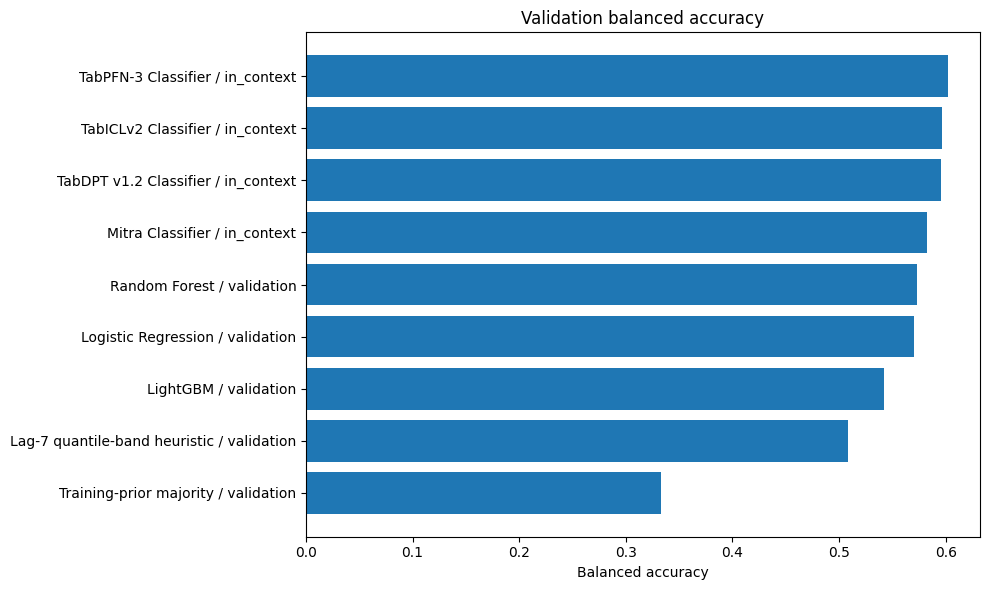

In [11]:
# @title 5.5 Load, validate, and compare foundation-model results
foundation_records = []
foundation_prediction_registry = {}

for key, run_dir in FOUNDATION_RUN_DIRS.items():
    result = json.loads((run_dir / "result.json").read_text())
    predictions = pd.read_csv(run_dir / "validation_predictions.csv")
    if len(predictions) != len(frames["val"]):
        raise ValueError(f"{key}: validation prediction row count mismatch.")
    if predictions["row_id"].tolist() != list(range(len(frames["val"]))):
        raise ValueError(f"{key}: invalid row_id sequence.")
    if not np.array_equal(
        predictions["target"].astype(str).to_numpy(),
        y_val.to_numpy(),
    ):
        raise ValueError(f"{key}: prediction targets do not match validation targets.")

    record = {
        "model_key": key,
        "model": result["model"],
        "family": result["family"],
        "condition": result["condition"],
        **result["metrics"],
        "runtime_seconds": result.get("fit_runtime_seconds"),
        "device": result["device"],
        "licence": MODEL_REPOSITORIES[CONDITION_SPECS[key]["environment"]]["licence"],
        "notes": "",
    }
    foundation_records.append(record)
    foundation_prediction_registry[key] = predictions

foundation_validation_results = pd.DataFrame(foundation_records)

combined_validation_results = pd.concat(
    [baseline_validation_results, foundation_validation_results],
    ignore_index=True,
    sort=False,
).sort_values(PRIMARY_METRIC, ascending=False).reset_index(drop=True)

display(
    combined_validation_results[
        [
            "model",
            "condition",
            "balanced_accuracy",
            "accuracy",
            "f1_macro",
            "mcc",
            "log_loss",
            "roc_auc_ovr_macro",
            "device",
        ]
    ].round(4)
)

fig, ax = plt.subplots(figsize=(10, 6))
plot_data = combined_validation_results.sort_values(PRIMARY_METRIC)
ax.barh(
    plot_data["model"].astype(str) + " / " + plot_data["condition"].astype(str),
    plot_data[PRIMARY_METRIC],
)
ax.set_title("Validation balanced accuracy")
ax.set_xlabel("Balanced accuracy")
plt.tight_layout()
comparison_figure = FIGURE_ROOT / "validation_balanced_accuracy.png"
plt.savefig(comparison_figure, dpi=140)
plt.show()


## Multi-model checkpoint

Use the validation comparison to answer:

1. Which conditions improve on the training-prior majority baseline?
2. Does the ordering change between ordinary accuracy and balanced accuracy?
3. Does the model with the highest balanced accuracy also have strong macro-F1?
4. Is a model achieving higher correctness by becoming overconfident, as reflected in log loss?
5. Which demand band has the lowest recall?
6. How much runtime and licensing complexity accompanies any improvement?

Avoid writing “Model X is the best classifier.” The evidence supports only a statement about this dataset artifact, split, metric suite, repository revision, and run configuration.


# 6. Inspect confusion and class-specific recall

A single headline metric can hide systematic failure on one demand band. The next cell uses validation predictions only.


,pred_low,pred_mid,pred_high
true_low,302,184,76
true_mid,151,293,90
true_high,15,126,363


,class,recall
0,low,0.5374
1,mid,0.5487
2,high,0.7202


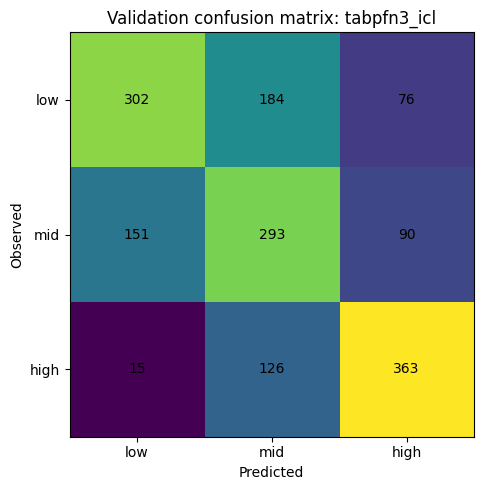

In [12]:
# @title 6.1 Confusion matrix for one successful model
MODEL_TO_INSPECT = "" # @param {type:"string"}

validation_registry = {
    **baseline_prediction_registry,
    **foundation_prediction_registry,
}
if not validation_registry:
    raise RuntimeError("No validation predictions are available.")

if MODEL_TO_INSPECT and MODEL_TO_INSPECT not in validation_registry:
    raise ValueError(
        f"{MODEL_TO_INSPECT!r} has no validation predictions. "
        f"Choose one of {sorted(validation_registry)}."
    )

if not MODEL_TO_INSPECT:
    ranked_keys = combined_validation_results["model_key"].tolist()
    MODEL_TO_INSPECT = next(key for key in ranked_keys if key in validation_registry)

diagnostic = validation_registry[MODEL_TO_INSPECT]
cm = confusion_matrix(
    diagnostic["target"].astype(str),
    diagnostic["prediction"].astype(str),
    labels=CLASS_LABELS,
)
cm_frame = pd.DataFrame(
    cm,
    index=[f"true_{label}" for label in CLASS_LABELS],
    columns=[f"pred_{label}" for label in CLASS_LABELS],
)
display(cm_frame)

recalls = recall_score(
    diagnostic["target"].astype(str),
    diagnostic["prediction"].astype(str),
    labels=CLASS_LABELS,
    average=None,
    zero_division=0,
)
display(
    pd.DataFrame(
        {"class": CLASS_LABELS, "recall": recalls}
    ).round(4)
)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(cm)
ax.set_xticks(range(len(CLASS_LABELS)), CLASS_LABELS)
ax.set_yticks(range(len(CLASS_LABELS)), CLASS_LABELS)
ax.set_xlabel("Predicted")
ax.set_ylabel("Observed")
ax.set_title(f"Validation confusion matrix: {MODEL_TO_INSPECT}")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.tight_layout()
confusion_figure = FIGURE_ROOT / f"confusion_{MODEL_TO_INSPECT}.png"
plt.savefig(confusion_figure, dpi=140)
plt.show()


# 7. Stockout-feature ablation

The stockout columns can carry predictive signal, but an ablation is still only predictive evidence. Removing them and observing a performance change does **not** establish that stockouts causally change demand.

The classical ablation is enabled by default. The foundation-model ablation is optional because it can require another expensive checkpoint run.


In [13]:
# @title 7.1 Classical and optional foundation-model stockout ablation
STOCKOUT_FEATURES = ["stockout_hours", "roll_7_stockout"]
REDUCED_FEATURES = [c for c in FEATURE_COLUMNS if c not in STOCKOUT_FEATURES]

RUN_CLASSICAL_ABLATION = True # @param {type:"boolean"}
RUN_FOUNDATION_ABLATION = False # @param {type:"boolean"}
FOUNDATION_ABLATION_CONDITION = "" # @param {type:"string"}

ablation_records = []

if RUN_CLASSICAL_ABLATION:
    reduced_lgbm = LGBMClassifier(
        n_estimators=300,
        random_state=RANDOM_SEED,
        verbosity=-1,
    )
    reduced_lgbm.fit(frames["train"][REDUCED_FEATURES], y_train)
    reduced_proba = align_probabilities(
        reduced_lgbm.predict_proba(frames["val"][REDUCED_FEATURES]),
        reduced_lgbm.classes_,
        CLASS_LABELS,
    )
    reduced_pred = np.asarray(CLASS_LABELS, dtype=object)[np.argmax(reduced_proba, axis=1)]
    reduced_metrics = classification_metrics(y_val, reduced_pred, reduced_proba, CLASS_LABELS)
    full = baseline_validation_results.loc[
        baseline_validation_results["model_key"] == "lightgbm"
    ].iloc[0]
    ablation_records.append(
        {
            "model": "LightGBM",
            "comparison": "remove stockout features",
            "full_balanced_accuracy": full["balanced_accuracy"],
            "ablated_balanced_accuracy": reduced_metrics["balanced_accuracy"],
            "delta": reduced_metrics["balanced_accuracy"] - full["balanced_accuracy"],
        }
    )

FOUNDATION_ABLATION_RUN_DIR = None
if RUN_FOUNDATION_ABLATION:
    candidates = list(FOUNDATION_RUN_DIRS)
    if not candidates:
        print("No successful foundation model is available for ablation.")
    else:
        base_key = FOUNDATION_ABLATION_CONDITION or candidates[0]
        if base_key not in FOUNDATION_RUN_DIRS:
            raise ValueError(
                f"Choose a successful foundation condition: {sorted(FOUNDATION_RUN_DIRS)}"
            )
        ablation_key = f"ablation_{base_key}_no_stockout"
        try:
            FOUNDATION_ABLATION_RUN_DIR = run_foundation_condition(
                base_key,
                features=REDUCED_FEATURES,
                output_key=ablation_key,
                condition_override=CONDITION_SPECS[base_key]["condition"] + "_no_stockout",
            )
            result = json.loads(
                (FOUNDATION_ABLATION_RUN_DIR / "result.json").read_text()
            )
            full_result = json.loads(
                (FOUNDATION_RUN_DIRS[base_key] / "result.json").read_text()
            )
            ablation_records.append(
                {
                    "model": result["model"],
                    "comparison": "remove stockout features",
                    "full_balanced_accuracy": full_result["metrics"]["balanced_accuracy"],
                    "ablated_balanced_accuracy": result["metrics"]["balanced_accuracy"],
                    "delta": (
                        result["metrics"]["balanced_accuracy"]
                        - full_result["metrics"]["balanced_accuracy"]
                    ),
                }
            )
        except Exception as exc:
            print("Foundation ablation failed:", f"{type(exc).__name__}: {exc}")

if ablation_records:
    display(pd.DataFrame(ablation_records).round(4))
else:
    print("No ablation was executed.")


,model,comparison,full_balanced_accuracy,ablated_balanced_accuracy,delta
0,LightGBM,remove stockout features,0.5426,0.537,-0.0056


# 8. Freeze the experiment before evaluating test labels

Validation data is for development and selection. The test partition is for the final measurement after settings are fixed.

The freeze records:

- dataset and split hashes;
- selected successful model keys;
- validation metrics;
- artifact digests where applicable;
- feature columns;
- class order; and
- the primary metric.

Turn **Freeze now** on only after you are done changing model conditions.


In [14]:
# @title 8.0 Freeze selected successful full-feature runs
FREEZE_NOW = True # @param {type:"boolean"}
SELECTED_MODEL_KEYS = "" # @param {type:"string"}
# @markdown Comma-separated keys. Blank selects all successful full-feature baseline and foundation runs.

full_feature_keys = (
    baseline_validation_results["model_key"].tolist()
    + list(FOUNDATION_RUN_DIRS)
)

selected_keys = (
    [value.strip() for value in SELECTED_MODEL_KEYS.split(",") if value.strip()]
    or full_feature_keys
)

unknown = [key for key in selected_keys if key not in full_feature_keys]
if unknown:
    raise ValueError(f"Unknown or unsuccessful model keys: {unknown}")

FREEZE_PATH = SESSION_ROOT / "freeze.json"

if FREEZE_NOW:
    selected_manifest = {}
    for key in selected_keys:
        if key in baseline_validation_results["model_key"].values:
            run_dir = BASELINE_ROOT / key
            result = json.loads((run_dir / "result.json").read_text())
            selected_manifest[key] = {
                "backend": "baseline",
                "run_dir": str(run_dir),
                "result_sha256": sha256_file(run_dir / "result.json"),
                "artifact_sha256": sha256_file(run_dir / "artifact.pkl"),
                "validation": {
                    metric: result.get(metric)
                    for metric in (
                        "accuracy",
                        "balanced_accuracy",
                        "f1_macro",
                        "mcc",
                        "log_loss",
                        "roc_auc_ovr_macro",
                    )
                },
            }
        else:
            run_dir = FOUNDATION_RUN_DIRS[key]
            result = json.loads((run_dir / "result.json").read_text())
            selected_manifest[key] = {
                "backend": "foundation",
                "run_dir": str(run_dir),
                "environment": CONDITION_SPECS[key]["environment"],
                "result_sha256": sha256_file(run_dir / "result.json"),
                "run_config_sha256": sha256_file(run_dir / "run_config.json"),
                "artifact_inventory": file_inventory(run_dir / "artifact"),
                "validation": result["metrics"],
            }

    freeze_document = {
        "workshop_revision": WORKSHOP_REVISION,
        "dataset_identity": DATASET_IDENTITY,
        "dataset_fingerprint": DATASET_FINGERPRINT,
        "primary_metric": PRIMARY_METRIC,
        "class_labels": CLASS_LABELS,
        "feature_columns": FEATURE_COLUMNS,
        "selected": selected_manifest,
        "protocol": "validation-selection-then-reload-saved-artifacts-for-test",
    }
    write_json(FREEZE_PATH, freeze_document)
    print("Frozen:", FREEZE_PATH)
    print("Selected:", selected_keys)
else:
    print("Not frozen yet.")
    print("Available successful keys:", full_feature_keys)


Frozen: /content/dimer_classifier_workshop_v1/sessions/678aa12788c7/freeze.json
Selected: ['random_forest', 'logistic_regression', 'lightgbm', 'lag7_quantile_band', 'training_prior_majority', 'mitra_icl', 'tabdpt_icl', 'tabpfn3_icl', 'tabiclv2_icl']


In [15]:
# @title 8.1 Evaluate only frozen models on the test partition
EVALUATE_FROZEN_TEST = True # @param {type:"boolean"}

def evaluate_baseline_test(key: str):
    run_dir = BASELINE_ROOT / key
    with (run_dir / "artifact.pkl").open("rb") as handle:
        artifact = pickle.load(handle)
    test = frames["test"]
    X = test[FEATURE_COLUMNS]
    y = test[TARGET_COLUMN].astype(str)
    kind = artifact["kind"]

    if kind == "majority":
        priors = pd.Series(artifact["priors"]).reindex(CLASS_LABELS).fillna(0.0)
        pred = np.repeat(artifact["majority_label"], len(test))
        proba = np.tile(priors.to_numpy(dtype=float), (len(test), 1))
    elif kind == "lag7_quantile":
        edges = np.asarray(artifact["edges"], dtype=float)
        ids = np.digitize(X[artifact["feature"]].to_numpy(dtype=float), edges)
        pred = np.asarray(CLASS_LABELS, dtype=object)[ids]
        proba = np.full((len(test), len(CLASS_LABELS)), 1e-6)
        proba[np.arange(len(test)), ids] = 1.0 - (len(CLASS_LABELS) - 1) * 1e-6
    elif kind == "sklearn":
        model = artifact["model"]
        raw = model.predict_proba(X)
        if isinstance(model, Pipeline):
            model_classes = model.named_steps["model"].classes_
        else:
            model_classes = model.classes_
        proba = align_probabilities(raw, model_classes, CLASS_LABELS)
        pred = np.asarray(CLASS_LABELS, dtype=object)[np.argmax(proba, axis=1)]
    else:
        raise ValueError(f"Unknown baseline artifact kind: {kind}")

    return classification_metrics(y, pred, proba, CLASS_LABELS), prediction_frame(
        test, pred, proba, CLASS_LABELS
    )

TEST_RESULTS = None
TEST_PREDICTION_REGISTRY = {}

if EVALUATE_FROZEN_TEST:
    if not FREEZE_PATH.exists():
        raise ValueError("Freeze the development experiment in Section 8.0 first.")
    frozen = json.loads(FREEZE_PATH.read_text())
    if frozen["dataset_fingerprint"] != DATASET_FINGERPRINT:
        raise ValueError("Dataset identity changed after freeze.")

    test_records = []
    for key, entry in frozen["selected"].items():
        print(f"\n=== test: {key} ===")
        run_dir = Path(entry["run_dir"])
        if sha256_file(run_dir / "result.json") != entry["result_sha256"]:
            raise ValueError(f"{key}: frozen development result changed after freeze.")

        if entry["backend"] == "baseline":
            if sha256_file(run_dir / "artifact.pkl") != entry["artifact_sha256"]:
                raise ValueError(f"{key}: frozen baseline artifact changed after freeze.")
            metrics_value, predictions = evaluate_baseline_test(key)
            model_row = combined_validation_results.loc[
                combined_validation_results["model_key"] == key
            ].iloc[0]
            test_records.append(
                {
                    "model_key": key,
                    "model": model_row["model"],
                    "condition": model_row["condition"],
                    **metrics_value,
                    "device": "cpu",
                }
            )
            TEST_PREDICTION_REGISTRY[key] = predictions
        else:
            if sha256_file(run_dir / "run_config.json") != entry["run_config_sha256"]:
                raise ValueError(f"{key}: frozen foundation run configuration changed after freeze.")
            verify_file_inventory(run_dir / "artifact", entry["artifact_inventory"])
            env_key = entry["environment"]
            spec = CONDITION_SPECS[key]
            repo_spec = MODEL_REPOSITORIES[env_key]
            output_dir = RUN_ROOT / "test" / key
            output_dir.mkdir(parents=True, exist_ok=True)
            config = {
                "phase": "test",
                "model_key": key,
                "base_condition_key": key,
                "model_family": env_key,
                "display_name": spec["display_name"],
                "condition": spec["condition"],
                "model_configuration": spec["configuration"],
                "repository": repo_spec["repository"],
                "repository_commit": repo_spec["commit"],
                "weights_dir": str(MODEL_WEIGHTS_DIRS[env_key]),
                "features": FEATURE_COLUMNS,
                "class_labels": CLASS_LABELS,
                "seed": RANDOM_SEED,
                "device_preference": DEVICE_PREFERENCE,
                "dataset_fingerprint": DATASET_FINGERPRINT,
                "runner_sha256": RUNNER_SHA256,
                "split_paths": {name: str(path) for name, path in staged_paths.items()},
                "source_run_dir": entry["run_dir"],
                "output_dir": str(output_dir),
            }
            config_path = SUPPORT_ROOT / f"test-{key}.json"
            write_json(config_path, config)
            stream_command(
                [
                    str(MODEL_ENVIRONMENT_PYTHONS[env_key]),
                    str(RUNNER_PATH),
                    "--config",
                    str(config_path),
                ],
                log_path=RUN_ROOT / "test" / f"{key}.log",
            )
            result = json.loads((output_dir / "result.json").read_text())
            predictions = pd.read_csv(output_dir / "test_predictions.csv")
            test_records.append(
                {
                    "model_key": key,
                    "model": result["model"],
                    "condition": result["condition"],
                    **result["metrics"],
                    "device": result["device"],
                }
            )
            TEST_PREDICTION_REGISTRY[key] = predictions

    TEST_RESULTS = pd.DataFrame(test_records).sort_values(
        PRIMARY_METRIC, ascending=False
    ).reset_index(drop=True)
    display(
        TEST_RESULTS[
            [
                "model",
                "condition",
                "balanced_accuracy",
                "accuracy",
                "f1_macro",
                "mcc",
                "log_loss",
                "roc_auc_ovr_macro",
                "device",
            ]
        ].round(4)
    )
else:
    print("Test labels remain unevaluated. Enable EVALUATE_FROZEN_TEST only after freezing.")



=== test: lag7_quantile_band ===

=== test: lightgbm ===

=== test: logistic_regression ===

=== test: mitra_icl ===
$ /content/dimer_classifier_workshop_v1/environments/mitra-796dec2283d3/bin/python /content/dimer_classifier_workshop_v1/sessions/678aa12788c7/support/local_foundation_classifier.py --config /content/dimer_classifier_workshop_v1/sessions/678aa12788c7/support/test-mitra_icl.json
/content/dimer_classifier_workshop_v1/environments/mitra-796dec2283d3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:259: UserWarning: The y_prob values do not sum to one. Make sure to pass probabilities.
  warnings.warn(
{
  "model": "Mitra Classifier",
  "metrics": {
    "accuracy": 0.549375,
    "balanced_accuracy": 0.543929759842695,
    "f1_macro": 0.5442329319166536,
    "mcc": 0.32319305468564646,
    "log_loss": 0.9141528869206167,
    "roc_auc_ovr_macro": 0.7397096657240013
  }
}

=== test: random_forest ===

=== test: tabdpt_icl ===
$ /content/dimer_classifier_workshop_

,model,condition,balanced_accuracy,accuracy,f1_macro,mcc,log_loss,roc_auc_ovr_macro,device
0,TabPFN-3 Classifier,in_context,0.5587,0.5725,0.5608,0.3512,0.9158,0.7431,cuda
1,TabICLv2 Classifier,in_context,0.5452,0.5569,0.5436,0.3265,0.9119,0.7398,cuda
2,Mitra Classifier,in_context,0.5439,0.5494,0.5442,0.3232,0.9142,0.7397,cuda
3,TabDPT v1.2 Classifier,in_context,0.5421,0.5500,0.5323,0.3228,0.9155,0.7389,cuda
4,Logistic Regression,validation,0.5247,0.5425,0.5216,0.3237,0.9482,0.7308,cpu
5,Random Forest,validation,0.5244,0.5462,0.5265,0.3078,0.9211,0.7287,cpu
6,LightGBM,validation,0.5205,0.5375,0.5238,0.3006,1.2397,0.7160,cpu
7,Lag-7 quantile-band heuristic,validation,0.4889,0.5081,0.4893,0.2477,6.7955,0.6200,cpu
8,Training-prior majority,validation,0.3333,0.3381,0.1685,0.0000,1.0950,0.5000,cpu


## 8.2 Inspect independent query-time predictions

The frozen-test stage above reloads the saved model artifact and scores feature rows that were not used for adaptation. The target column is used only after prediction to compute evaluation metrics. The next cell exposes a small prediction-only view so the inference contract is visible separately from the metric table.


In [16]:
# @title 8.2 Preview prediction-only output from a frozen model
INFERENCE_PREVIEW_ROWS = 8 # @param {type:"slider", min:1, max:50, step:1}
INFERENCE_MODEL_KEY = "" # @param {type:"string"}
if TEST_RESULTS is None or not TEST_PREDICTION_REGISTRY:
    raise RuntimeError("Complete the default freeze and independent test evaluation first.")
validation_order = combined_validation_results.sort_values(PRIMARY_METRIC, ascending=False)["model_key"].tolist()
default_key = next((key for key in validation_order if key in TEST_PREDICTION_REGISTRY), None)
model_key = INFERENCE_MODEL_KEY.strip() or default_key
if model_key not in TEST_PREDICTION_REGISTRY:
    raise ValueError(f"Choose a frozen model key with predictions: {sorted(TEST_PREDICTION_REGISTRY)}")
columns = ["row_id", "prediction"] + [f"probability_{label}" for label in CLASS_LABELS]
inference_preview = TEST_PREDICTION_REGISTRY[model_key][columns].head(INFERENCE_PREVIEW_ROWS).copy()
display(inference_preview)
print("Inference model:", model_key)
print("Decision rule: argmax over class probabilities in this order:", CLASS_LABELS)


,row_id,prediction,probability_low,probability_mid,probability_high
0,0,high,0.127077,0.425472,0.447451
1,1,mid,0.342834,0.514683,0.142483
2,2,low,0.463779,0.444012,0.092209
3,3,mid,0.172749,0.487824,0.339427
4,4,mid,0.332877,0.518235,0.148889
5,5,low,0.651368,0.317585,0.031047
6,6,high,0.077383,0.354886,0.567731
7,7,low,0.476157,0.457773,0.066070


Inference model: tabpfn3_icl
Decision rule: argmax over class probabilities in this order: ['low', 'mid', 'high']


## Write an evidence-based conclusion

Use this structure after the frozen test evaluation:

### 1. State the question

> We tested whether selected tabular foundation-model classifiers improved seven-day-ahead retail demand-band classification relative to heuristic and classical baselines.

### 2. Report the primary result

> On the fixed test partition, **[model and condition]** obtained balanced accuracy **[value]**, compared with **[value]** for **[reference baseline]**.

### 3. Report supporting evidence

Include accuracy, macro-F1, MCC and log loss. If ROC-AUC is reported, identify it as one-vs-rest macro AUC.

### 4. Report class-specific behavior

State which of `low`, `mid`, or `high` had the weakest recall or was most frequently confused.

### 5. Describe adaptation honestly

Say whether the selected foundation model used **in-context conditioning** or **gradient fine-tuning**.

### 6. State limitations

At minimum:

- the sample covers only a subset of FreshRetailNet-50K;
- classes are training-derived demand bands, not intrinsic business categories;
- the target is observed sales and can be censored by stockouts;
- one chronological split does not quantify variance across time periods;
- probabilities are not assumed calibrated;
- TabPFN-3 carries non-commercial weight restrictions; and
- results do not establish production readiness, causal effects, or benchmark superiority.


## Participant submission checklist

- [ ] Dataset repository revision and SHA-256
- [ ] Train/validation row counts and class proportions
- [ ] One development-only EDA visualization
- [ ] Classical baseline table
- [ ] At least two successful foundation-model conditions
- [ ] Validation comparison using balanced accuracy
- [ ] Confusion matrix and per-class recall
- [ ] Stockout ablation result or a justified reason for omitting it
- [ ] Freeze manifest
- [ ] Frozen test comparison table
- [ ] Effective adaptation mode for each selected foundation model
- [ ] Dataset and model licence notes
- [ ] One evidence-based conclusion
- [ ] At least three limitations


# 9. Export the current experiment record

The export contains results and metadata, not the foundation-model weight files themselves.


In [17]:
# @title 9.1 Export results, figures, provenance, and freeze metadata
CREATE_ZIP_BUNDLE = True # @param {type:"boolean"}

export_dir = EXPORT_ROOT / f"report-{uuid.uuid4().hex[:8]}"
export_dir.mkdir(parents=True, exist_ok=False)

baseline_validation_results.to_csv(
    export_dir / "baseline_validation_results.csv",
    index=False,
)
foundation_validation_results.to_csv(
    export_dir / "foundation_validation_results.csv",
    index=False,
)
combined_validation_results.to_csv(
    export_dir / "combined_validation_results.csv",
    index=False,
)

if TEST_RESULTS is not None:
    TEST_RESULTS.to_csv(export_dir / "frozen_test_results.csv", index=False)

if FREEZE_PATH.exists():
    shutil.copy2(FREEZE_PATH, export_dir / "freeze.json")

figure_dir = export_dir / "figures"
figure_dir.mkdir()
for path in FIGURE_ROOT.glob("*.png"):
    shutil.copy2(path, figure_dir / path.name)

manifest = {
    "workshop_revision": WORKSHOP_REVISION,
    "dataset_provenance": DATASET_PROVENANCE,
    "dataset_identity": DATASET_IDENTITY,
    "dataset_fingerprint": DATASET_FINGERPRINT,
    "software_versions": SOFTWARE_VERSIONS,
    "primary_metric": PRIMARY_METRIC,
    "class_labels": CLASS_LABELS,
    "feature_columns": FEATURE_COLUMNS,
    "successful_foundation_conditions": list(FOUNDATION_RUN_DIRS),
    "foundation_failures": FOUNDATION_RUN_ERRORS,
    "includes_frozen_test_results": TEST_RESULTS is not None,
    "model_adapter_repositories": MODEL_REPOSITORIES,
    "carried_adapter_sha256": CARRIED_SOURCE_SHA256,
    "notebook_spec": "2.1",
    "artifact_policy": (
        "Foundation-model artifacts remain in the notebook runtime; "
        "the report contains provenance and metrics, not redistributed model weights."
    ),
}
if "inference_preview" in globals():
    inference_preview.to_csv(export_dir / "inference_preview.csv", index=False)
write_json(export_dir / "experiment_manifest.json", manifest)

print("Export directory:", export_dir)
if CREATE_ZIP_BUNDLE:
    bundle = Path(
        shutil.make_archive(
            str(export_dir),
            "zip",
            root_dir=export_dir,
        )
    )
    print("Report ZIP:", bundle)
    print("SHA-256:", sha256_file(bundle))


Export directory: /content/dimer_classifier_workshop_v1/sessions/678aa12788c7/exports/report-51adcc95
Report ZIP: /content/dimer_classifier_workshop_v1/sessions/678aa12788c7/exports/report-51adcc95.zip
SHA-256: fa5e8e9d1fd45de783c1721d9a7c1dc66a48848622eacbaf676506621ad8789e


In [18]:
# @title Run-all completion summary
summary = {
    "notebook_spec": "2.1",
    "profile": "E2E",
    "mode": "WORKSHOP",
    "dataset_source": DATASET_PROVENANCE["acquisition"]["method"],
    "validation_models": int(len(combined_validation_results)),
    "frozen_test_models": int(0 if TEST_RESULTS is None else len(TEST_RESULTS)),
    "foundation_failures": FOUNDATION_RUN_ERRORS,
    "export_directory": str(export_dir),
}
display(pd.Series(summary, name="value").to_frame())
if FREEZE_NOW and EVALUATE_FROZEN_TEST and TEST_RESULTS is not None:
    print("Run-all complete: validation, freeze, artifact reload, independent test evaluation, inference preview, and export succeeded.")
else:
    print("Run completed with one or more default E2E stages disabled; treat this as an exploratory run.")


,value
notebook_spec,2.1
profile,E2E
mode,WORKSHOP
dataset_source,pinned-public-sample
validation_models,9
frozen_test_models,9
foundation_failures,{}
export_directory,/content/dimer_classifier_workshop_v1/sessions...


Run-all complete: validation, freeze, artifact reload, independent test evaluation, inference preview, and export succeeded.


# Appendix. References and provenance

## Dataset

Workshop artifact: `kurtvalcorza/mitra-classifier-pipeline/examples/sample-data/freshretailnet-band-h7.zip`  
Pinned repository revision: `469d91252f3583b38d08b5c4d90fef4848b93f24`  
Pinned archive SHA-256: `ad2d2a8729749bb055754e4867acfb048fc27816f4eb344961d962b59c0be6dd`  
Source dataset: `Dingdong-Inc/FreshRetailNet-50K`  
Dataset licence: CC BY 4.0

The target bands are generated by `examples/build_freshretailnet_dataset.py`: the future seven-day-ahead `sale_amount` is computed first, the temporal train/validation/test split is formed with seven-row embargoes, then the band edges are learned from the training rows only and applied to all partitions.

## Pinned classifier pipeline repositories

| Model | Repository | Commit | Checkpoint |
|---|---|---|---|
| Mitra Classifier | `kurtvalcorza/mitra-classifier-pipeline` | `469d91252f3583b38d08b5c4d90fef4848b93f24` | `autogluon/mitra-classifier` @ `c425e9fa0910a6be1c494321792e7ba2a1367b1a` |
| TabDPT v1.2 Classifier | `kurtvalcorza/tabdpt-classifier-pipeline` | `1e35dc4738f015b254b1724fd4bc7ba9f49668af` | `Layer6/TabDPT` @ `4462ffbd1d8dea25d4862d30beed4b70cd596ae5` |
| TabPFN-3 Classifier | `kurtvalcorza/tabpfn-classifier-pipeline` | `769fb7b47e01b1d10edd954dabc634b8034598c2` | `Prior-Labs/tabpfn_3` @ `24a16a89d245878b846555110985634aa2e656d7` |
| TabICLv2 Classifier | `kurtvalcorza/tabicl-classifier-pipeline` | `7400516ac86e3b6e55f5134ad5e550f312948981` | `jingang/TabICL` @ `4dcd344ece2c00be9e831fdd35bed57b5ad83e19` |

This workshop is a comparative teaching notebook, not a generated carrier for any one pipeline repository. Its results require a clean end-to-end runtime validation before the notebook should be called workshop-ready.


## Standalone carrier provenance

The model adapter modules used by Section 5 are carried verbatim inside this notebook from the repository revisions listed in `MODEL_REPOSITORIES`. They are written to the runtime only from notebook-owned source text; the notebook does not fetch DIMER source code at execution time. The checkpoint manifests are also carried inline, while the checkpoint files themselves are obtained from their public upstream hosts at the immutable revisions and verified against the declared SHA-256 values before model use.
